# データサイエンス実践A （新潟大学創生学部：2025年度版）
## Python (matplotlib) によるデータ可視化
1. ここでは、主に折れ線グラフ、散布図、棒グラフ、箱ひげ図、円グラフ、時系列データ、数学関数、その他の描画を行う。  
1. グラフは自分で0から作成する必要はなく、ここで描いたものをテンプレートとして用い、必要に応じてパラメータを修正、追加、削除等すれば良い。こんなグラフ描きたい、というのがあれば是非色々調べて他の人の作例を参考にしてみて下さい。
1. 自分で調べても分からないことは、質問して下さい。例えば本講義終了後、ゼミ・ラボ活動の際にこんな可視化したい、というのでも構いません。

- **[0.準備](#0.-準備)** 
<br>
- **[1.折れ線グラフの作成](#1.-折れ線グラフの作成)**
<br>
- **[2.散布図の作成](#2.-散布図の作成)**
<br>
- **[3.棒グラフの作成](#3.-棒グラフの作成)**
<br>
- **[4.箱ひげ図の作成](#4.-箱ひげ図の作成)**
<br>
- **[5.円グラフの作成](#5.-円グラフの作成)**
<br>
- **[6.時系列データの描画](#6.-時系列データの描画)**
<br>
- **[7.その他やや高度な可視化手法](#7.-その他やや高度な可視化手法)**
<br>
- **[8.数学関数の可視化](#8.-数学関数の可視化)**

In [1]:
# 数値演算、描画用ライブラリ読み込み
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# グラフをinline表示可能にする
%matplotlib inline
# 解像度を上げてinline表示する
%config InlineBackend.figure_format = 'retina'

# 日本語表示用ライブラリ（matplotlibで日本語を使用したい場合）
try:
    import japanize_matplotlib
except ModuleNotFoundError:
    # 初回だけインストールするので時間がかかる
    !pip install japanize-matplotlib
    import japanize_matplotlib

### 0. 準備
Excelファイルの読み込み（dsa2024data.xlsxを以下の  `cd .`  で表示されるフォルダに入れておく）  
自分で用意したExcelファイルを読む場合は、**Excelファイルの先頭行を列名としておく**とオプションによる指定をせずに簡単に読み込める。

In [2]:
cd .

D:\jupyter_notebook\lectures\DS_A


In [3]:
# データファイル（Excel）指定
datafile = "dsa2025data.xlsx"

In [4]:
# シート名を指定し、ここでは df (dataframe) という名前で読み込み
df = pd.read_excel(datafile, sheet_name = "data")
# df = pd.read_excel("https://www.ces-alpha.org/course/file_serve/5860835511500800/dsa2024data.xlsx", sheet_name = "data")
df

,data1,data2,data3,data4,data5
0,45,23,11,55,82
1,94,30,19,56,26
2,53,19,34,44,85
3,88,27,25,59,82
4,57,22,32,64,76
5,79,15,6,69,73
6,53,17,30,62,64
7,69,17,40,43,91
8,80,20,33,33,53
9,66,25,22,69,67


### 1. 折れ線グラフの作成
https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html

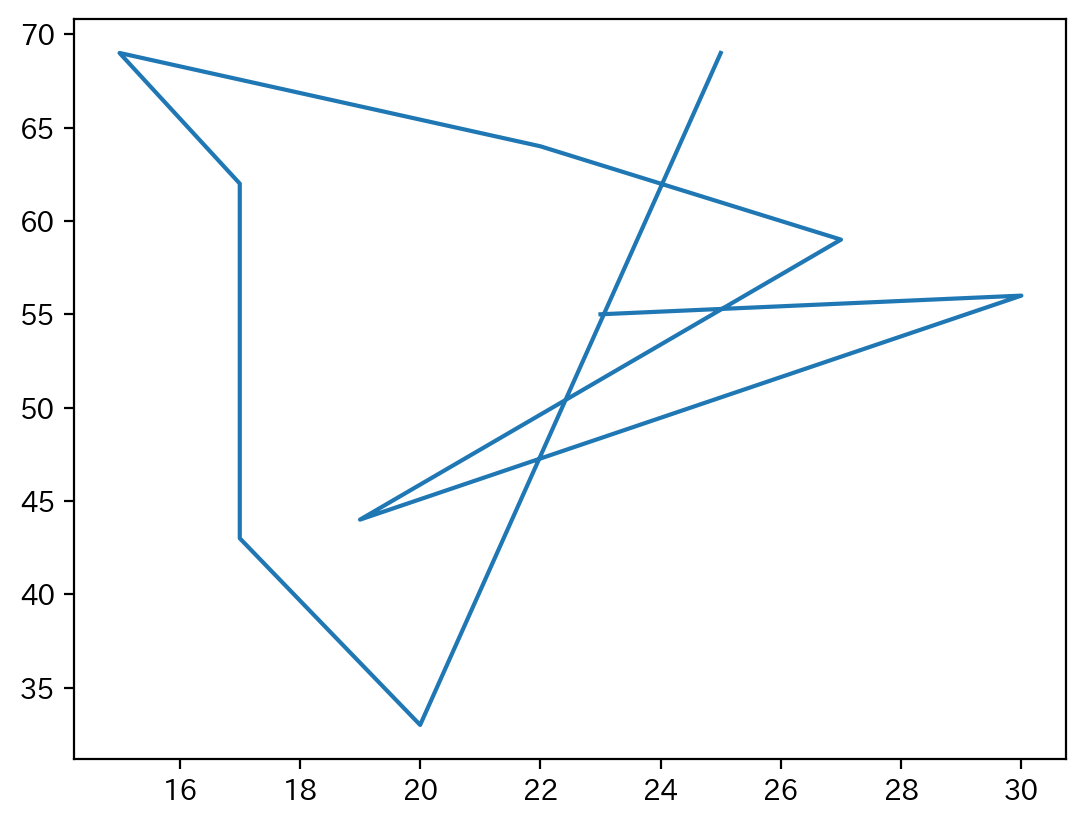

In [5]:
# df の列名を指定して x軸データと y軸データを作成
x = df["data2"]
y = df["data4"]

# 折れ線グラフの描画
plt.plot(x, y);

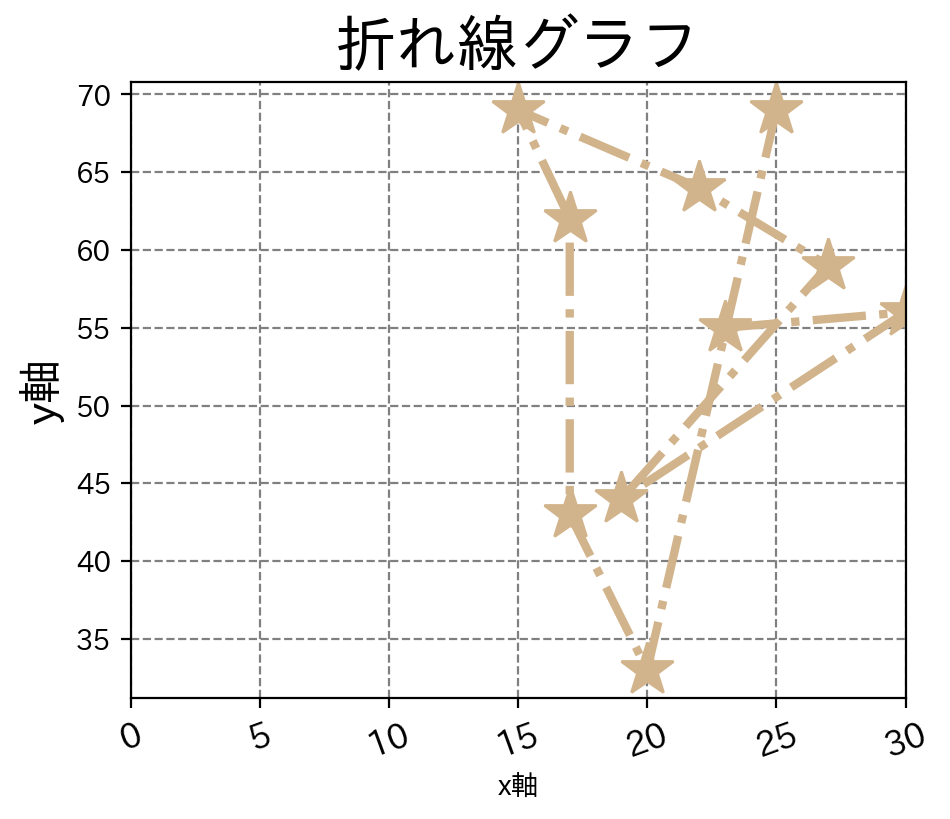

In [6]:
# df の列名を指定して x軸データと y軸データを作成
x = df["data2"]
y = df["data4"]

# グラフサイズ指定
plt.figure(figsize=(5,4))

# グラフタイトル
plt.title("折れ線グラフ",fontsize=22)

# x軸・y軸名の指定（フォントサイズの指定）
plt.xlabel("x軸")
plt.ylabel("y軸", fontsize=16)

# x軸範囲・y軸範囲の指定
plt.xlim(0,30)
#plt.ylim(0,17)

# x軸目盛のフォントサイズ、回転角度の指定
plt.xticks(fontsize=12, rotation=20)

# グリッド（補助線）の描画（線種、線の色指定あり）
plt.grid(True, linestyle="--", color="gray")

# linestyle
plt.plot(x,y,color="tan",marker="*",markersize=20, linestyle="-.", linewidth=3);

In [7]:
# 別のシートのデータを、今回は df_accident と言う名前で読み込み
df_accident = pd.read_excel(datafile, sheet_name = "accident")
df_accident.head()

,年,交通事故件数,死者数,負傷者数,重傷者数
0,2000,931950,9073,1155707,80105
1,2001,947253,8757,1181039,79677
2,2002,936950,8396,1168029,78297
3,2003,948281,7768,1181681,75112
4,2004,952720,7436,1183617,72817


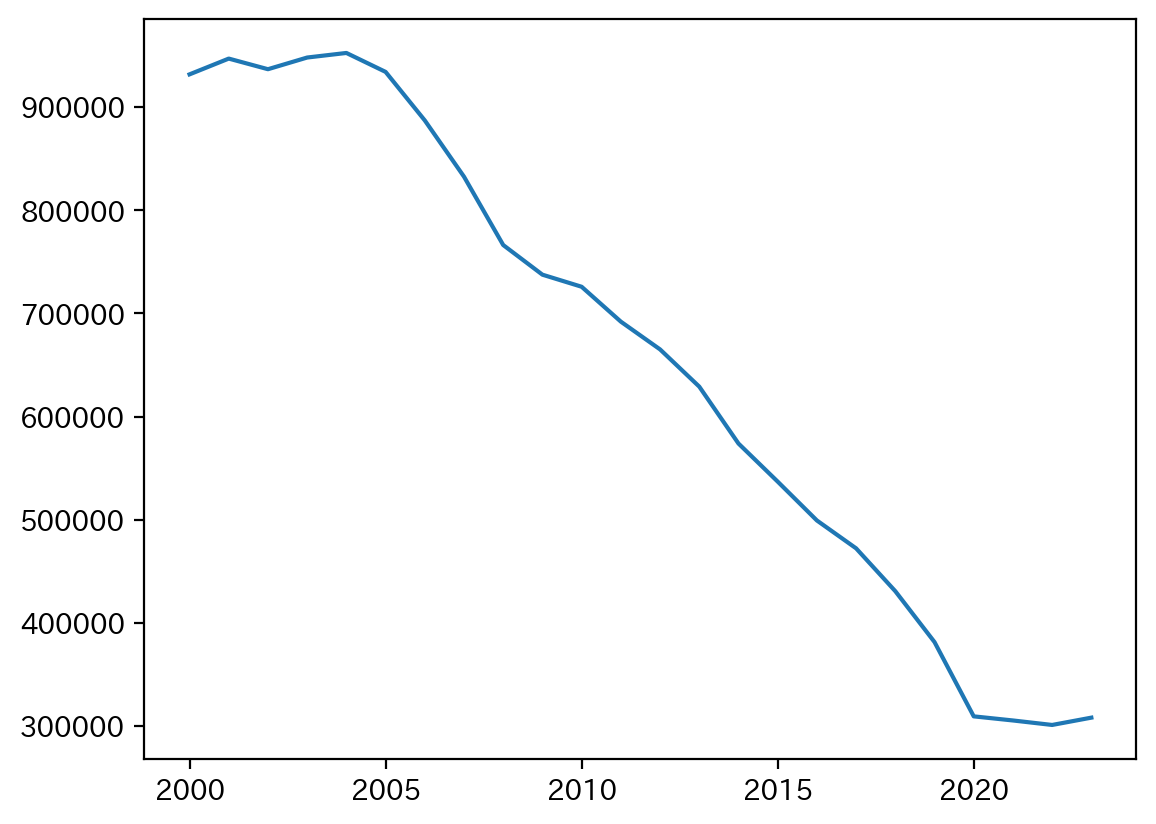

In [8]:
# 最も簡単なグラフ
# x軸に df_accident の「年」列、y軸に df_accident の「交通事故件数」列を指定
plt.plot(df_accident["年"], df_accident["交通事故件数"]);

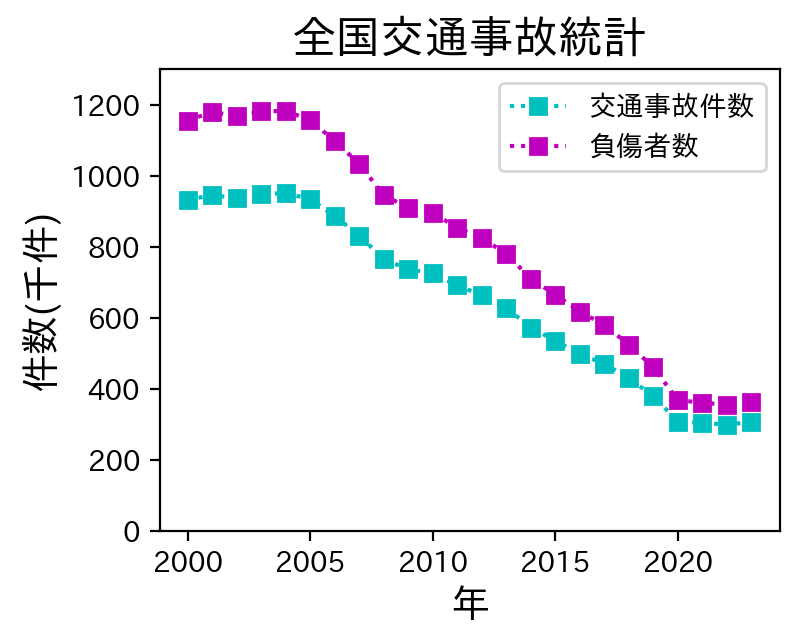

In [9]:
# グラフサイズ指定
plt.figure(figsize=(4,3))

# タイトル指定
plt.title("全国交通事故統計", fontsize=16)

# x, y軸名指定
plt.xlabel("年", fontsize=14)
plt.ylabel("件数(千件)", fontsize=14)

# y軸範囲の指定
plt.ylim(0, 1300)

# グリッド線の設定
plt.grid(False)

# データプロット（折れ線グラフ、凡例：ラベル付き）
plt.plot(df_accident["年"], df_accident["交通事故件数"]/1000, "s:c", label="交通事故件数")
plt.plot(df_accident["年"], df_accident["負傷者数"]/1000, "s:m", label="負傷者数")
plt.legend();

### 両ｙ軸グラフ

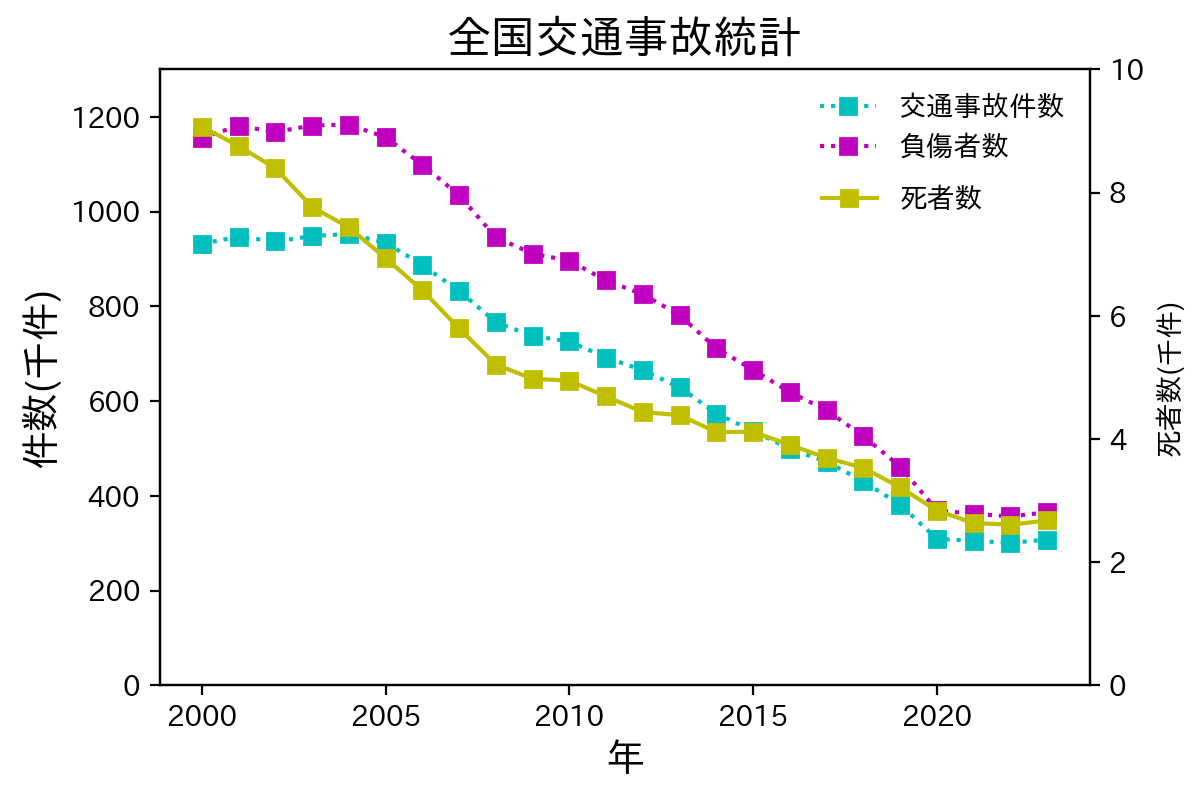

In [10]:
# グラフサイズ指定
plt.figure(figsize=(6,4))

# タイトル指定
plt.title("全国交通事故統計", fontsize=16)

# x, y軸名指定
plt.xlabel("年", fontsize=14)
plt.ylabel("件数(千件)", fontsize=14)

# y軸範囲の指定
plt.ylim(0, 1300)

# グリッド線の設定
plt.grid(False)

# データプロット（折れ線グラフ）
#plt.plot(df_accident["年"], df_accident["交通事故件数"], color="c", marker="s", markersize=8, linestyle="-", label="交通事故件数")
plt.plot(df_accident["年"], df_accident["交通事故件数"]/1000, "s:c", label="交通事故件数")
plt.plot(df_accident["年"], df_accident["負傷者数"]/1000, "s:m", label="負傷者数")

# 凡例の枠線を非表示
plt.legend(frameon=False)

#右軸の設定
plt.twinx()
plt.plot(df_accident["年"], df_accident["死者数"]/1000, "s-y", label="死者数")

# y軸範囲の指定
plt.ylim(0, 10)
plt.ylabel("死者数(千件)", fontsize=10)
plt.legend(loc=(0.7,0.75), frameon=False);

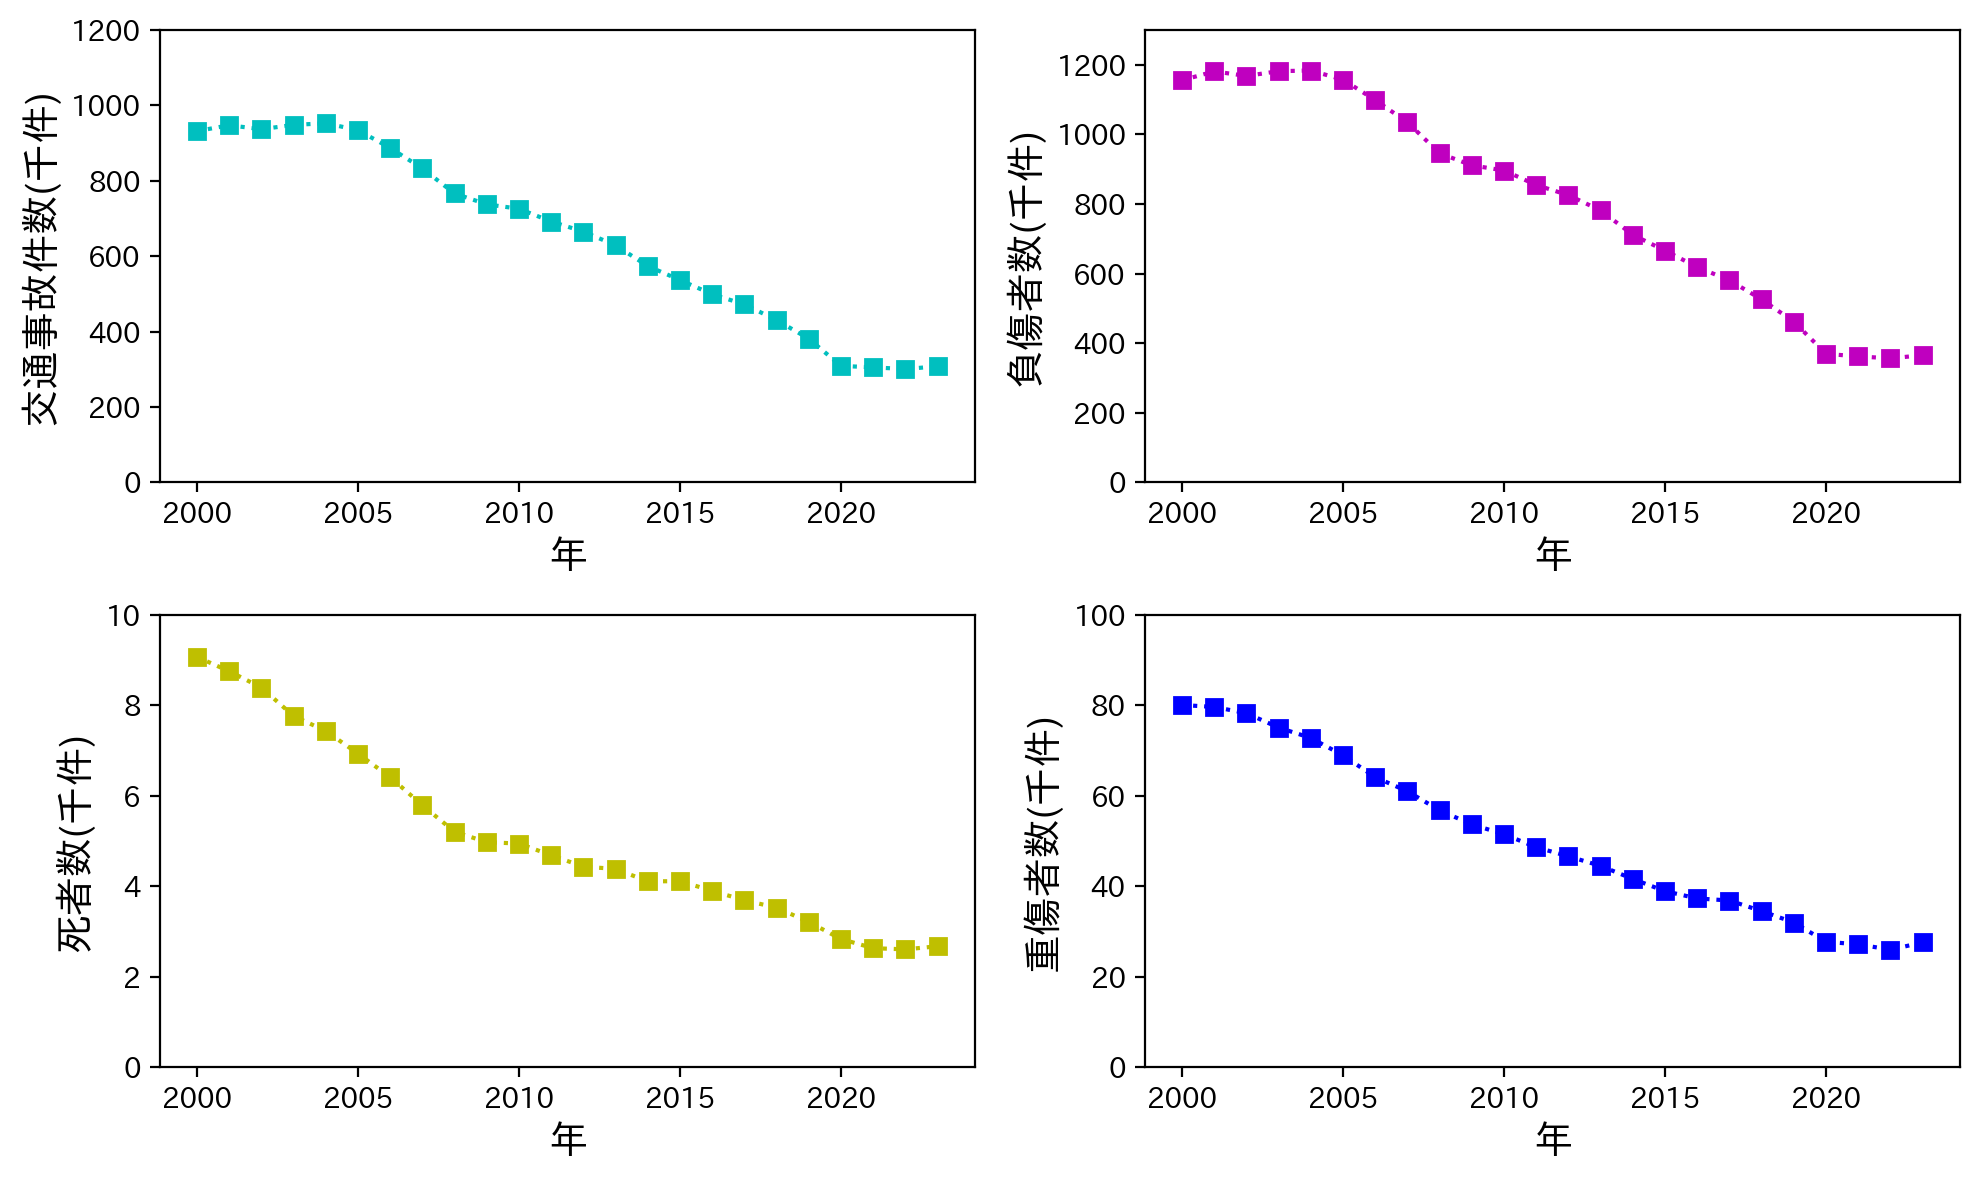

In [11]:
#複数グラフ一括描画の例
plt.figure(figsize=(10,6))
plt.subplot(2,2,1)
plt.ylim(0, 1200)
plt.plot(df_accident["年"], df_accident["交通事故件数"]/1000, "s:c")
# x, y軸名指定
plt.xlabel("年", fontsize=14)
plt.ylabel("交通事故件数(千件)", fontsize=14)

# y軸範囲の指定
plt.subplot(2,2,2)
plt.ylim(0, 1300)
plt.plot(df_accident["年"], df_accident["負傷者数"]/1000, "s:m")
# x, y軸名指定
plt.xlabel("年", fontsize=14)
plt.ylabel("負傷者数(千件)", fontsize=14)

# y軸範囲の指定
plt.subplot(2,2,3)
plt.ylim(0, 10)
plt.plot(df_accident["年"], df_accident["死者数"]/1000, "s:y")
# x, y軸名指定
plt.xlabel("年", fontsize=14)
plt.ylabel("死者数(千件)", fontsize=14)

# y軸範囲の指定
plt.subplot(2,2,4)
plt.ylim(0, 100)
plt.plot(df_accident["年"], df_accident["重傷者数"]/1000, "s:b")
# x, y軸名指定
plt.xlabel("年", fontsize=14)
plt.ylabel("重傷者数(千件)", fontsize=14)
plt.tight_layout();

### 2. 散布図の作成
https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html  
特徴：プロット点毎に色やサイズの指定ができる（x、y軸情報に加え、z軸情報の可視化）

In [12]:
# シート名 data のデータを、df_data と言う名前で読み込み
df_data = pd.read_excel(datafile, sheet_name = "data")
df_data.head()

,data1,data2,data3,data4,data5
0,45,23,11,55,82
1,94,30,19,56,26
2,53,19,34,44,85
3,88,27,25,59,82
4,57,22,32,64,76


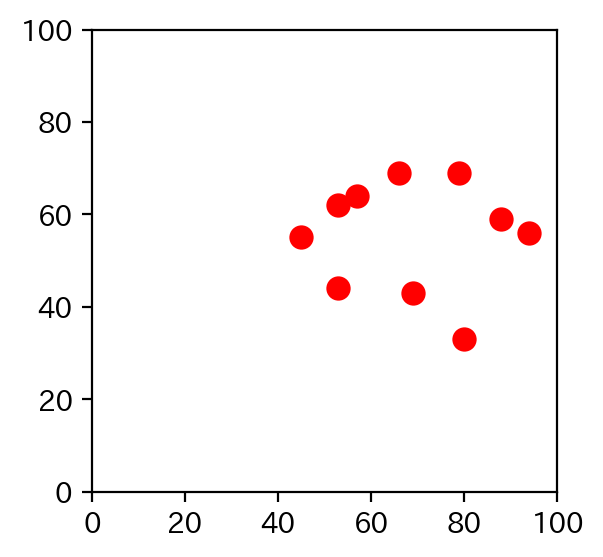

In [13]:
plt.figure(figsize=(3,3))
plt.xlim(0,100)
plt.ylim(0,100)
plt.scatter(df_data["data1"], df_data["data4"], c="r", s=60);

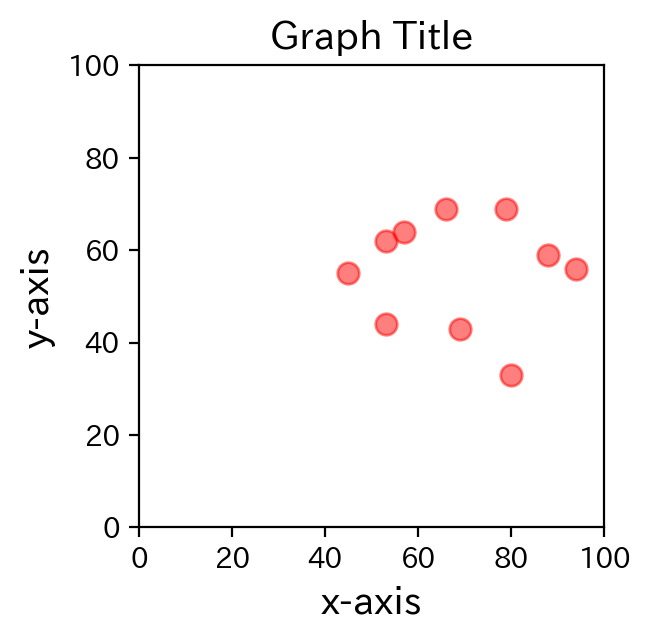

In [14]:
# データ点毎の色とサイズを同時に指定
plt.figure(figsize=(3,3))
plt.xlim(0,100)
plt.ylim(0,100)
# タイトル
plt.title("Graph Title", fontsize=14)
# x, y軸名指定
plt.xlabel("x-axis", fontsize=14)
plt.ylabel("y-axis", fontsize=14)
# 透明度(alpha)の指定
plt.scatter(df_data["data1"], df_data["data4"], c="r", s=60, alpha=0.5);

In [15]:
# data数の取得
len(df_data)

10

In [16]:
# データ数と同じ数の色名のリスト作成
mycolor = ["c"] * len(df_data)
mycolor

['c', 'c', 'c', 'c', 'c', 'c', 'c', 'c', 'c', 'c']

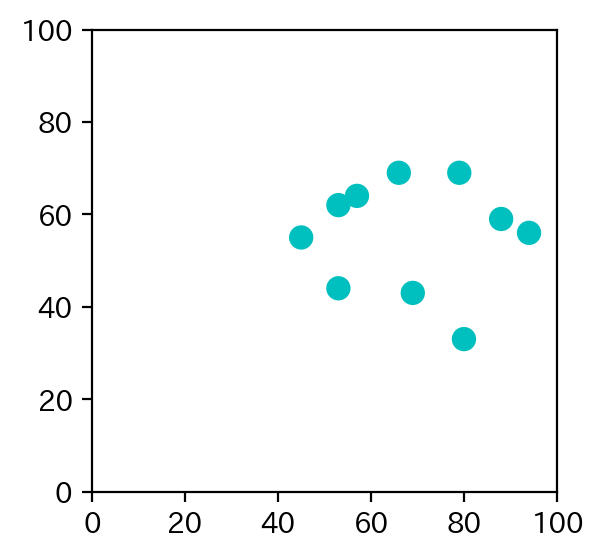

In [17]:
# 色名のリストを c=mycolor としてデータ点毎の色を指定
plt.figure(figsize=(3,3))
plt.xlim(0,100)
plt.ylim(0,100)
plt.scatter(df_data["data1"], df_data["data4"], c=mycolor, s=60);

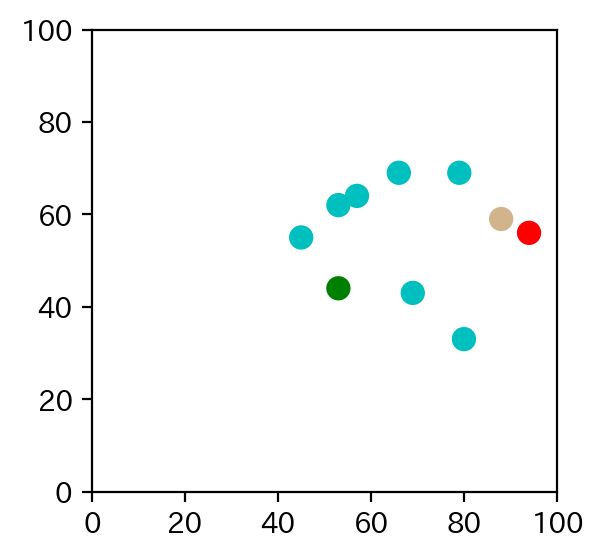

In [18]:
# 色名のリスト（文字列）を c=mycolor としてデータ点毎の色を指定：z軸情報の可視化の一例
mycolor=['c', 'r', 'g', 'tan', 'c', 'c', 'c', 'c', 'c', 'c']
plt.figure(figsize=(3,3))
plt.xlim(0,100)
plt.ylim(0,100)
plt.scatter(df_data["data1"], df_data["data4"], c=mycolor, s=60);

In [19]:
# データ点のサイズ（数値）のリストを s=mysize としてデータ点毎のサイズを指定：z軸情報の可視化の一例
mysize = [60]*10
mysize

[60, 60, 60, 60, 60, 60, 60, 60, 60, 60]

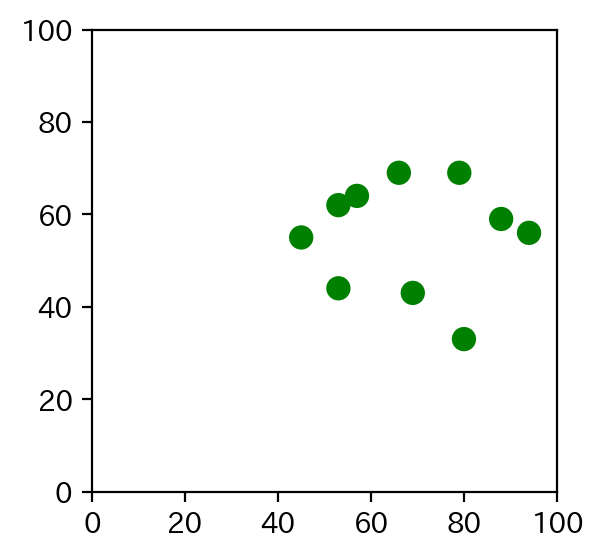

In [20]:
plt.figure(figsize=(3,3))
plt.xlim(0,100)
plt.ylim(0,100)
plt.scatter(df_data["data1"], df_data["data4"], c="g", s=mysize);

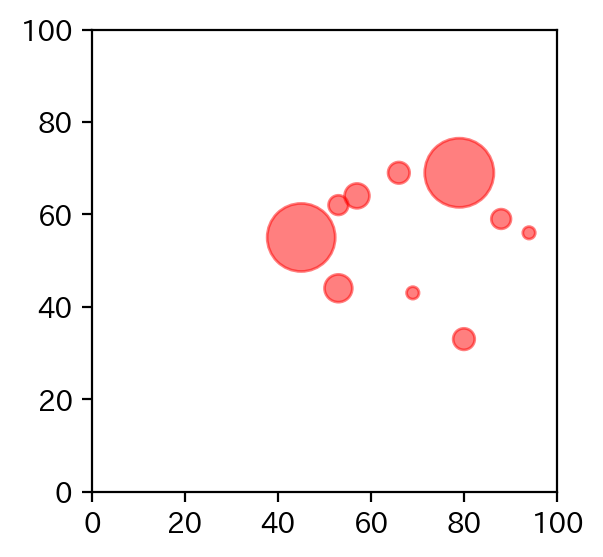

In [21]:
mysize = [600, 20, 100, 50, 80, 620, 50, 20, 60, 60]
plt.figure(figsize=(3,3))
plt.xlim(0,100)
plt.ylim(0,100)

# 透明度 alpha を指定
plt.scatter(df_data["data1"], df_data["data4"], c="red", s=mysize, alpha=0.5);

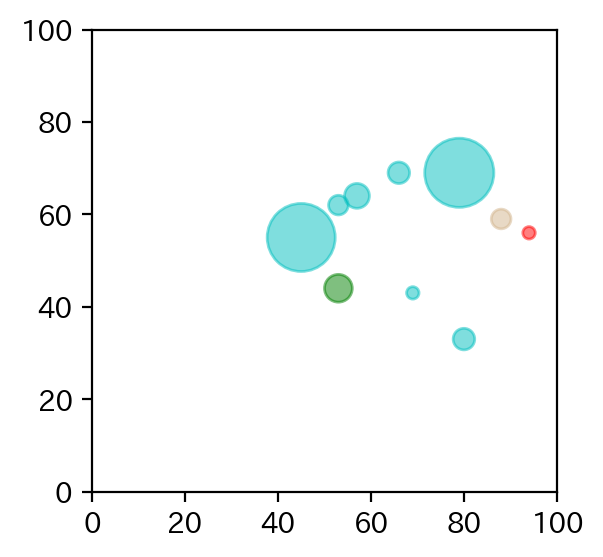

In [22]:
# データ点毎の色とサイズを同時に指定
mysize = [600, 20, 100, 50, 80, 620, 50, 20, 60, 60]
mycolor = ['c', 'r', 'g', 'tan', 'c', 'c', 'c', 'c', 'c', 'c']
plt.figure(figsize=(3,3))
plt.xlim(0,100)
plt.ylim(0,100)
plt.scatter(df_data["data1"], df_data["data4"], c=mycolor, s=mysize, alpha=0.5);

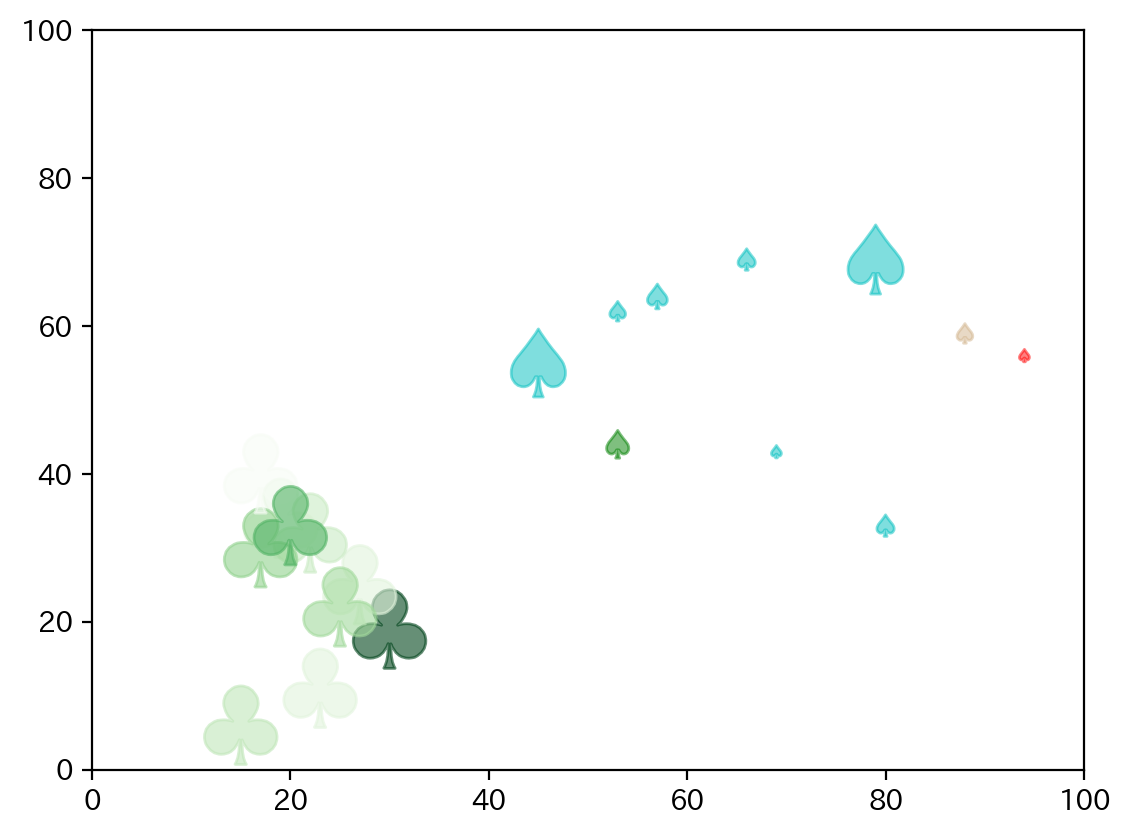

In [23]:
# データ点毎の色とサイズを同時に指定
mysize = [600, 20, 100, 50, 80, 620, 50, 20, 60, 60]
mycolor = ['c', 'r', 'g', 'tan', 'c', 'c', 'c', 'c', 'c', 'c']
plt.xlim(0,100)
plt.ylim(0,100)
plt.scatter(df_data["data1"], df_data["data4"], marker="$\\spadesuit$", c=mycolor, s=mysize, alpha=0.5)

# 色によるz軸情報の可視化：colormapの利用
plt.scatter(df_data["data2"],df_data["data3"],marker="$\\clubsuit$",c=df_data["data5"],cmap='Greens_r',s=800,alpha=0.6);

#### プロットへのラベル付け
ここでは例として、Excelデータのdataタブのx軸を"data4"、y軸を"data1"、ラベルとしては"data4"（つまりx座標）の値に# を付けたものを付記することを考える。

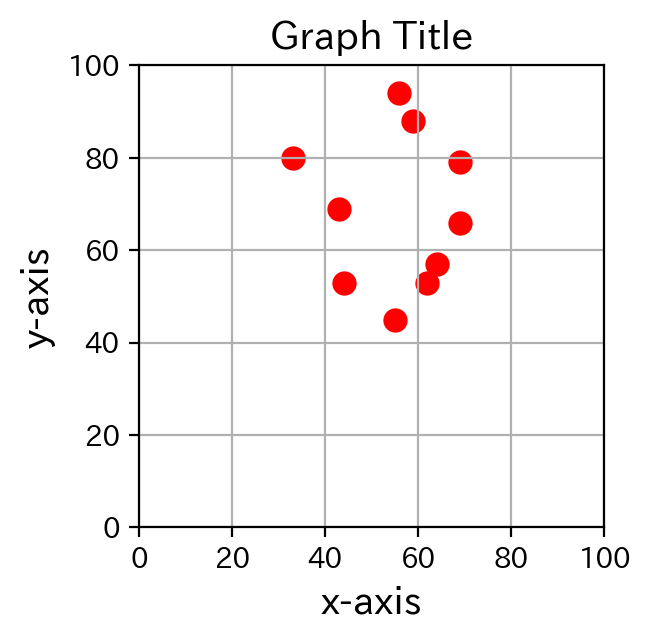

In [24]:
# データ点毎の色とサイズを同時に指定
plt.figure(figsize=(3,3))
plt.xlim(0,100)
plt.ylim(0,100)

# グリッド線の設定
plt.grid(True)
# タイトル
plt.title("Graph Title", fontsize=14)
# x, y軸名指定
plt.xlabel("x-axis", fontsize=14)
plt.ylabel("y-axis", fontsize=14)
# 透明度(alpha)の指定
plt.scatter(df_data["data4"], df_data["data1"], c="r", s=60);

#### 描画順 (zorder) の指定
例えば上のグラフでは、プロットの上にグリッドが来ており、この z方向 の描画順を指定したい。 前後関係を指定したい部分（ここではplt.grid とplt.scatter）にzorder を指定する。

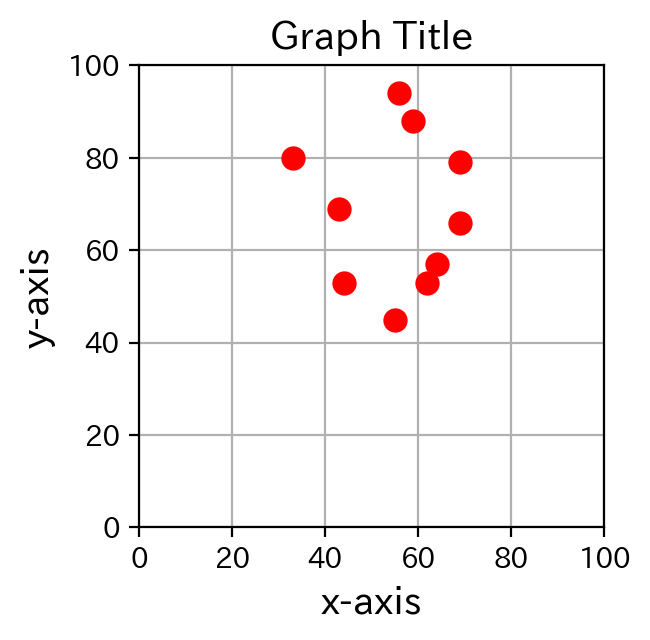

In [25]:
# データ点毎の色とサイズを同時に指定
plt.figure(figsize=(3,3))
plt.xlim(0,100)
plt.ylim(0,100)

# グリッド線の設定
plt.grid(True, zorder=1)
# タイトル
plt.title("Graph Title", fontsize=14)
# x, y軸名指定
plt.xlabel("x-axis", fontsize=14)
plt.ylabel("y-axis", fontsize=14)
# 透明度(alpha)の指定
plt.scatter(df_data["data4"], df_data["data1"], c="r", s=60, zorder=2);

['#55', '#56', '#44', '#59', '#64', '#69', '#62', '#43', '#33', '#69']


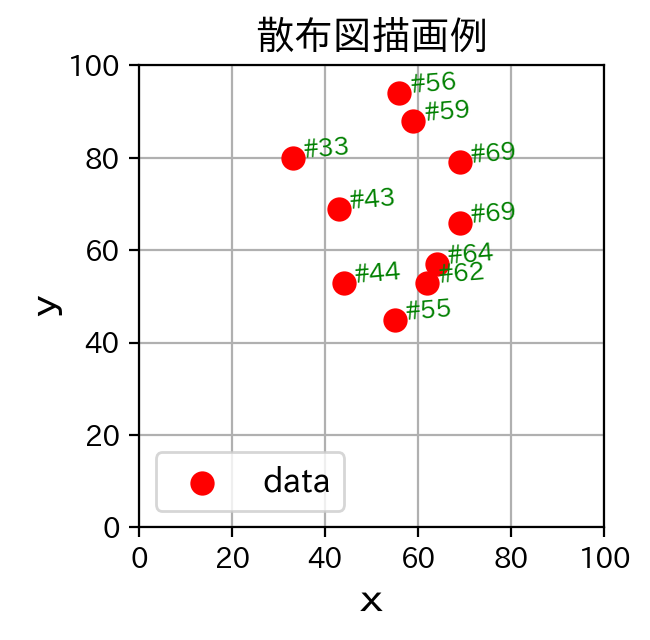

In [26]:
# グラフサイズ指定
plt.figure(figsize=(3,3))

# タイトル指定
plt.title("散布図描画例", fontsize=14)

# x, y軸名指定
plt.xlabel("ｘ", fontsize=14)
plt.ylabel("ｙ", fontsize=14)

# y軸範囲の指定
plt.xlim(0, 100)
plt.ylim(0, 100)

# グリッド線の設定
plt.grid(True, zorder=1)

# データプロット（散布図）
plt.scatter(df_data["data4"],df_data["data1"],color="r",marker="o",s=60,label="data",zorder=2)

# 内包表記によるリスト作成(f文字列を使用)
label_list = [f"#{m}" for m in df_data["data4"]]
print(label_list)

# 各プロット点への注釈
for i, label in enumerate(label_list):
    s = plt.annotate(label, (df_data["data4"][i]+2, df_data["data1"][i]))
    s.set_fontsize(9)
    s.set_rotation(5)
    s.set_color('green')

# 凡例の表示（plot文で、label= と記述する）
plt.legend(loc="lower left", fontsize=12)

# 編集可能なベクター形式(svg)での保存
plt.savefig("scatter.svg", bbox_inches="tight")

#### 実践例：World Bankデータの描画
https://data.worldbank.org/topic/economy-and-growth

In [27]:
df_wb = pd.read_excel(datafile, sheet_name = "worldbank")

# 一次所得支払（BN.GSR.FCTY.CD: 生産要素（労働、金融資産、土地、天然資源）の提供から生じる収益）
df_wb.head()

,country,一次所得支払,一人あたりGDP,出生時平均寿命,人口
0,CHN,-1.244760e+11,12617.505100,78.211000,1412360000
1,IND,-3.762011e+10,2238.127142,67.240000,1407563842
2,USA,1.499280e+11,70219.472450,76.329268,332031554
3,IDN,-3.196062e+10,4334.215983,67.570000,273753191
4,PAK,-4.388000e+09,1506.108293,66.098000,231402117


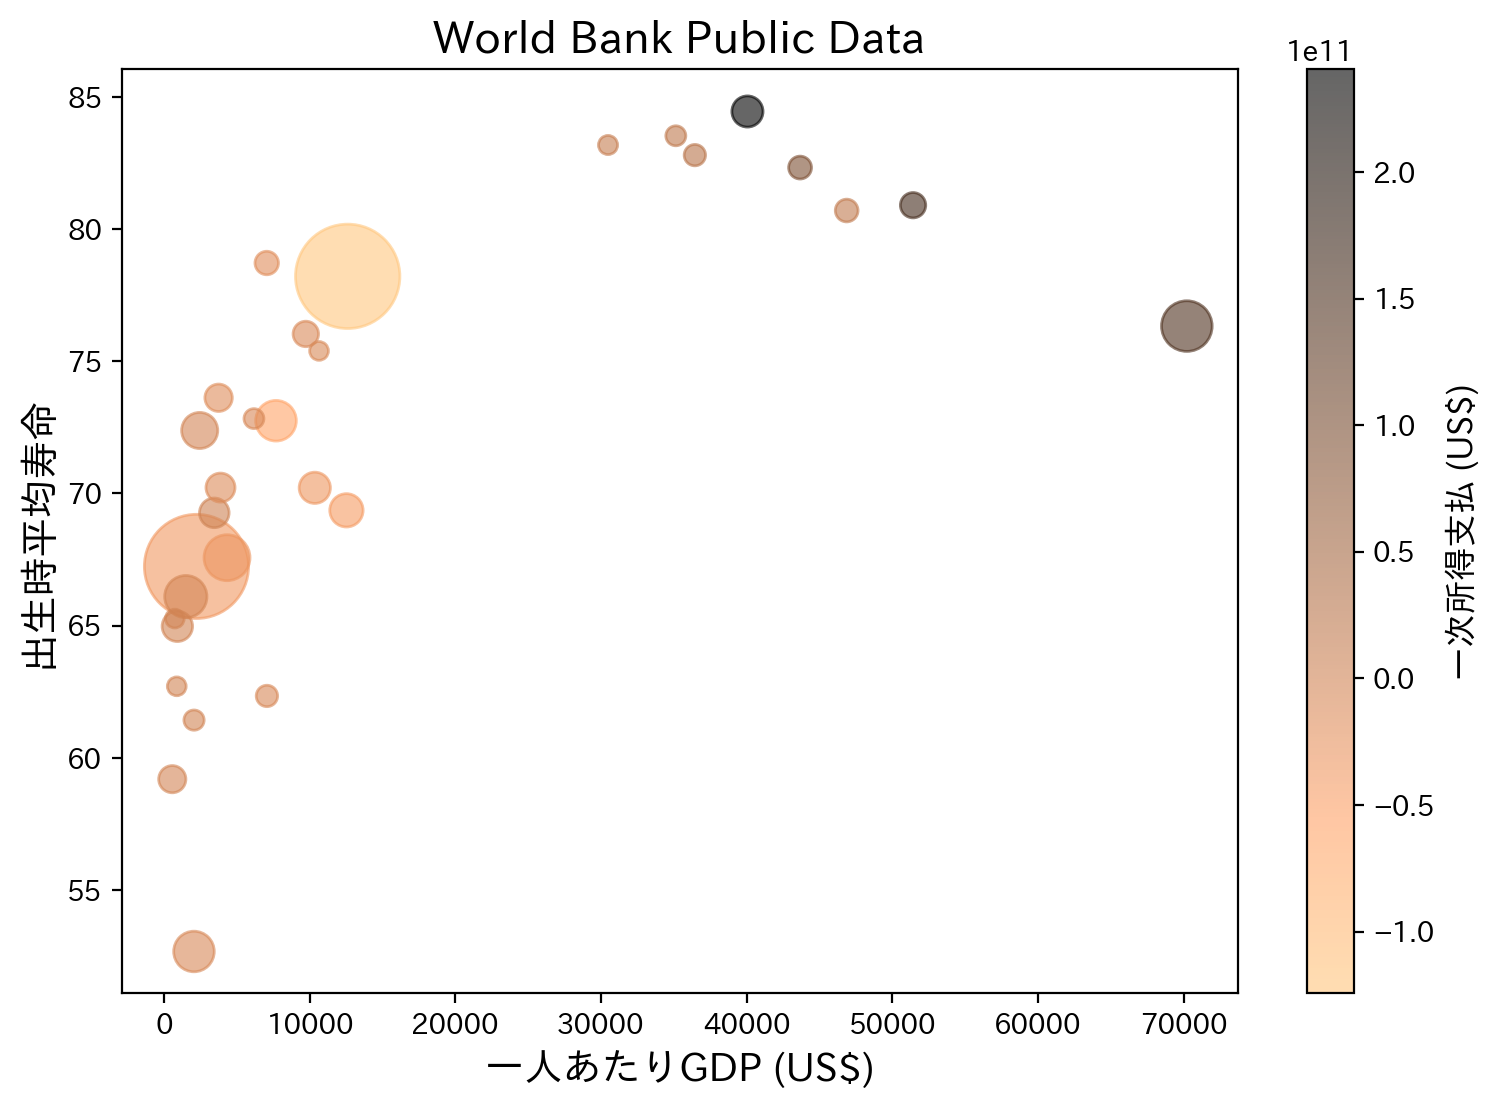

In [28]:
# グラフサイズ指定
plt.figure(figsize=(9,6))

# タイトル指定
plt.title("World Bank Public Data", fontsize=16)

# x, y軸名指定
plt.xlabel("一人あたりGDP (US$)", fontsize=14)
plt.ylabel("出生時平均寿命", fontsize=14)

# データプロット（散布図）
plt.scatter(df_wb["一人あたりGDP"], df_wb["出生時平均寿命"], marker="o", 
            s=df_wb["人口"]/1000000, alpha=0.6, c=df_wb["一次所得支払"], cmap='copper_r')

# color bar の表示
a=plt.colorbar()
a.set_label("一次所得支払 (US$)", fontsize=12)

# グラフの保存（透明化処理あり）
plt.savefig("worldbank.png", bbox_inches="tight", dpi=360, transparent=True)

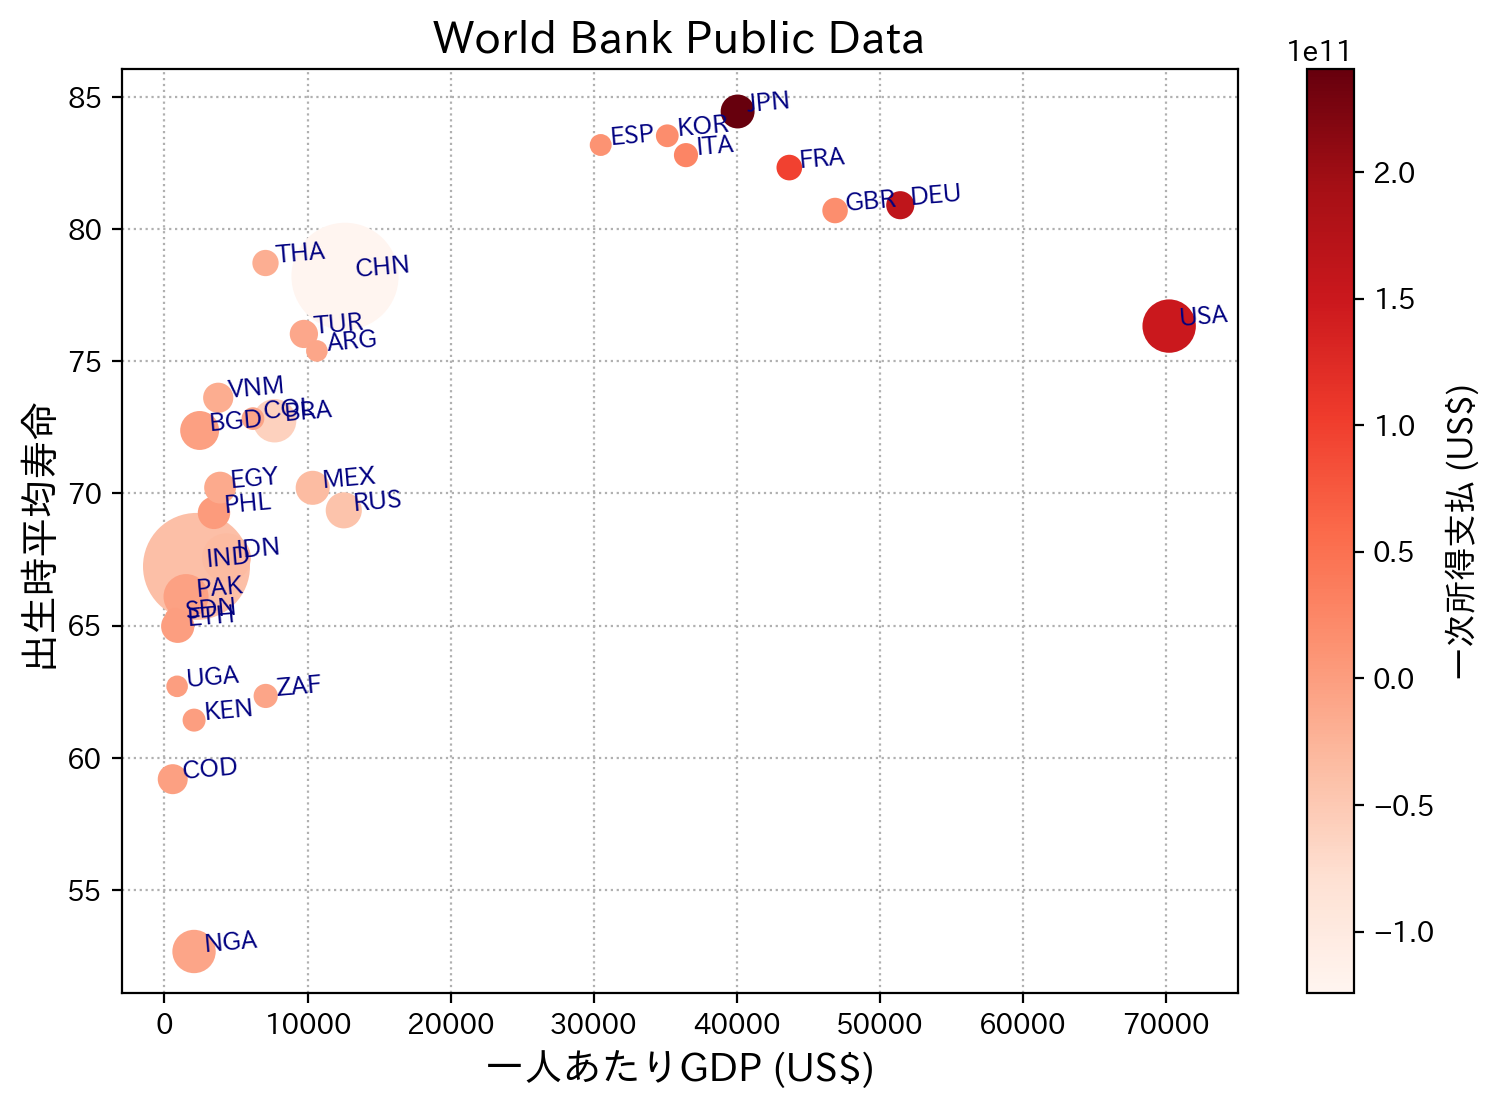

In [29]:
# グラフサイズ指定
plt.figure(figsize=(9,6))

# タイトル指定
plt.title("World Bank Public Data", fontsize=16)

# x, y軸名指定
plt.xlabel("一人あたりGDP (US$)", fontsize=14)
plt.ylabel("出生時平均寿命", fontsize=14)

# y軸範囲の指定
plt.xlim(-3000, 75000)
#plt.ylim(0, 90)

# グリッド線の設定
plt.grid(True, linestyle=":", zorder=1)

# データプロット（散布図）
plt.scatter(df_wb["一人あたりGDP"], df_wb["出生時平均寿命"], marker="o", s=df_wb["人口"]/1000000, 
            alpha=1, c=df_wb["一次所得支払"], cmap='Reds', zorder=2)

# 各プロット点への注釈
label_list = df_wb["country"]

# color bar の表示
a=plt.colorbar()
a.set_label("一次所得支払 (US$)", fontsize=12)

for i, label in enumerate(label_list):
    s = plt.annotate(label, (df_wb["一人あたりGDP"][i]+600, df_wb["出生時平均寿命"][i]))
    s.set_fontsize(9)
    s.set_rotation(5)
    s.set_color('navy');

### スタイルファイルの適用

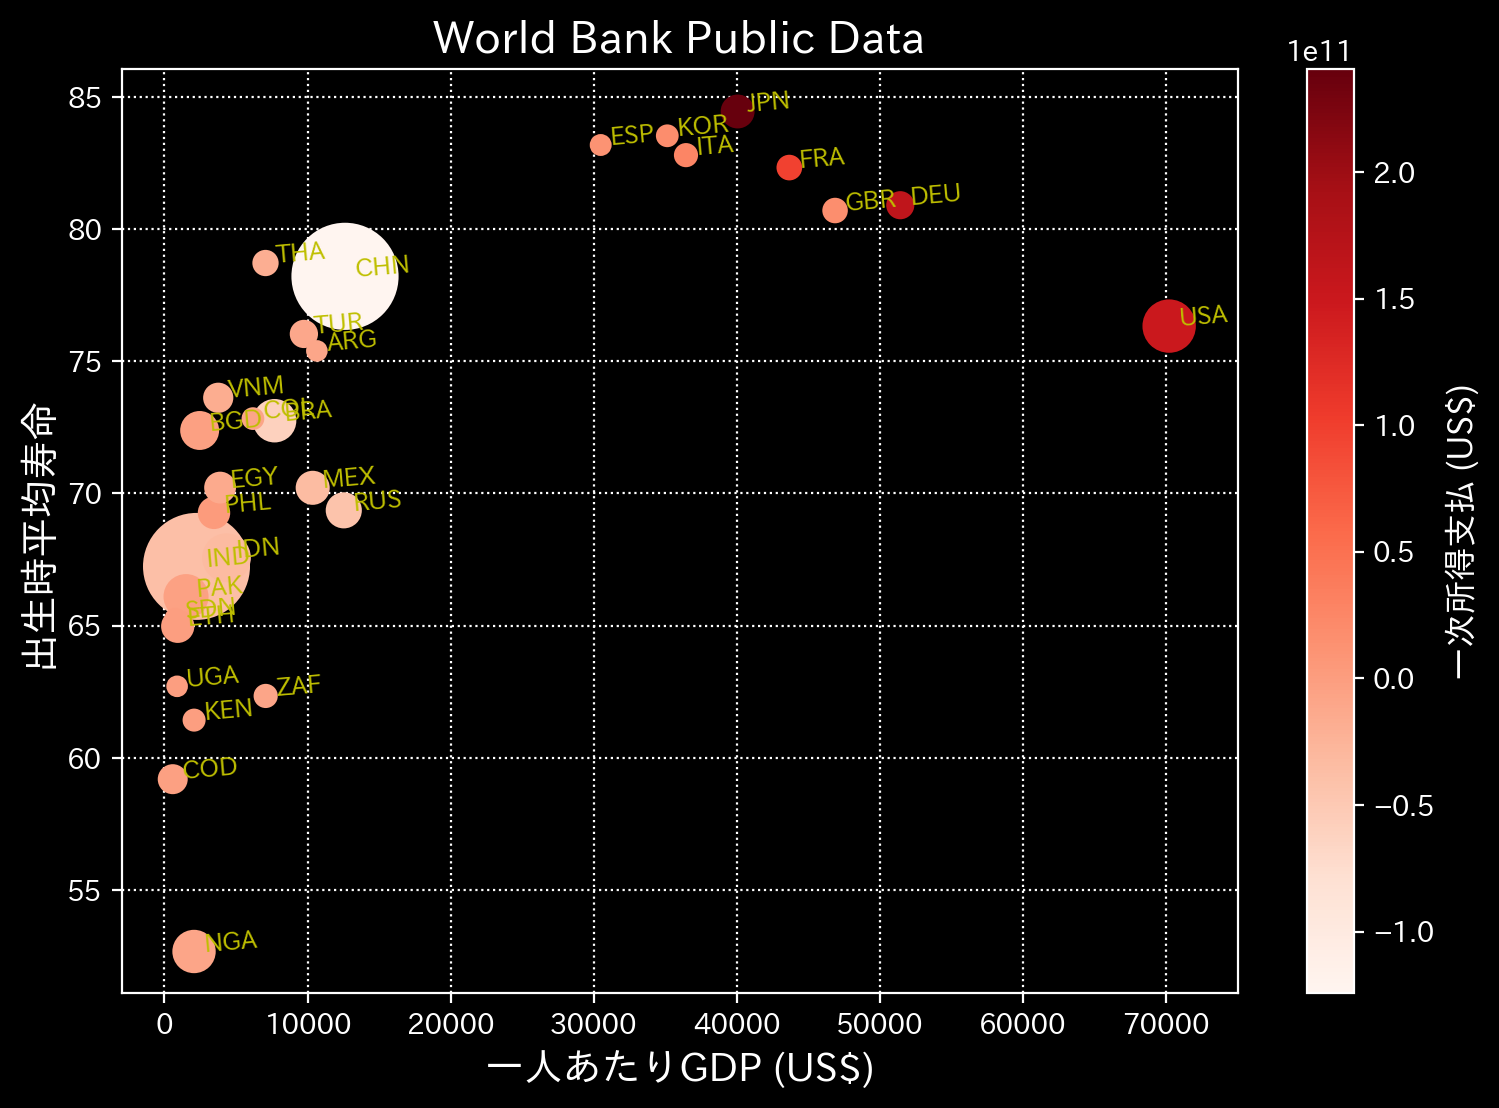

In [30]:
with plt.style.context("dark_background"):
    # グラフサイズ指定
    plt.figure(figsize=(9,6))

    # タイトル指定
    plt.title("World Bank Public Data", fontsize=16)

    # x, y軸名指定
    plt.xlabel("一人あたりGDP (US$)", fontsize=14)
    plt.ylabel("出生時平均寿命", fontsize=14)

    # y軸範囲の指定
    plt.xlim(-3000, 75000)
    #plt.ylim(0, 90)

    # グリッド線の設定
    plt.grid(True, linestyle=":", zorder=1)

    # データプロット（散布図）
    plt.scatter(df_wb["一人あたりGDP"], df_wb["出生時平均寿命"], marker="o", s=df_wb["人口"]/1000000, 
                alpha=1, c=df_wb["一次所得支払"], cmap='Reds', zorder=2)

    # 各プロット点への注釈
    label_list = df_wb["country"]

    # color bar の表示
    a=plt.colorbar()
    a.set_label("一次所得支払 (US$)", fontsize=12)

    for i, label in enumerate(label_list):
        s = plt.annotate(label, (df_wb["一人あたりGDP"][i]+600, df_wb["出生時平均寿命"][i]))
        s.set_fontsize(9)
        s.set_rotation(5)
        s.set_color('y');

In [31]:
# 適用可能なスタイルの一覧
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


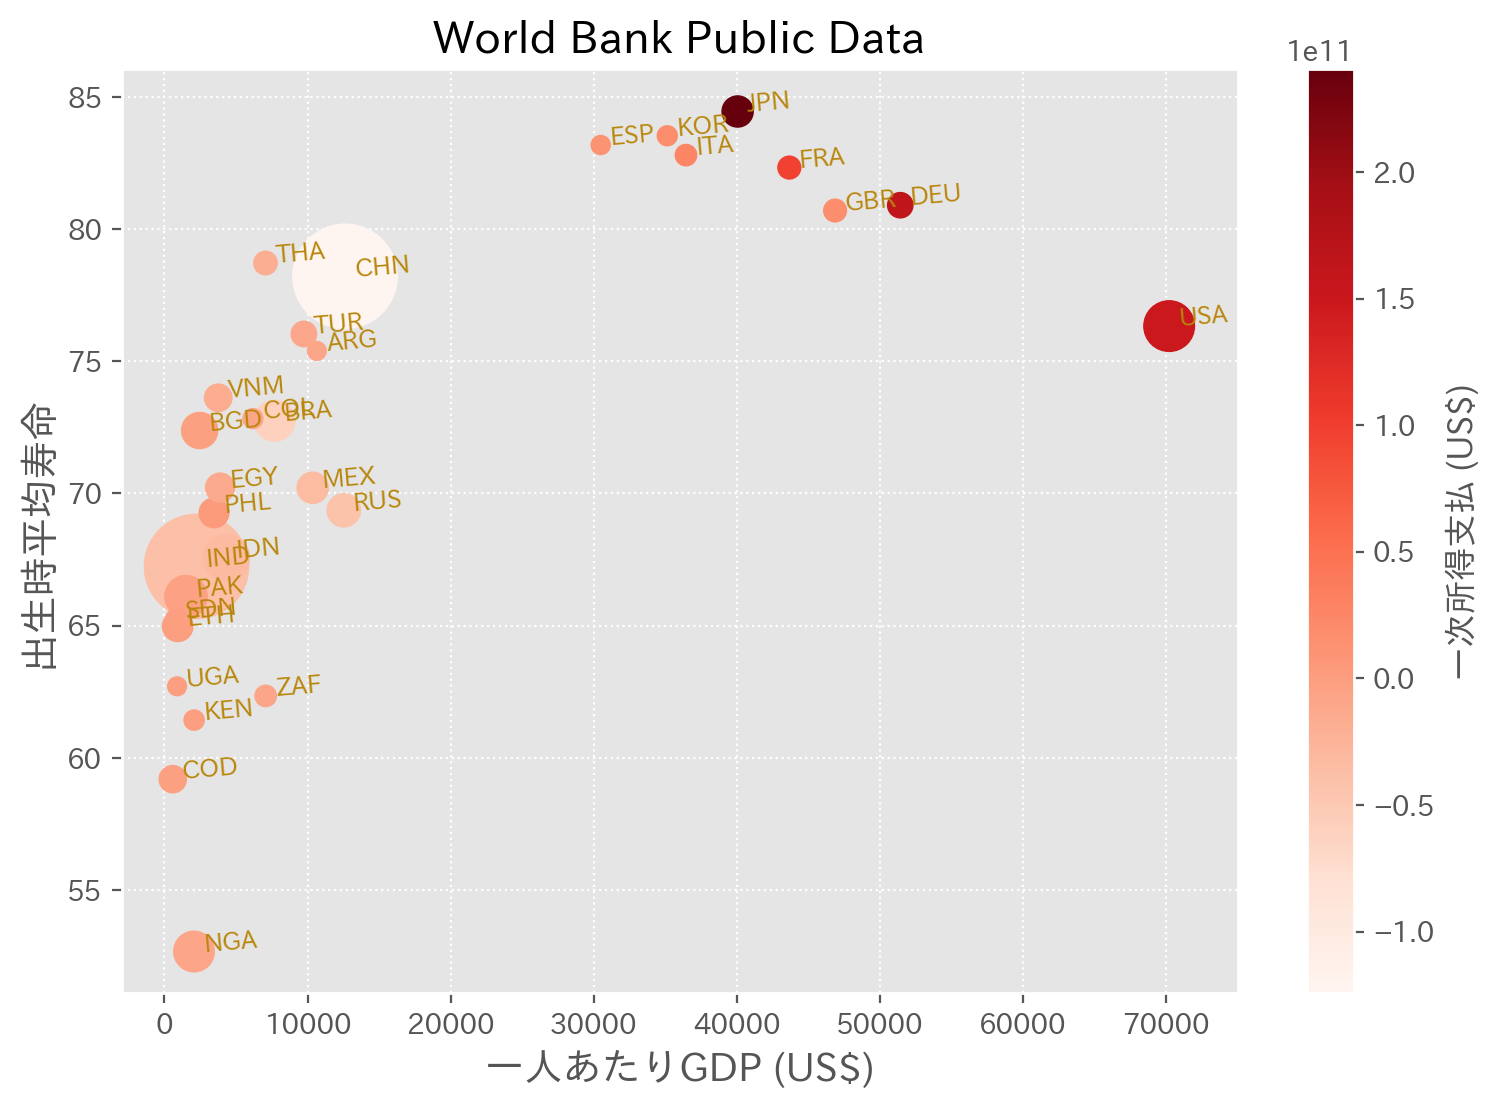

In [32]:
# スタイルの適用ではよく警告が出ますが、問題ありません。また、スタイルによっては日本語フォントが使えないものもあります。
with plt.style.context("ggplot"):
    # グラフサイズ指定
    plt.figure(figsize=(9,6))

    # タイトル指定
    plt.title("World Bank Public Data", fontsize=16)

    # x, y軸名指定
    plt.xlabel("一人あたりGDP (US$)", fontsize=14)
    plt.ylabel("出生時平均寿命", fontsize=14)

    # y軸範囲の指定
    plt.xlim(-3000, 75000)
    #plt.ylim(0, 90)

    # グリッド線の設定
    plt.grid(True, linestyle=":", zorder=1)

    # データプロット（散布図）
    plt.scatter(df_wb["一人あたりGDP"], df_wb["出生時平均寿命"], marker="o", s=df_wb["人口"]/1000000, 
                alpha=1, c=df_wb["一次所得支払"], cmap='Reds', zorder=2)

    # 各プロット点への注釈
    label_list = df_wb["country"]

    # color bar の表示
    a=plt.colorbar()
    a.set_label("一次所得支払 (US$)", fontsize=12)

    for i, label in enumerate(label_list):
        s = plt.annotate(label, (df_wb["一人あたりGDP"][i]+600, df_wb["出生時平均寿命"][i]))
        s.set_fontsize(9)
        s.set_rotation(5)
        s.set_color('darkgoldenrod');

#### xkcd スタイルの適用
こちらは日本語フォントは使えませんので注意。 フォント関係の警告が出ますが、グラフ作成には支障ありません。

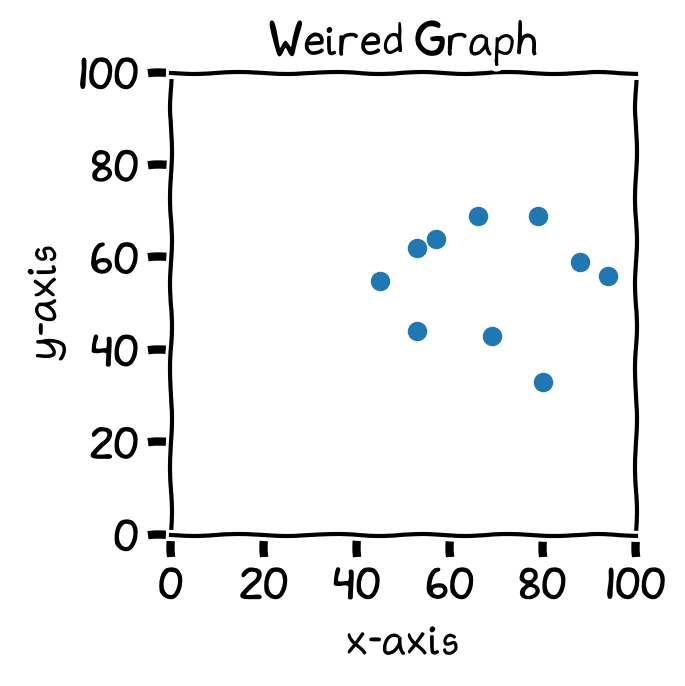

In [33]:
with plt.xkcd():
    # データ点毎の色とサイズを同時に指定
    mysize=[600, 20, 100, 50, 80, 620, 50, 20, 60, 60]
    mycolor=['c', 'r', 'g', 'tan', 'c', 'c', 'c', 'c', 'c', 'c']
    plt.figure(figsize=(3,3))
    plt.xlim(0,100)
    plt.ylim(0,100)
    
    # タイトル
    plt.title("Weired Graph", fontsize=16)

    # x, y軸名指定
    plt.xlabel("x-axis", fontsize=16)
    plt.ylabel("y-axis", fontsize=16)
    plt.scatter(df_data["data1"], df_data["data4"]);

### 3. 棒グラフの作成
https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html

In [34]:
df_ramen = pd.read_excel(datafile, sheet_name = "ramen")
df_ramen.head()

,city,Y2021,Y2022,Y2023
0,札幌市,6041,5722,6533
1,青森市,7875,9487,9660
2,盛岡市,8462,7346,10789
3,仙台市,8067,12480,13074
4,秋田市,8544,10015,8777


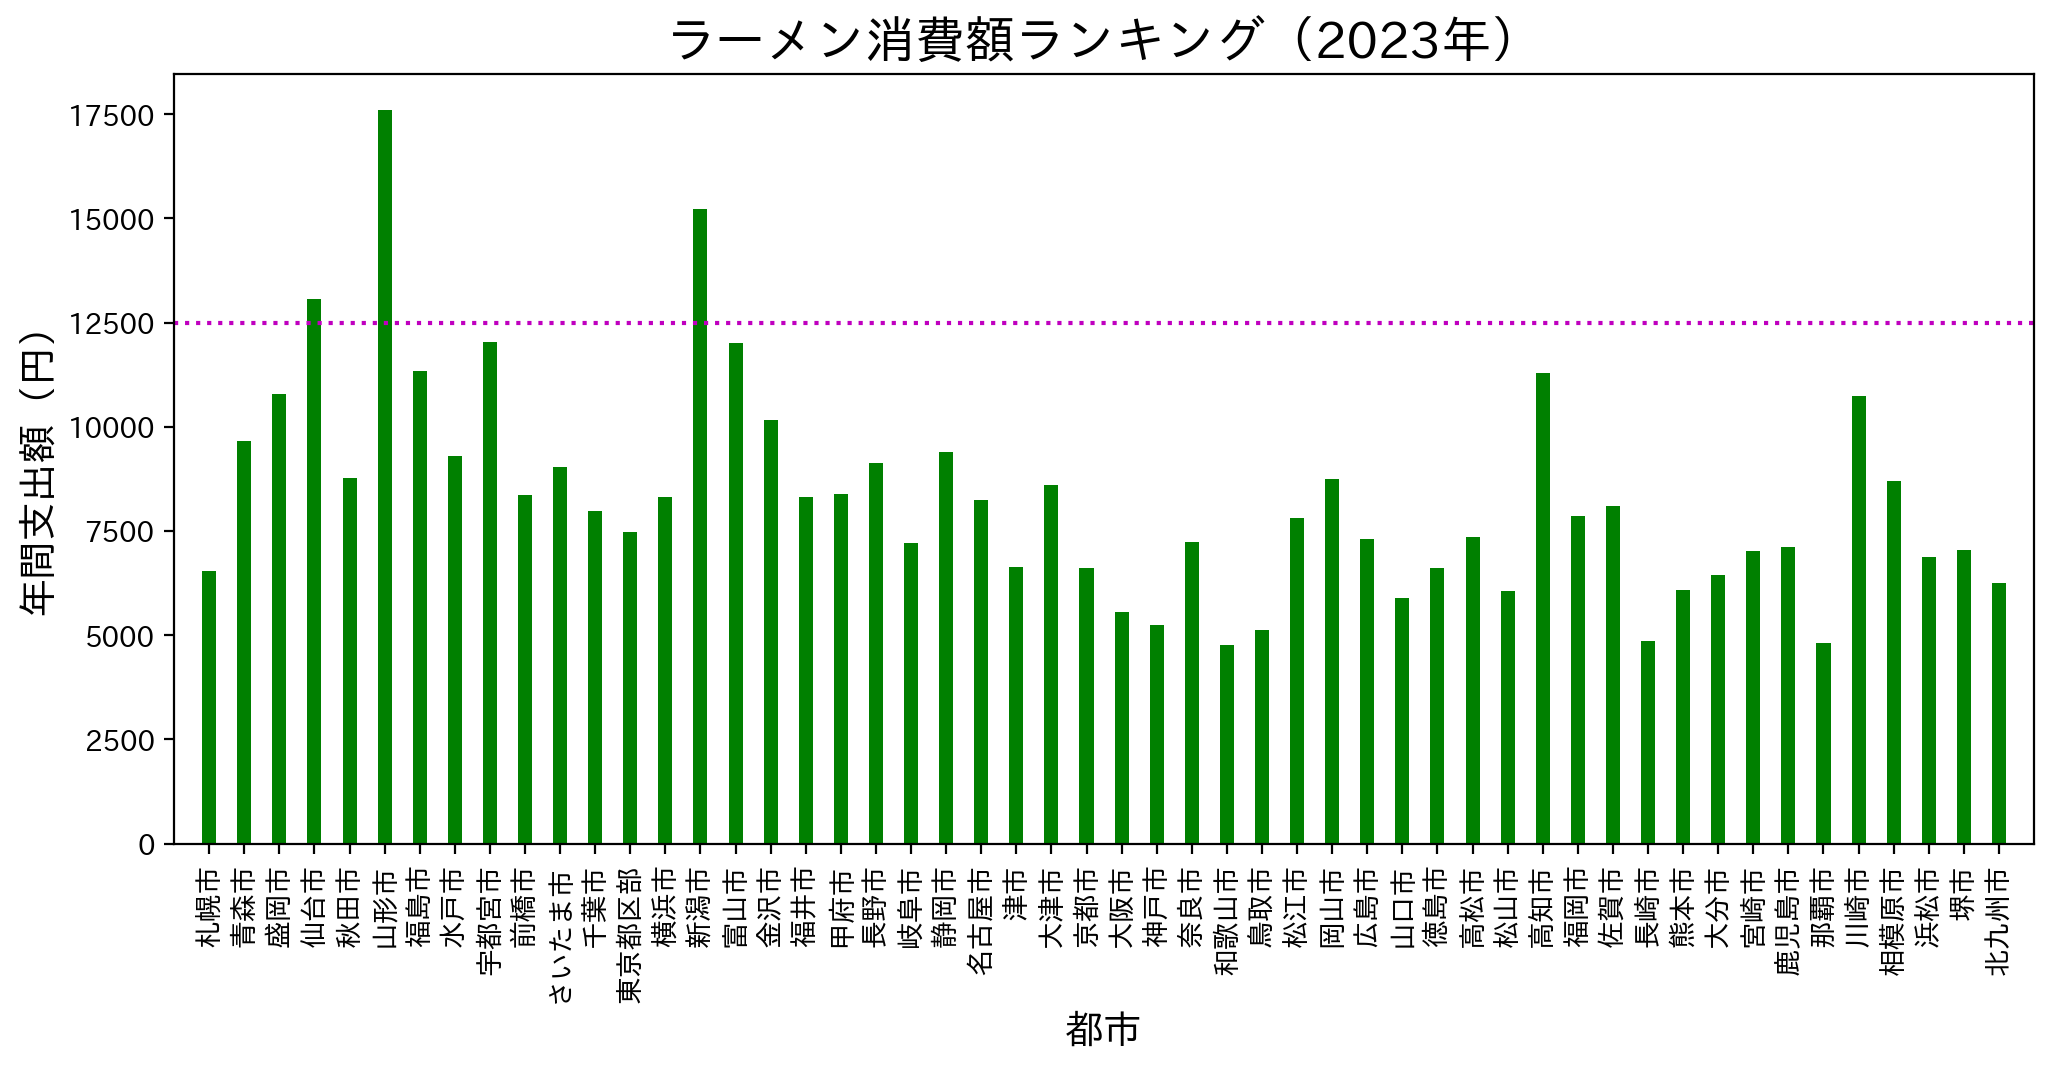

In [35]:
plt.figure(figsize=(12,5))
plt.bar(df_ramen["city"], df_ramen["Y2023"], width=0.4, color="g")

# 左右の余白を調整するため、x軸範囲を指定
plt.xlim(-1,len(df_ramen))

# 水平補助線
plt.axhline(y=12500, c='m', ls=':')

plt.title('ラーメン消費額ランキング（2023年）', fontsize=18)
plt.xlabel('都市', fontsize=14)
plt.ylabel('年間支出額（円）', fontsize=14)

# 都市名の回転
plt.xticks(rotation=90);

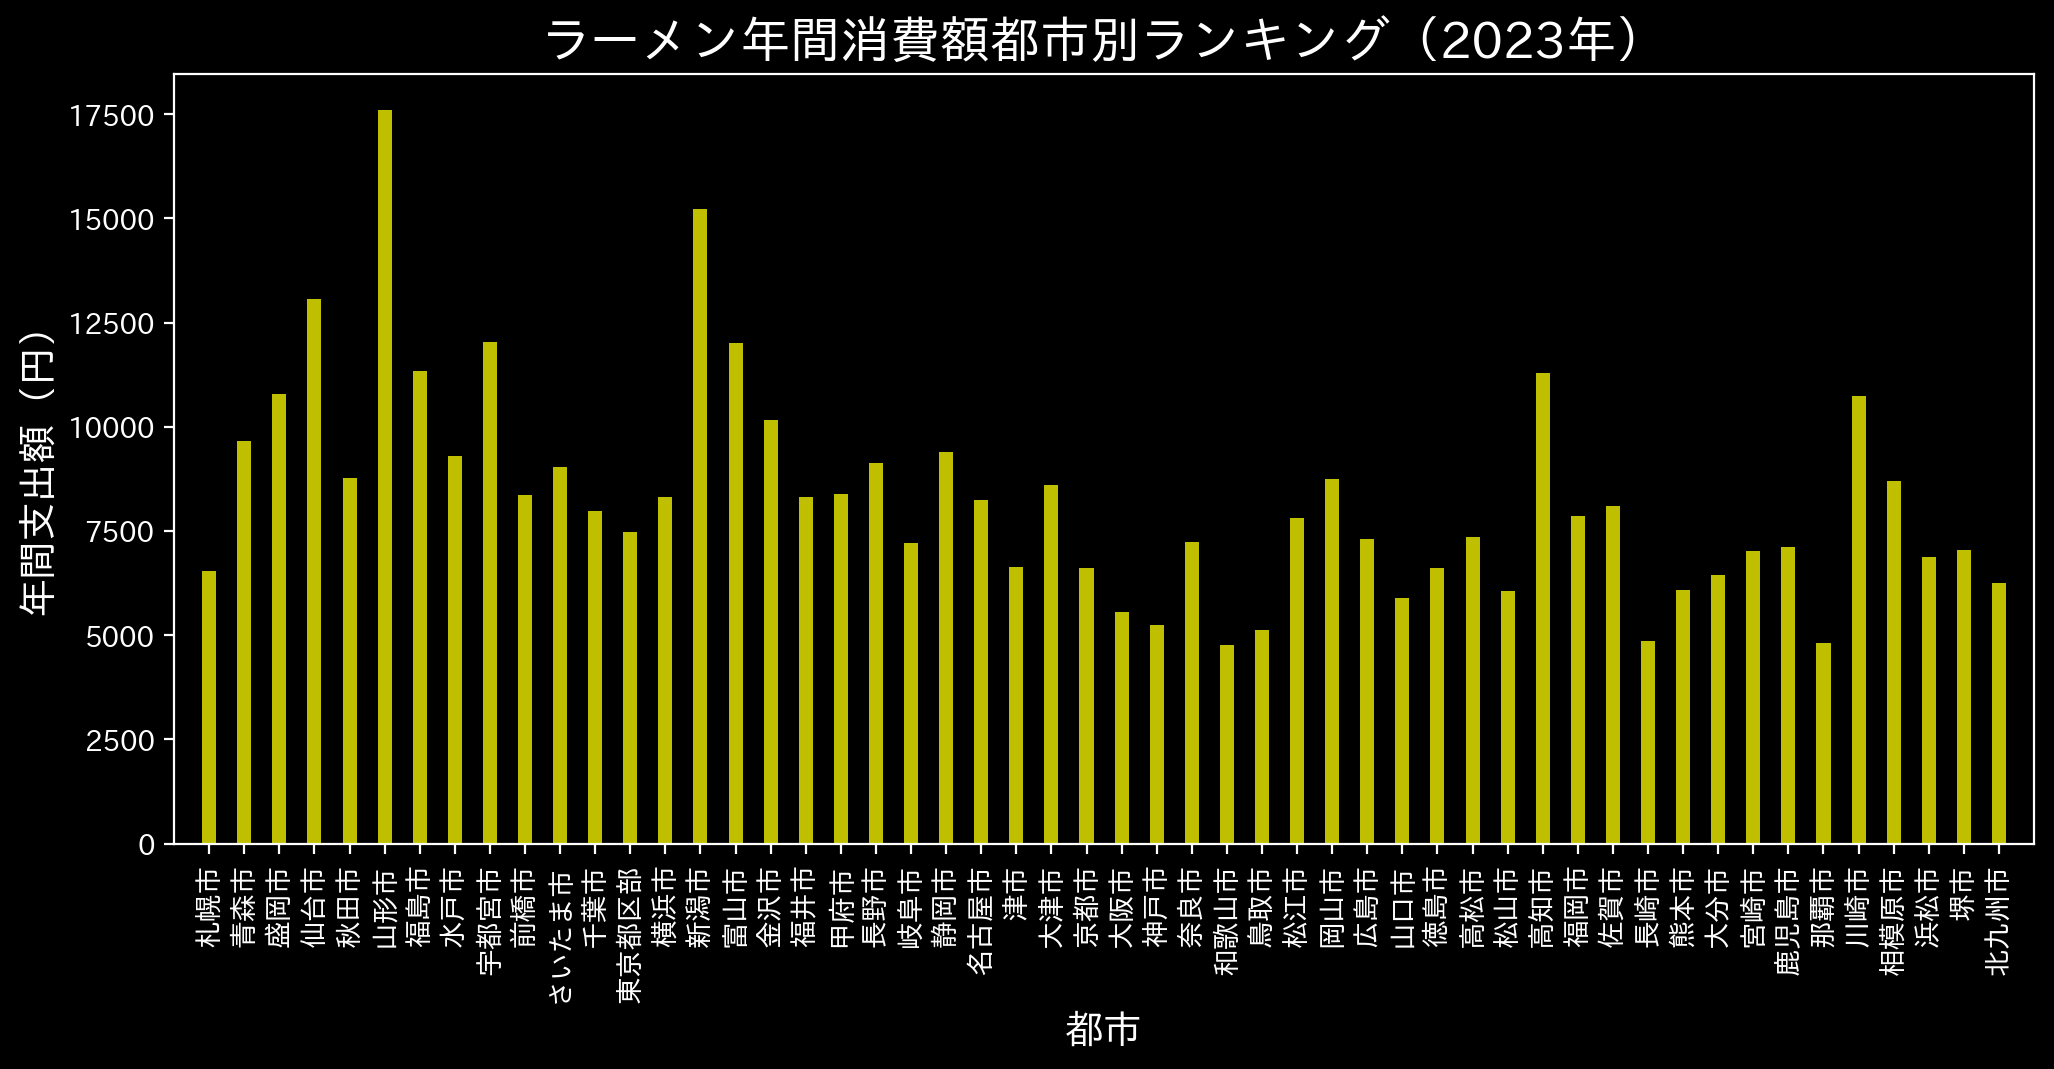

In [36]:
with plt.style.context('dark_background'):
    plt.figure(figsize=(12,5))
    plt.bar(df_ramen["city"], df_ramen["Y2023"], width=0.4, color="y")

    # 左右の余白を調整するため、x軸範囲を指定
    plt.xlim(-1,len(df_ramen))

    plt.title('ラーメン年間消費額都市別ランキング（2023年）', fontsize=18)
    plt.xlabel('都市', fontsize=14)
    plt.ylabel('年間支出額（円）', fontsize=14)

    # 都市名の回転
    plt.xticks(rotation=90)
plt.savefig("ramen.png", bbox_inches="tight", dpi=360, transparent=True);

['y', 'y', 'y', 'c', 'y', 'c', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'c', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y']


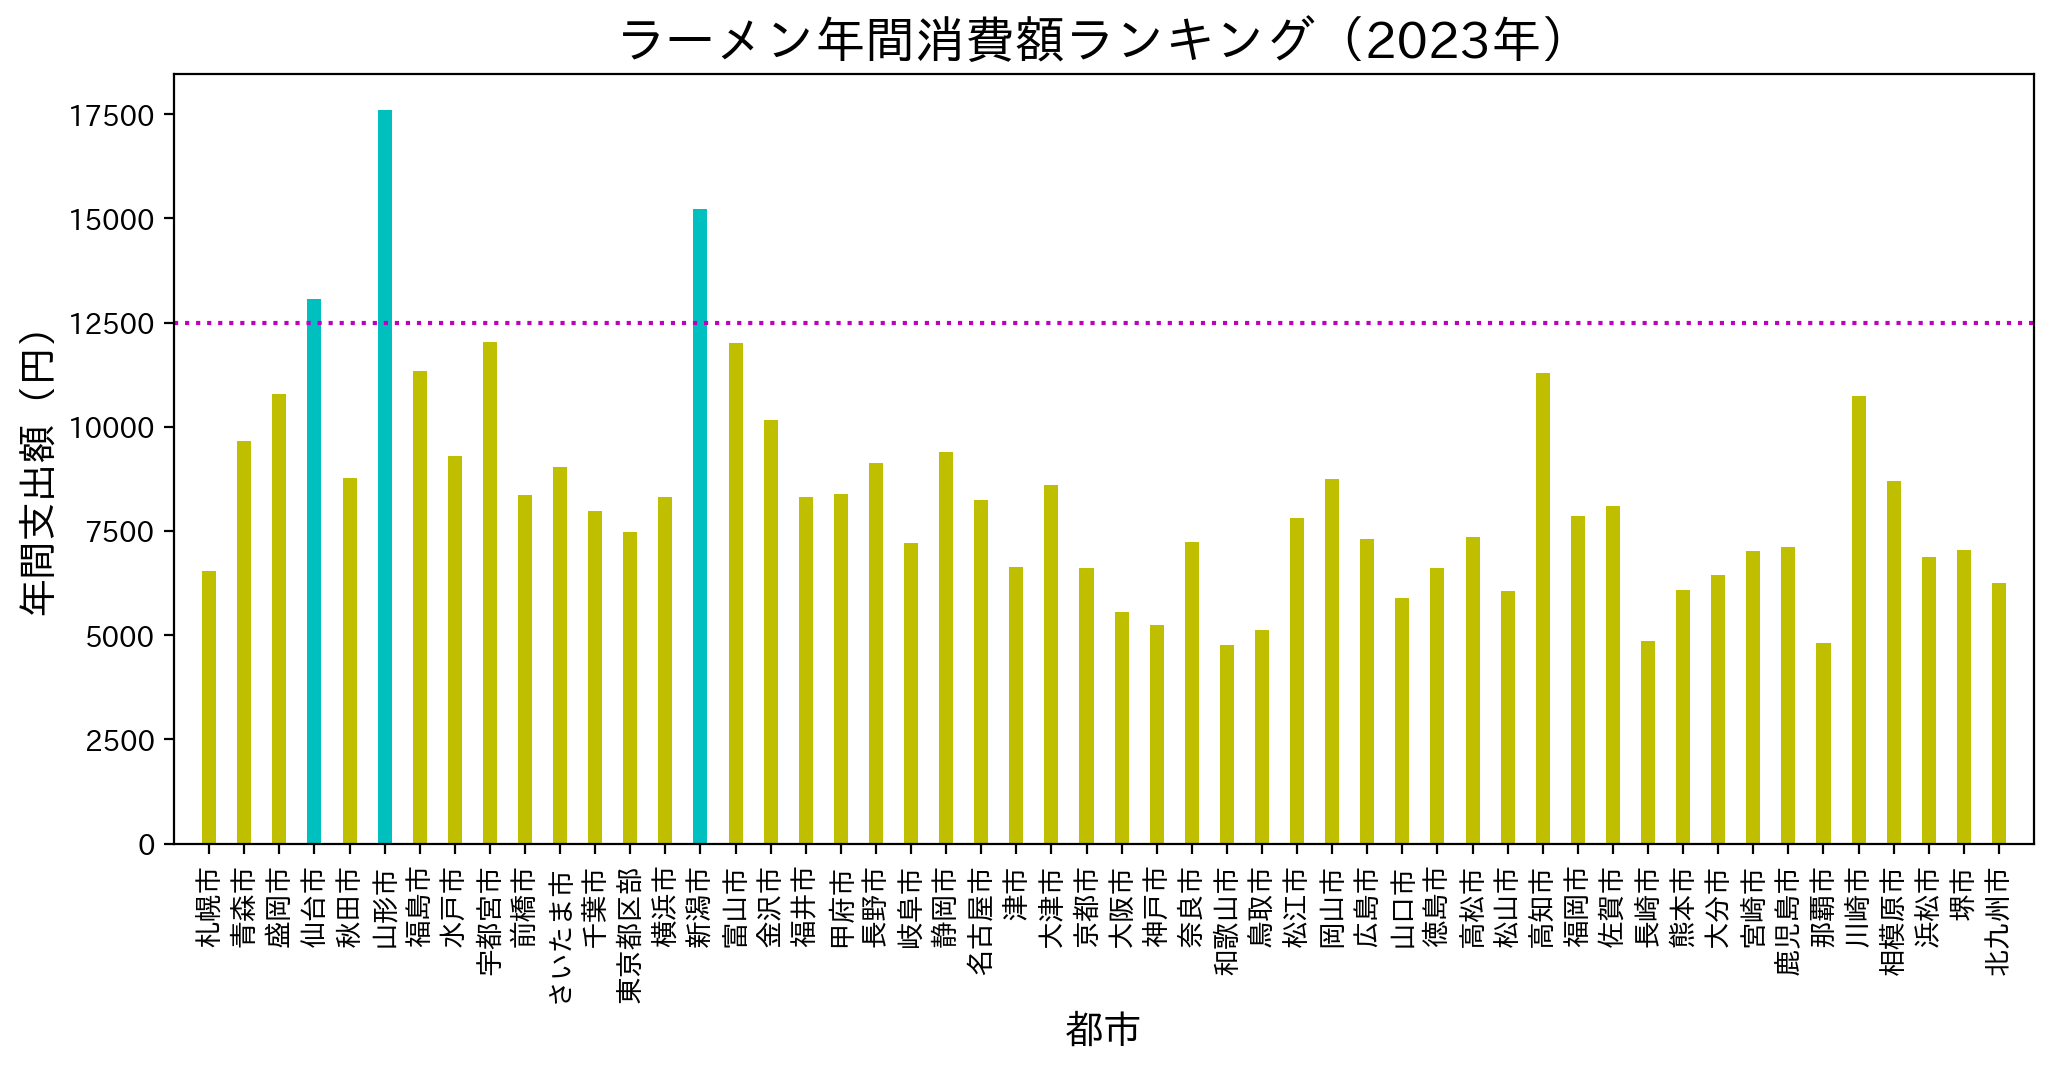

In [37]:
mycolor_ramen = ["c" if i >12500 else "y" for i in df_ramen["Y2023"]]
print(mycolor_ramen)

plt.figure(figsize=(12,5))
plt.bar(df_ramen["city"], df_ramen["Y2023"], width=0.4, color=mycolor_ramen)

# 左右の余白を調整するため、x軸範囲を指定
plt.xlim(-1,len(df_ramen))

# 水平補助線
plt.axhline(y=12500, c='m', ls=':')

plt.title('ラーメン年間消費額ランキング（2023年）', fontsize=18)
plt.xlabel('都市', fontsize=14)
plt.ylabel('年間支出額（円）', fontsize=14)

plt.xticks(rotation=90);

['y', 'y', 'y', 'c', 'y', 'c', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'c', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y', 'y']


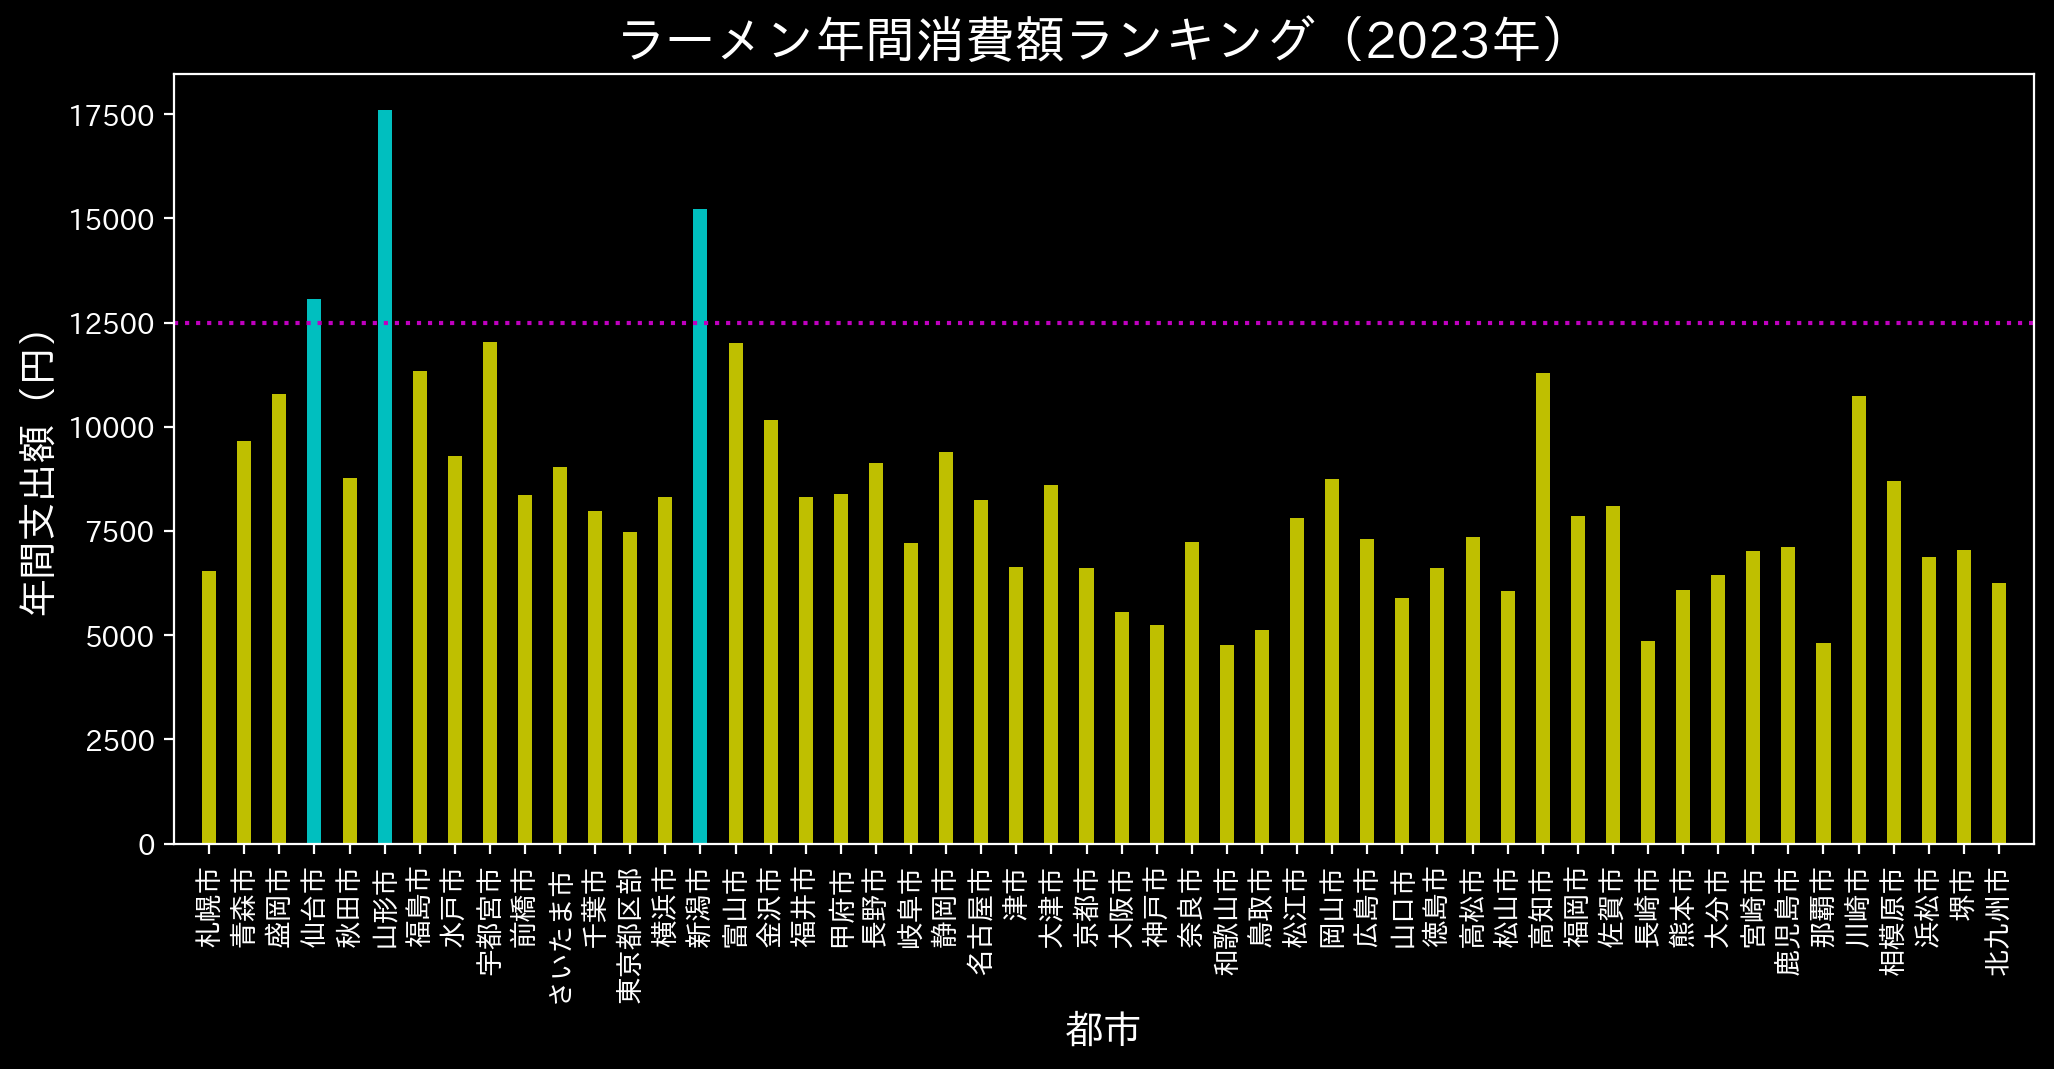

In [38]:
with plt.style.context('dark_background'):
    mycolor_ramen = ["c" if i >12500 else "y" for i in df_ramen["Y2023"]]
    print(mycolor_ramen)

    plt.figure(figsize=(12,5))
    plt.bar(df_ramen["city"], df_ramen["Y2023"], width=0.4, color=mycolor_ramen)
    plt.xlim(-1,len(df_ramen))

    # 水平補助線
    plt.axhline(y=12500, c='m', ls=':')

    plt.title('ラーメン年間消費額ランキング（2023年）', fontsize=18)
    plt.xlabel('都市', fontsize=14)
    plt.ylabel('年間支出額（円）', fontsize=14)

    plt.xticks(rotation=90)

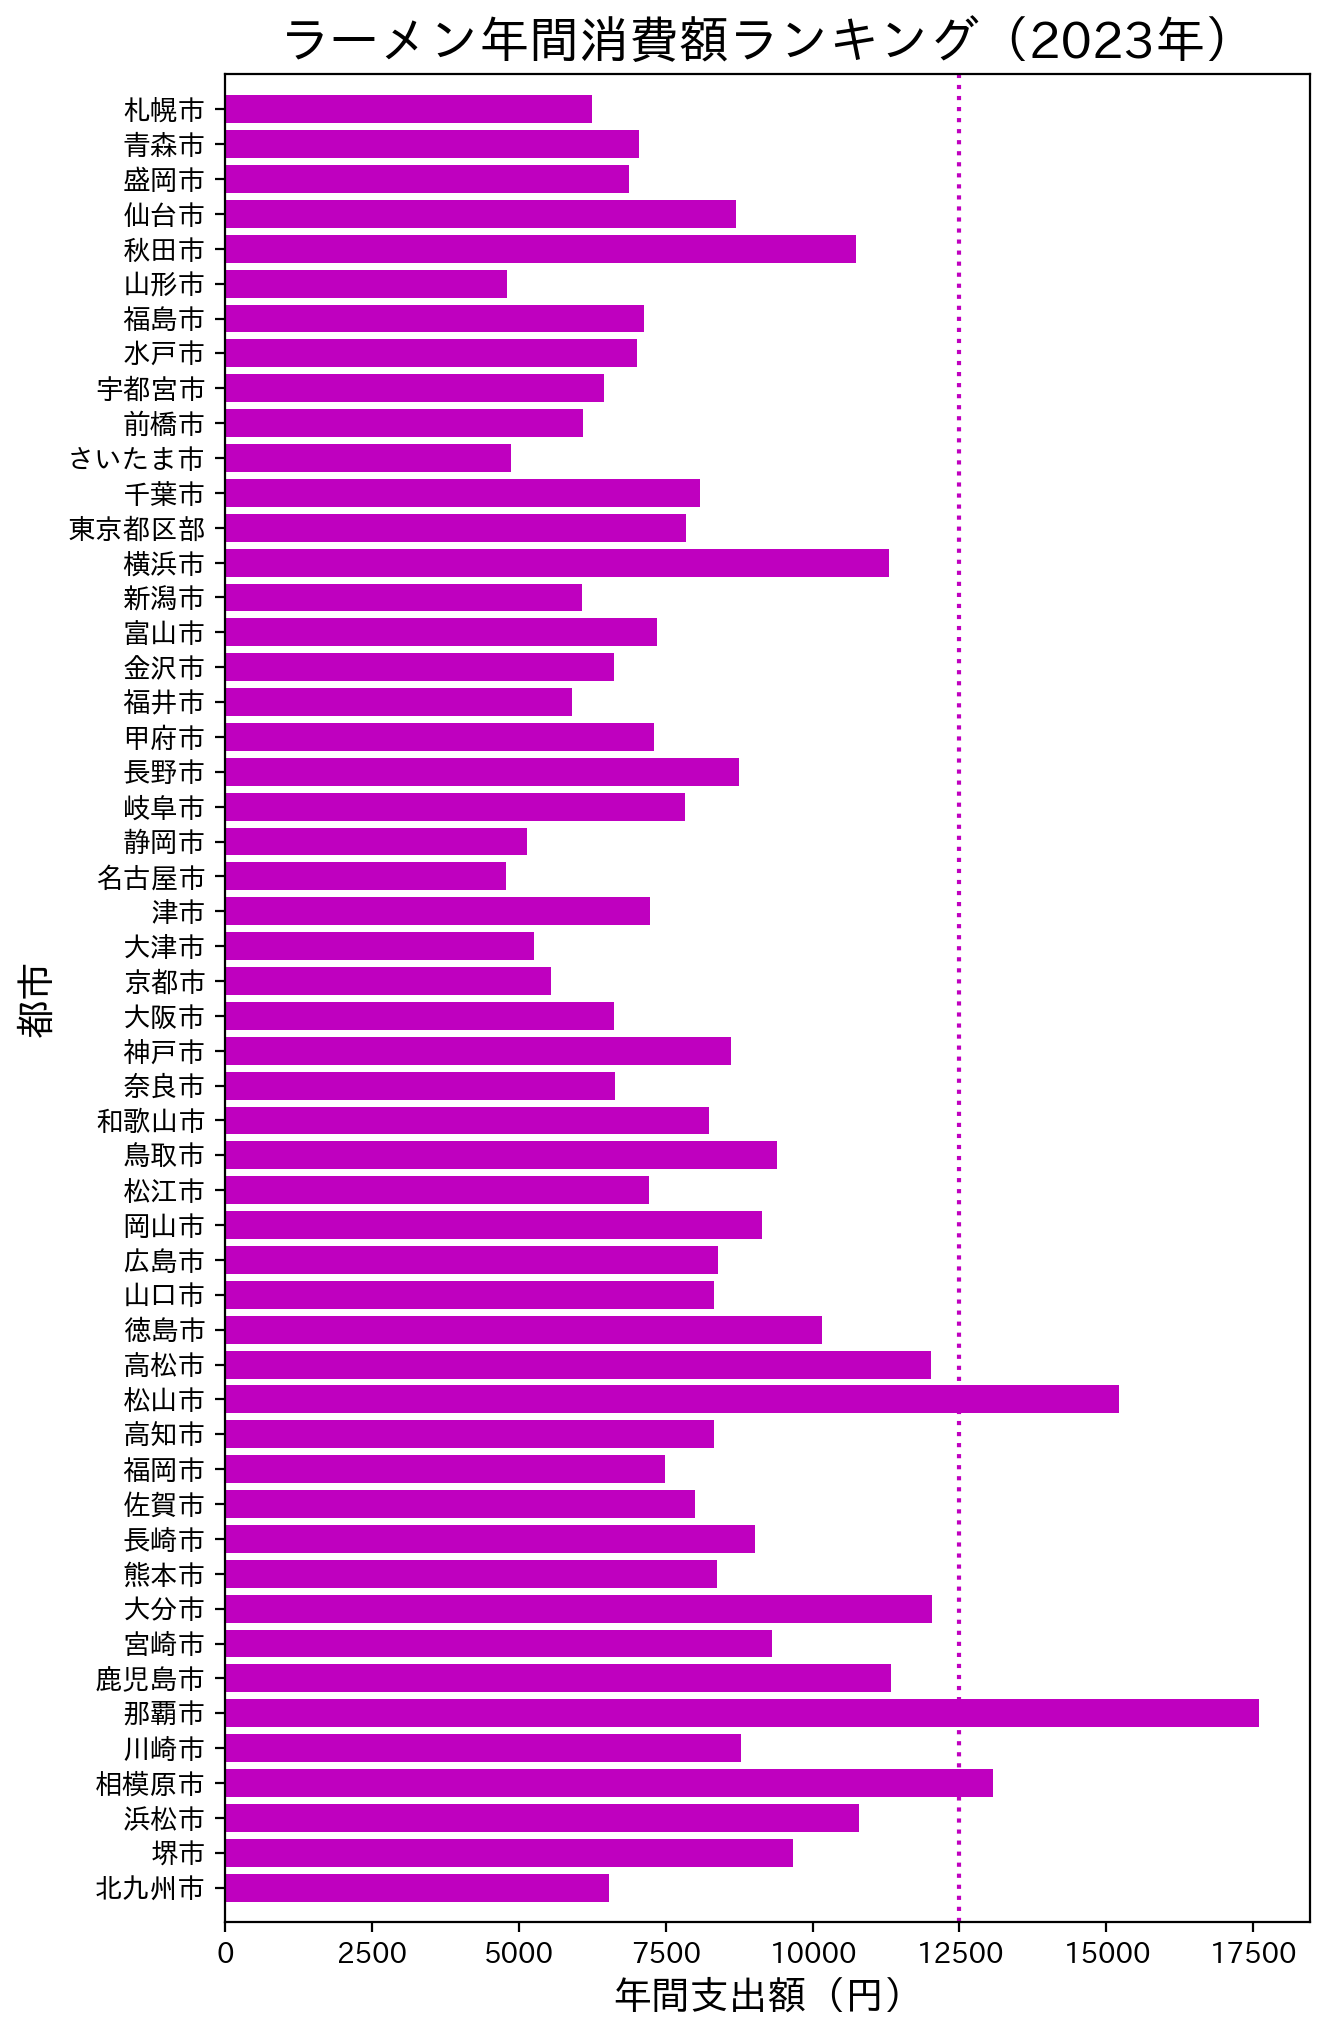

In [39]:
# 横持ち棒グラフ
plt.figure(figsize=(7,12))
plt.barh(df_ramen["city"][::-1], df_ramen["Y2023"], color="m")   # [::-1] は逆順にする操作

# 上下の余白を調整するため、y軸範囲を指定
plt.ylim(-1,len(df_ramen))

# 垂直補助線
plt.axvline(x=12500, c='m', ls=':')
plt.title('ラーメン年間消費額ランキング（2023年）', fontsize=18)
plt.xlabel('年間支出額（円）', fontsize=14)
plt.ylabel('都市', fontsize=14)
plt.xticks(rotation=0);

In [40]:
df_ramen.head()

,city,Y2021,Y2022,Y2023
0,札幌市,6041,5722,6533
1,青森市,7875,9487,9660
2,盛岡市,8462,7346,10789
3,仙台市,8067,12480,13074
4,秋田市,8544,10015,8777


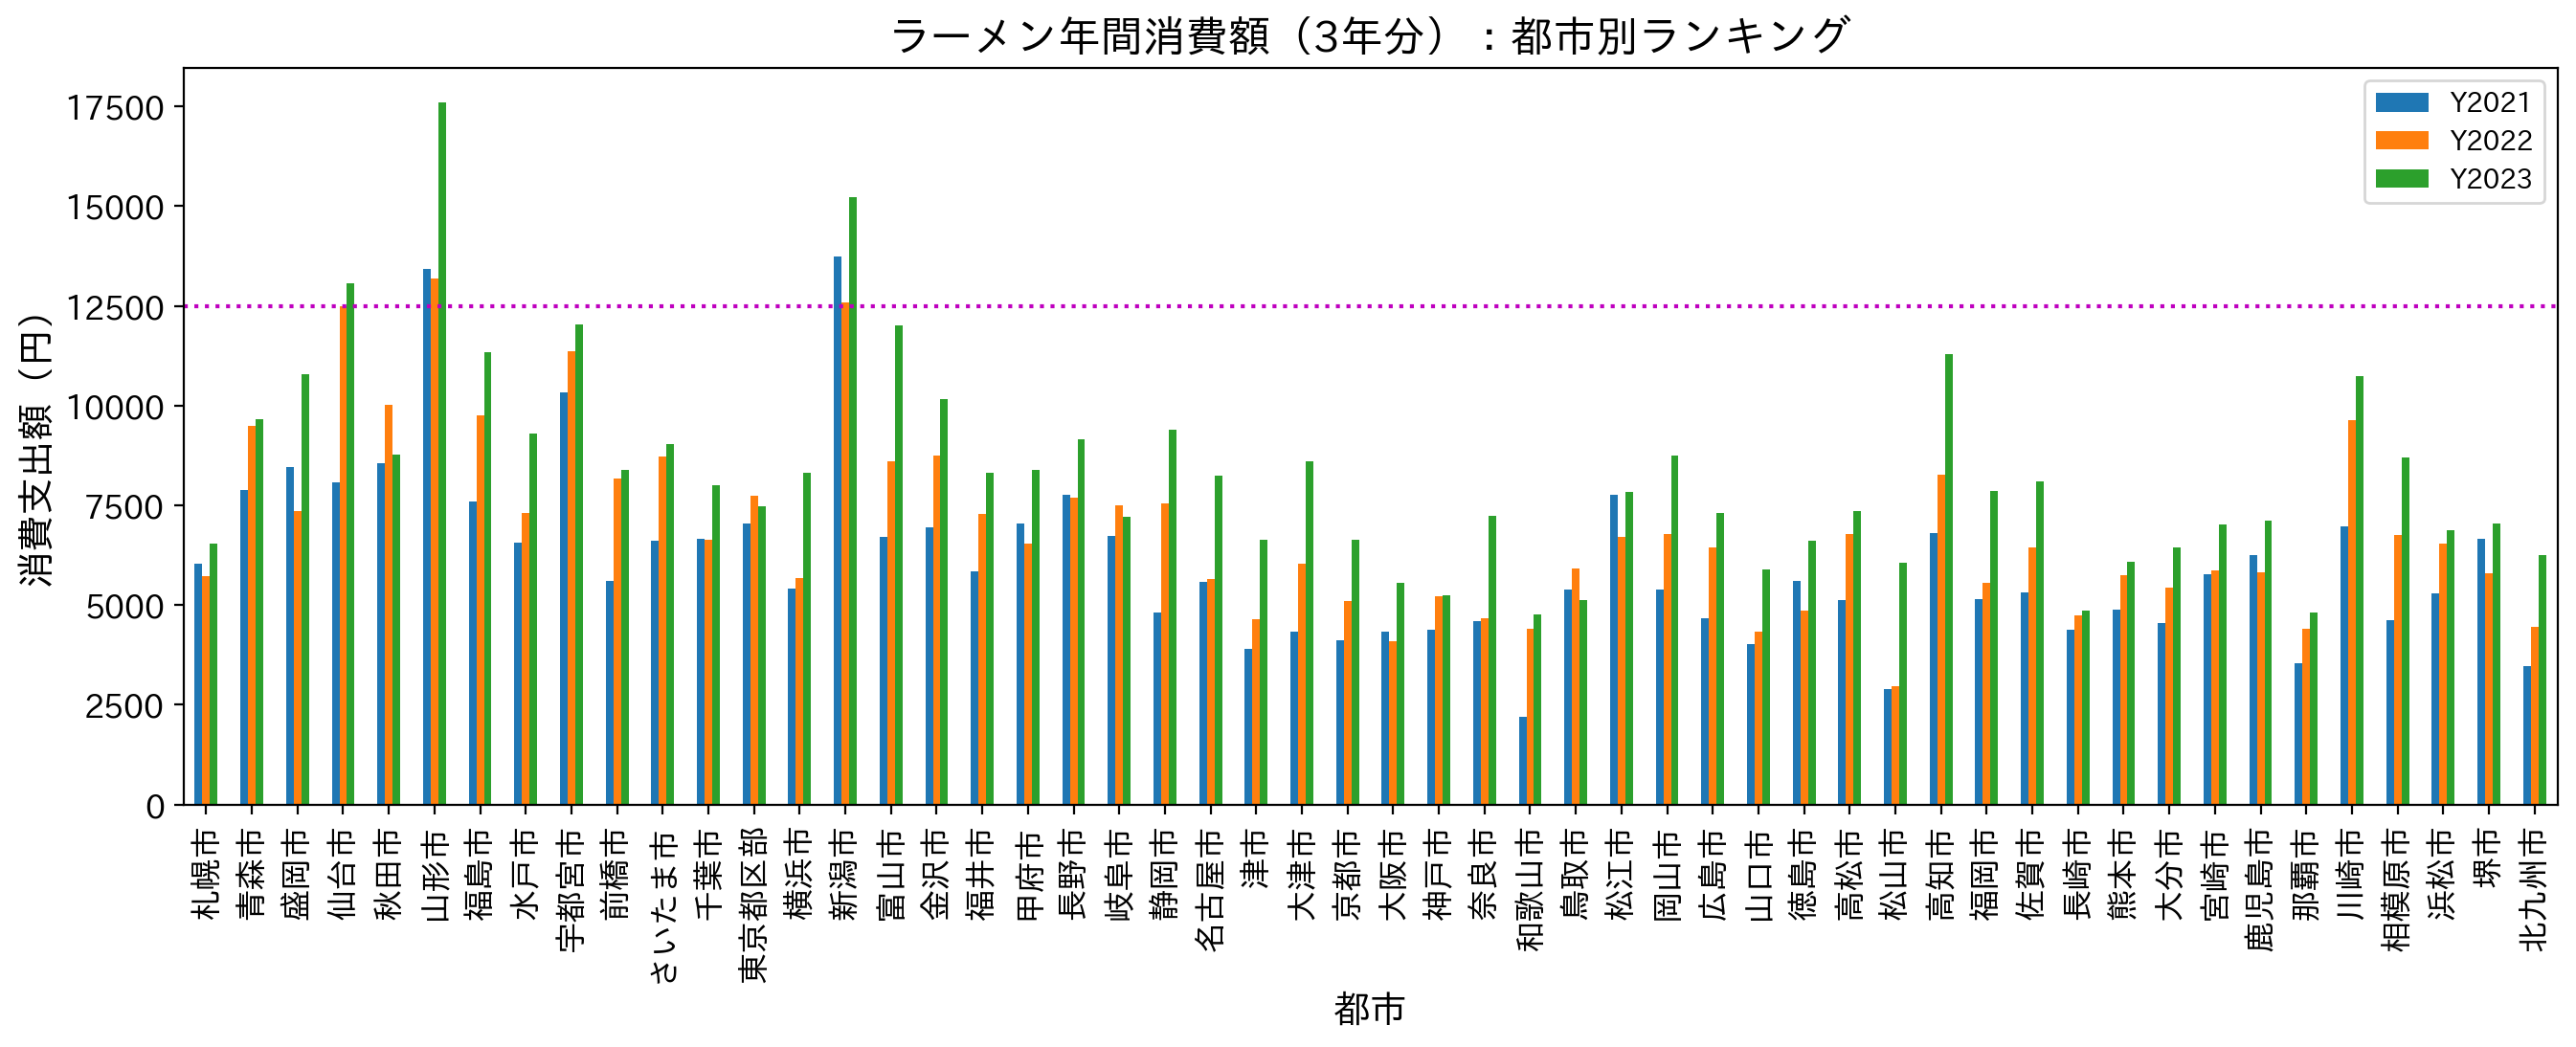

In [41]:
# 複数列を並べた棒グラフの描画（pandas の dataframe が持つ機能を用いるのが便利）
df_ramen.plot.bar(x="city", figsize=(16,5),fontsize=12)
plt.title("ラーメン年間消費額（3年分）：都市別ランキング", fontsize=16)
plt.xlabel("都市", fontsize=14)
plt.ylabel("消費支出額（円）", fontsize=14)
# 水平補助線
plt.axhline(y=12500, c='m', ls=':');

### 積層ヒストグラムの描画

In [42]:
# 積層ヒストグラム
china = [20,35,39,36,27]
usa = [25,32,34,20,25]

# 仮の x 軸設定
x = range(len(china))  # データ数だけ 0 からの番号のリストを用意
list(x)

[0, 1, 2, 3, 4]

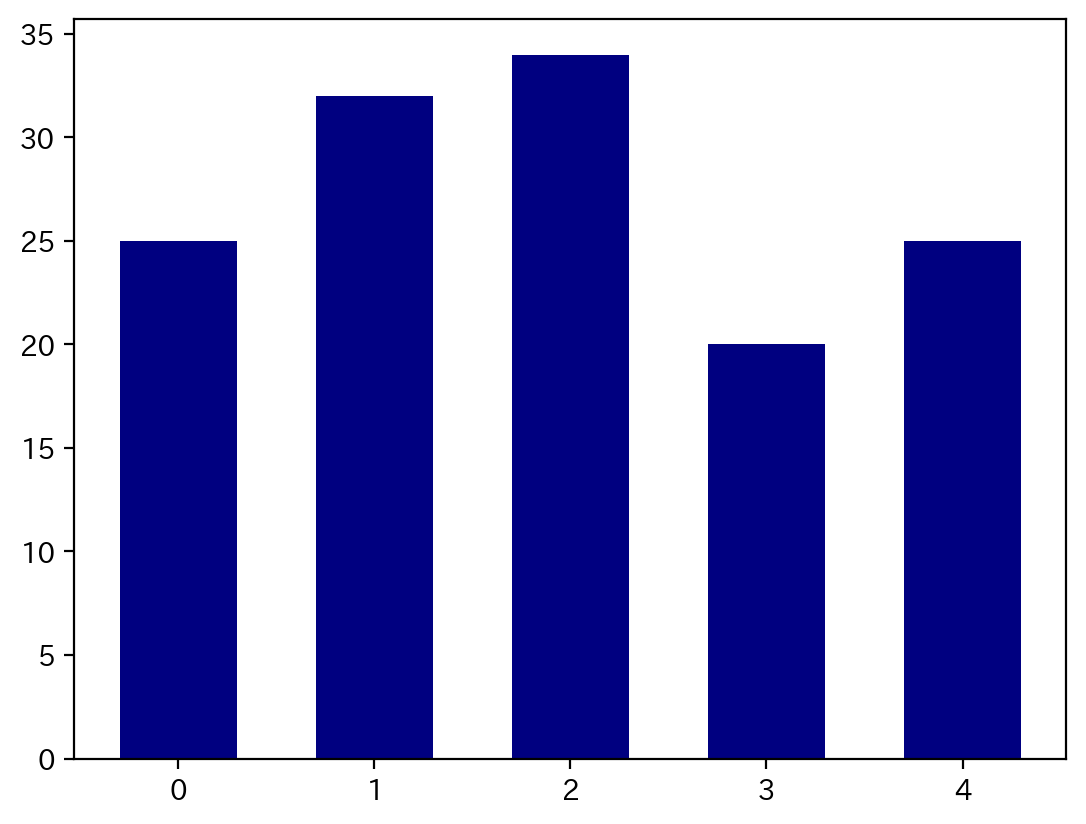

In [43]:
plt.bar(x, usa, width=0.6, color='navy');

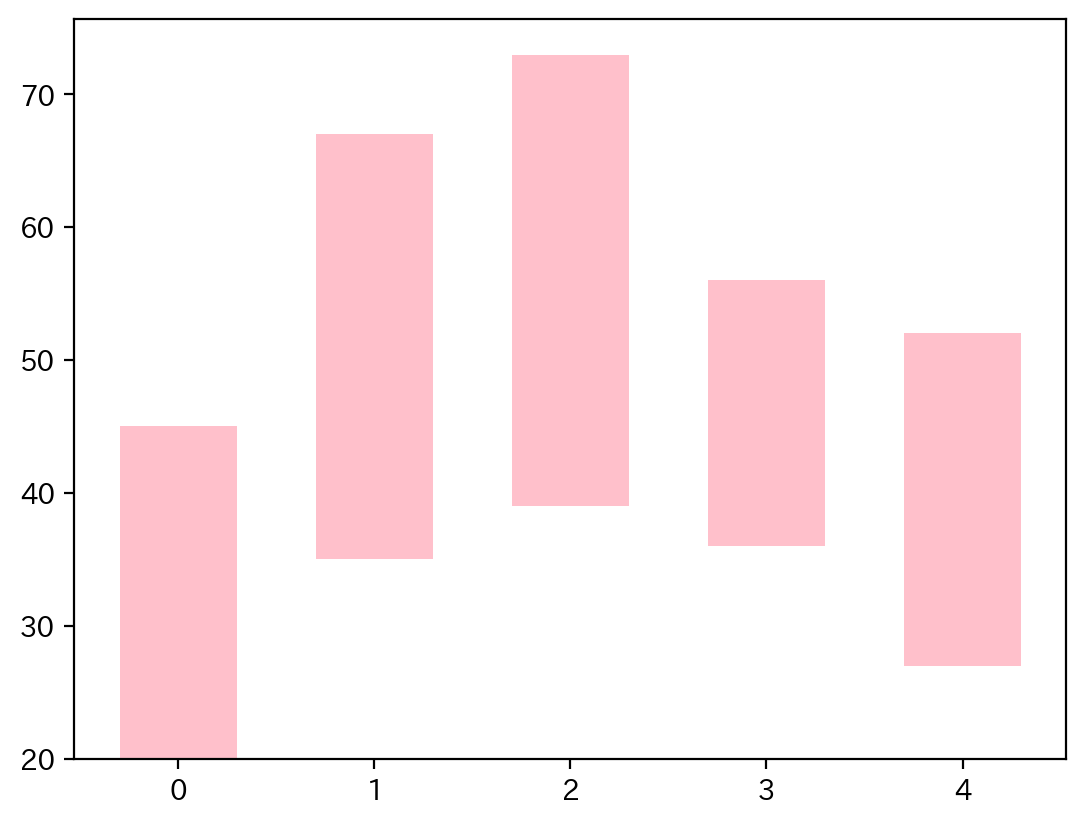

In [44]:
# bottom を指定して積み上げ用にシフト（確認用のコード）
plt.bar(x, usa, width=0.6, color='pink', bottom = china);

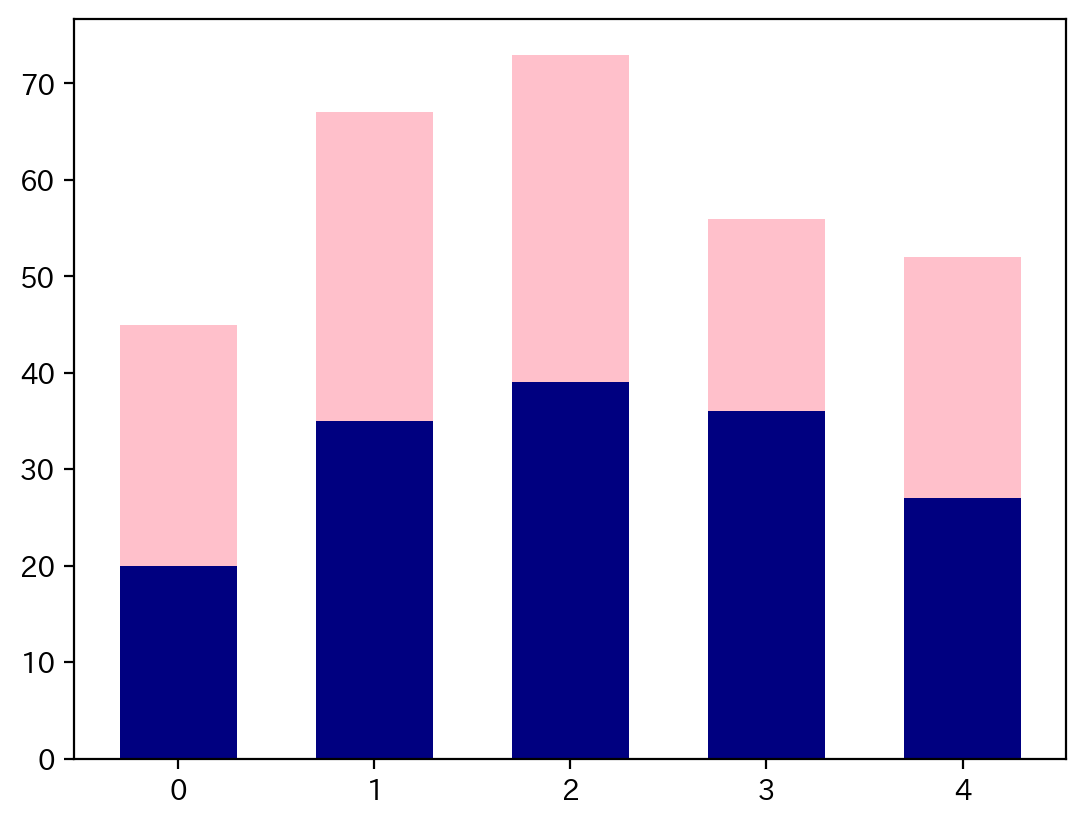

In [45]:
# まずchinaを描いた後、その分シフトさせて usa を描画
plt.bar(x, china, width=0.6, color='navy')
plt.bar(x, usa, width=0.6, color='pink', bottom = china);

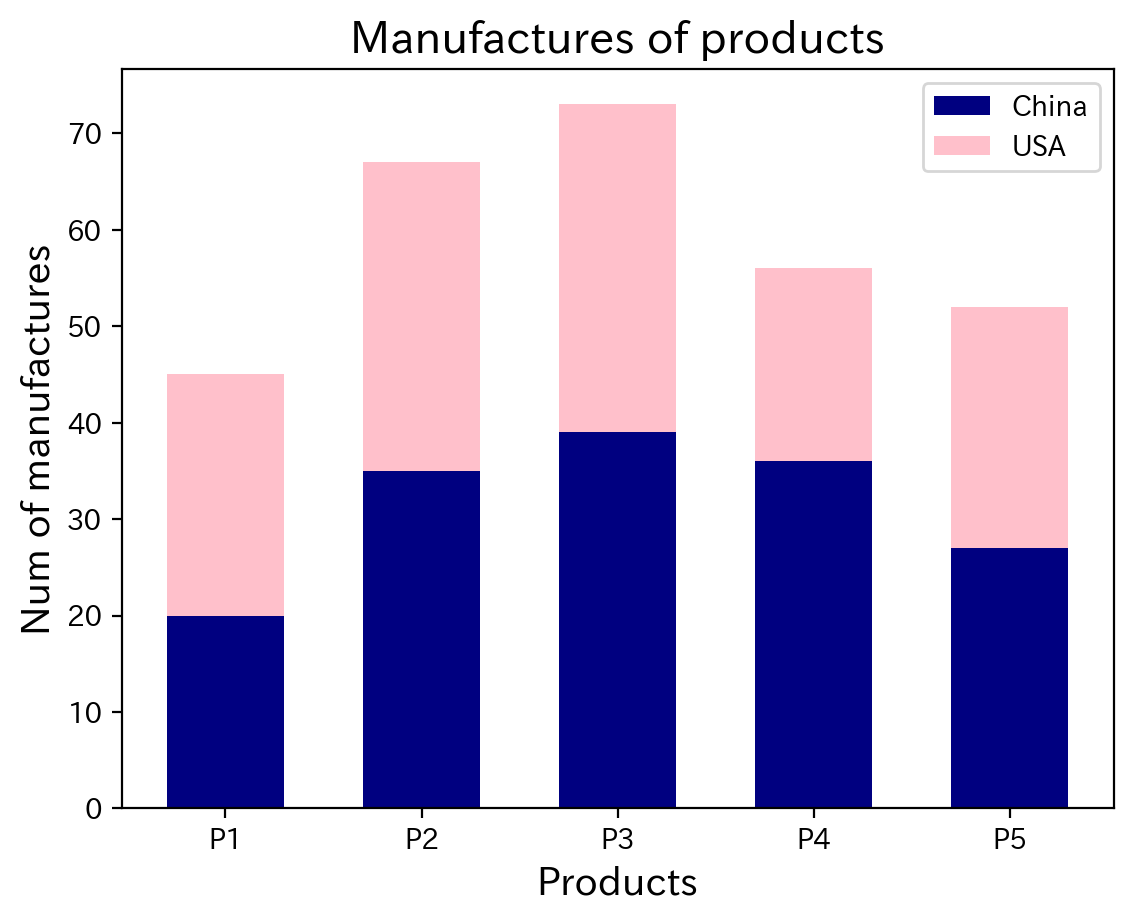

In [46]:
# 必要な情報やデザインを追記
plt.title('Manufactures of products',fontsize=16)
plt.xlabel('Products',fontsize=14)
plt.ylabel('Num of manufactures',fontsize=14)
plt.bar(x, china, width=0.6, color='navy', label='China')
plt.bar(x, usa, width=0.6, color='pink', bottom = china, label='USA')

# x軸のindexを置換(x=[0, 1, 2, 3, 4] を ['P1', 'P2', 'P3','P4', 'P5' ] に置き換え)
plt.xticks(x, ['P1', 'P2', 'P3','P4', 'P5' ]);
plt.legend();

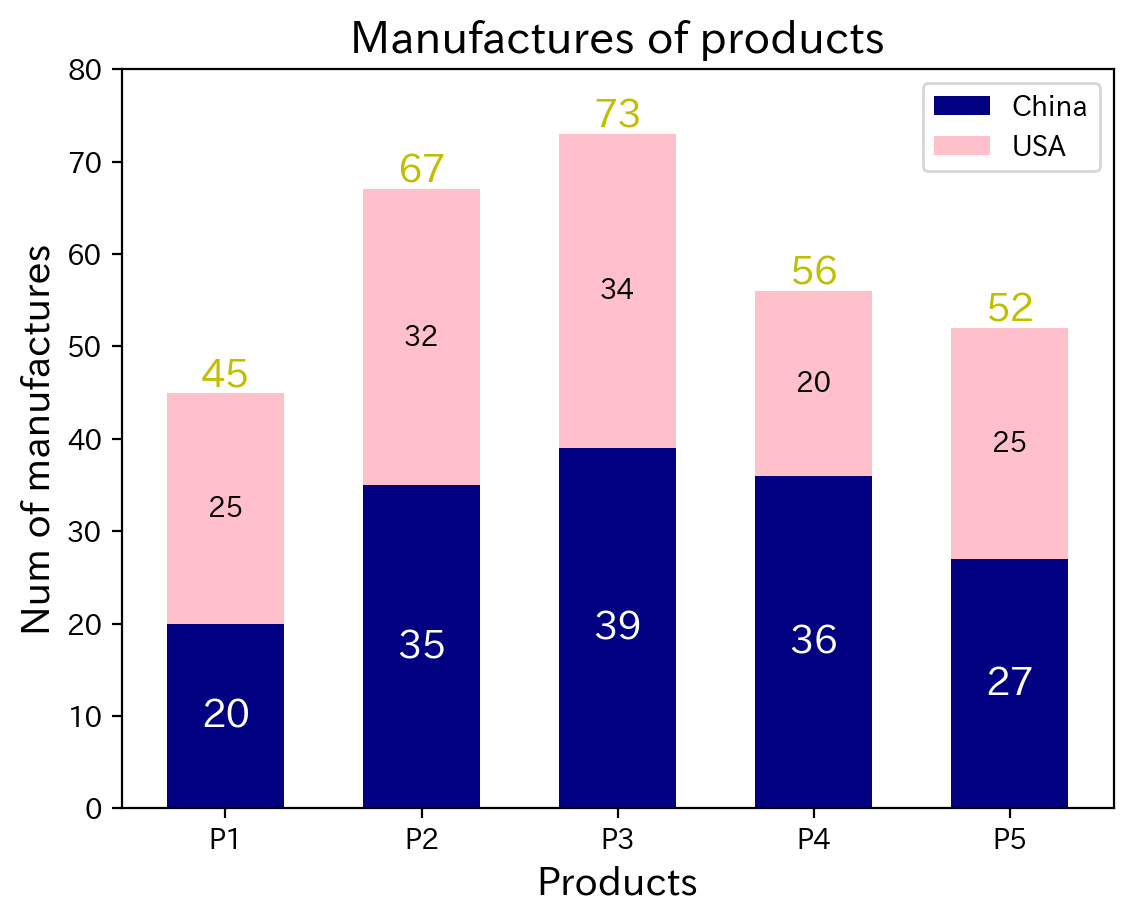

In [47]:
# データの数値情報を表示
plt.title('Manufactures of products',fontsize=16)
plt.xlabel('Products',fontsize=14)
plt.ylabel('Num of manufactures',fontsize=14)
p1 = plt.bar(x, china, width=0.6, color='navy', label='China')
p2 = plt.bar(x, usa, width=0.6, color='pink', bottom = china, label='USA')

# x軸のindexを置換
plt.xticks(x, ['P1', 'P2', 'P3','P4', 'P5' ]);
plt.legend()

# 数値表示
plt.bar_label(p1, label_type='center', color='white', fontsize=14)
plt.bar_label(p2, label_type='center')

# 積み上げ棒グラフのbar_labelのlabel_typeを’edge’にすると合計値を表示
plt.bar_label(p2, label_type='edge', color="y", fontsize=14)

plt.ylim(0,80);

### 別の種別のグラフの同時描画

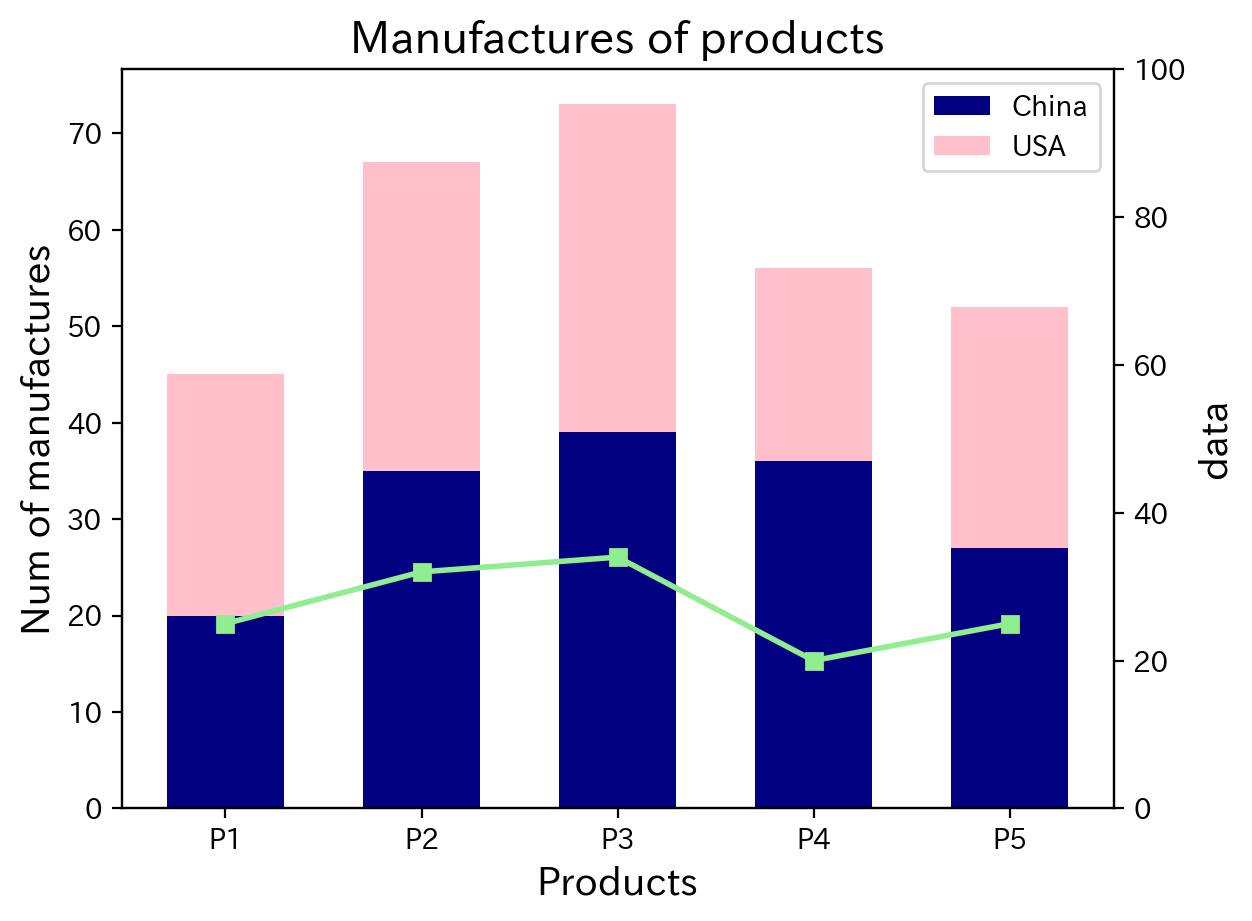

In [48]:
# 基本グラフ（左軸）
# 必要な情報やデザインを追記
x = [0, 1, 2, 3, 4]
plt.title('Manufactures of products',fontsize=16)
plt.xlabel('Products',fontsize=14)
plt.ylabel('Num of manufactures',fontsize=14)
plt.bar(x, china, width=0.6, color='navy', label='China')
plt.bar(x, usa, width=0.6, color='pink', bottom = china, label='USA')

# x軸のindexを置換(x=[0, 1, 2, 3, 4] を ['P1', 'P2', 'P3','P4', 'P5' ] に置き換え)
plt.xticks(x, ['P1', 'P2', 'P3','P4', 'P5' ])
plt.legend()

# 2軸グラフ（右軸の付加）
plt.twinx()
plt.ylim(0,100)
plt.ylabel("data", fontsize=14)
plt.plot(usa, marker="s", c="lightgreen", lw=2);

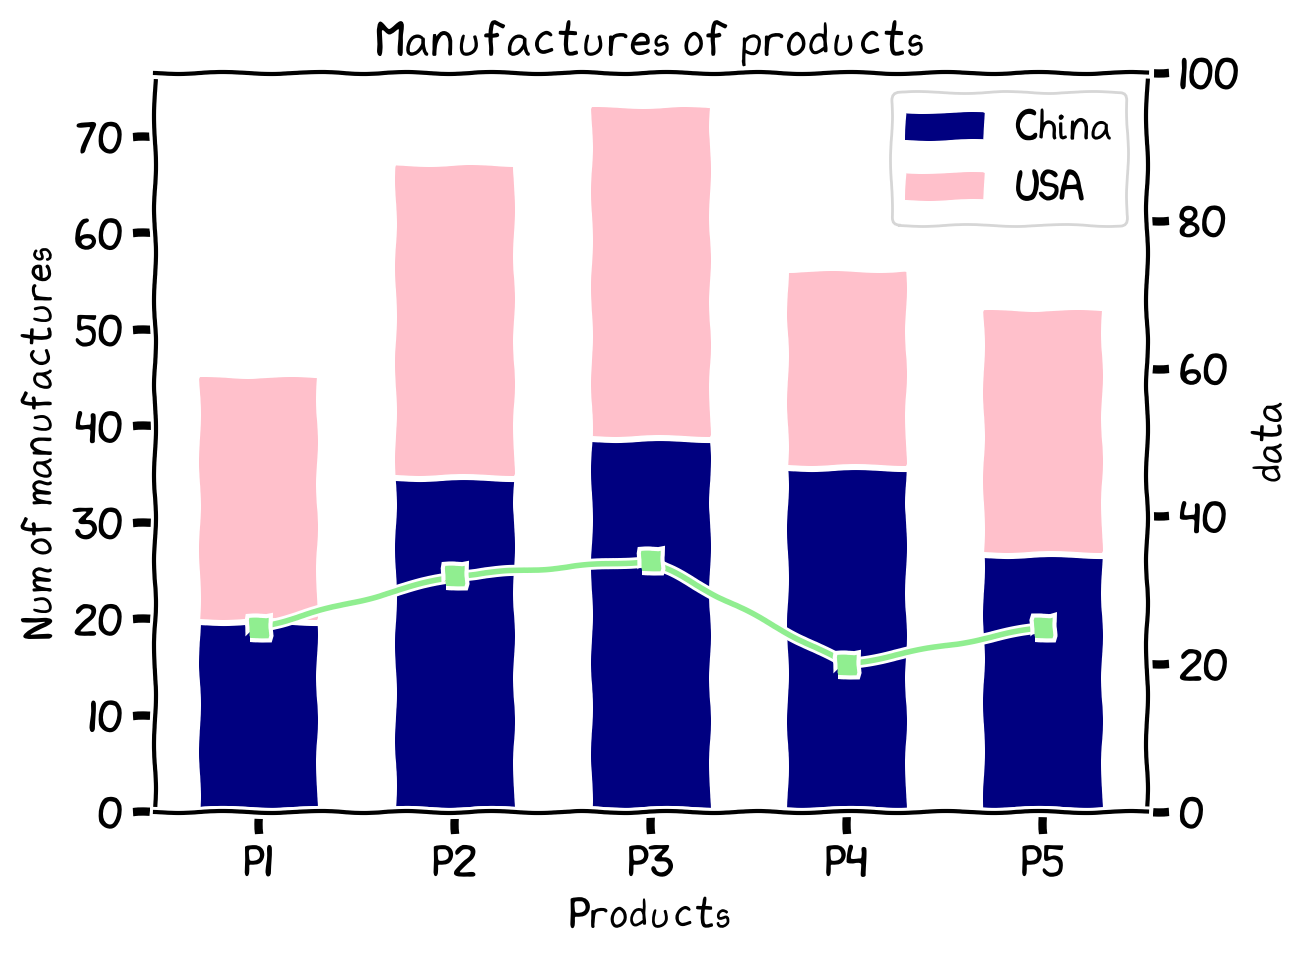

In [49]:
with plt.xkcd():
    # 基本グラフ（左軸）
    # 必要な情報やデザインを追記
    x=[0, 1, 2, 3, 4]
    plt.title('Manufactures of products',fontsize=16)
    plt.xlabel('Products',fontsize=14)
    plt.ylabel('Num of manufactures',fontsize=14)
    plt.bar(x, china, width=0.6, color='navy', label='China')
    plt.bar(x, usa, width=0.6, color='pink', bottom = china, label='USA')

    # x軸のindexを置換(x=[0, 1, 2, 3, 4] を ['P1', 'P2', 'P3','P4', 'P5' ] に置き換え)
    plt.xticks(x, ['P1', 'P2', 'P3','P4', 'P5' ])
    plt.legend()

    # 2軸グラフ（右軸の付加）
    plt.twinx()
    plt.ylim(0,100)
    plt.ylabel("data", fontsize=14)
    plt.plot(usa, marker="s", c="lightgreen", lw=2);

In [50]:
# シート名を指定し、ここでは df (dataframe) という名前で読み込み
df = pd.read_excel(datafile, sheet_name = "降水量")
# df = pd.read_excel("https://www.ces-alpha.org/course/file_serve/5860835511500800/dsa2024data.xlsx", sheet_name = "data")
df

,月,降水量,気温
0,1,180.0,4.3
1,2,114.5,4.8
2,3,168.0,6.0
3,4,54.0,13.7
4,5,128.0,17.1
5,6,57.0,22.2
6,7,376.5,26.2
7,8,42.0,28.0
8,9,292.0,25.0
9,10,144.5,18.7


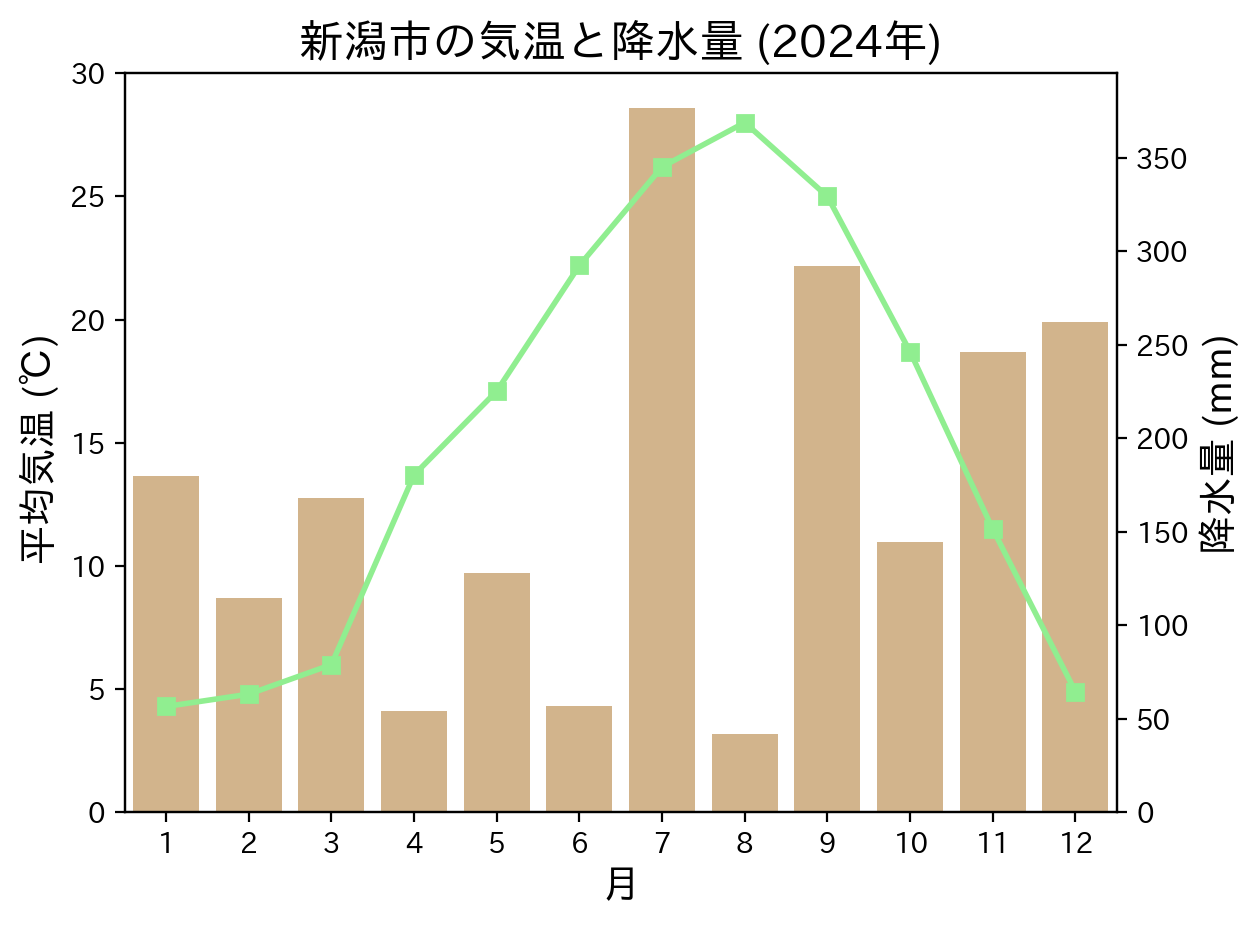

In [51]:
# 基本グラフ（左軸）
# 必要な情報やデザインを追記

month = df['月']
rain = df['降水量']
temp = df['気温']

plt.title('新潟市の気温と降水量 (2024年)', fontsize=16)
plt.xlabel('月',fontsize=14)
plt.ylabel("平均気温 (℃) ", fontsize=14)

plt.gca().patch.set_alpha(0)  # 上層を透明化して下層も見えるように
plt.gca().set_zorder(2)       # 上層設定

plt.plot(month, temp, marker="s", c="lightgreen", lw=2)

plt.xticks(month, range(1,13))
plt.xlim(0.5, 12.5)
plt.ylim(0,30)

# グラフ領域の色指定
plt.gca().set_facecolor('#eafff5')

# 2軸グラフ（右軸の付加）
plt.twinx()
plt.ylabel('降水量 (mm)',fontsize=14)

plt.gca().set_zorder(1)      # 下層設定（通常はtwinx側が上層になる）
plt.bar(month, rain, width=0.8, color='tan')

plt.show()

### 4. 箱ひげ図の作成
【参照】https://matplotlib.org/2.0.2/examples/pylab_examples/boxplot_demo.html

In [52]:
# excelファイルの直接読み込み（シート名指定）
df_exam = pd.read_excel('dsa2024data.xlsx',  sheet_name = "exam")
df_exam.head()

,name,国語,数学,理科,社会,英語
0,伊藤 涼介,94,76,62,81,62
1,上田 美咲,63,57,59,80,74
2,木村 太郎,55,66,82,78,66
3,佐藤 亜美,61,87,80,65,78
4,鈴木 恵美子,56,58,69,97,61


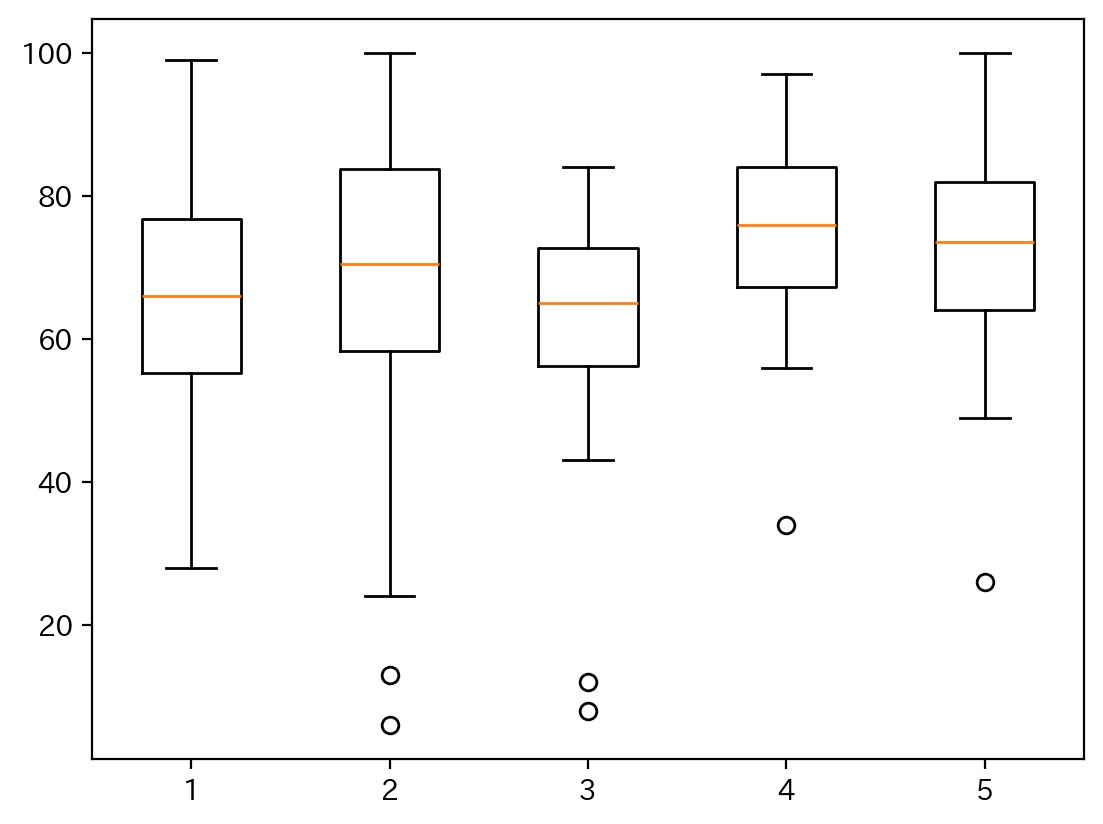

In [53]:
# 点数のリスト
subjects = [df_exam['国語'],df_exam['数学'], df_exam['理科'], df_exam['社会'], df_exam['英語']]

# 箱ひげ図
plt.boxplot(subjects);

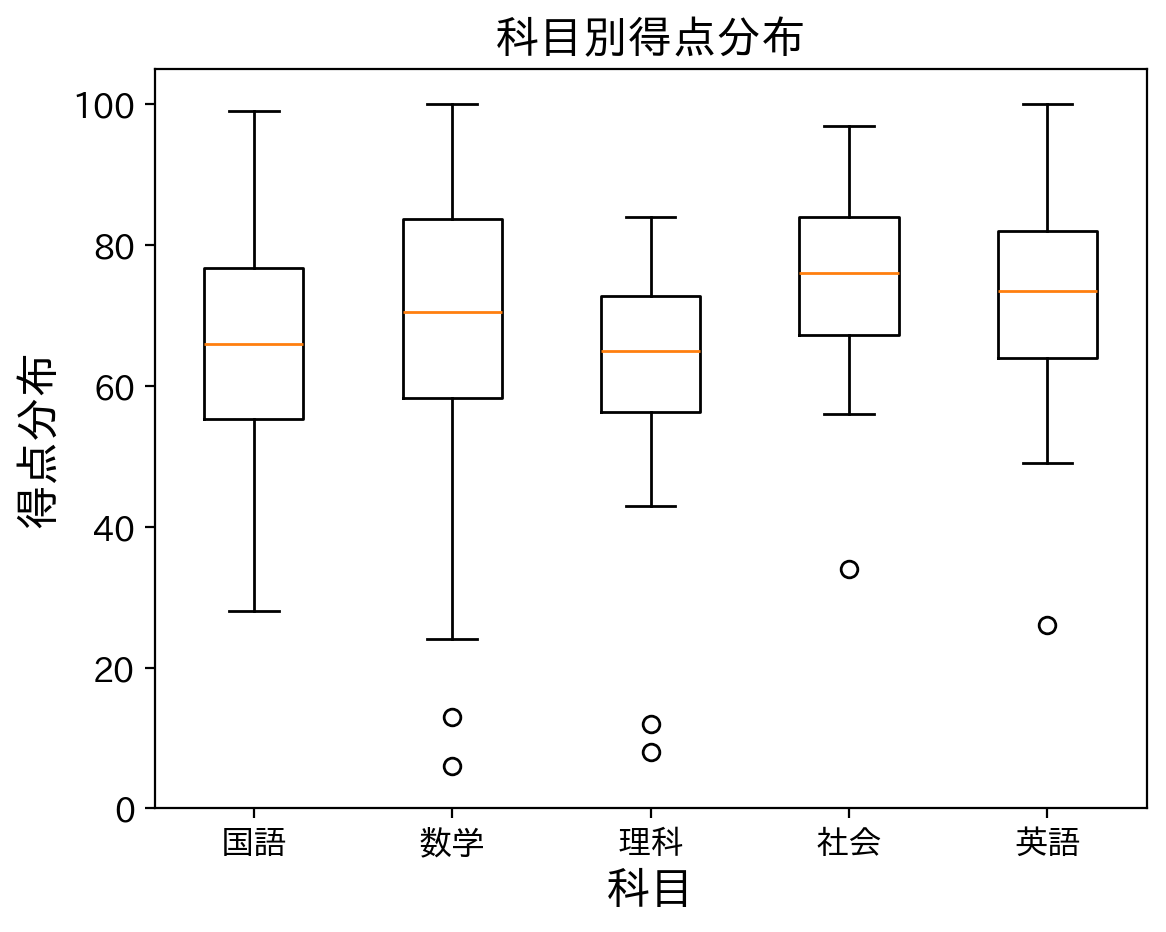

In [54]:
# 箱ひげ図
plt.boxplot(subjects)
plt.title('科目別得点分布', fontsize=16)
plt.xlabel('科目', fontsize=16)
plt.ylabel('得点分布', fontsize=16)

# y軸範囲指定
plt.ylim([0,105])

# グリッド指定
plt.grid(False)

# x軸目盛（番号 [1,2,3,4,5] ）を科目名に置換
plt.xticks([1,2,3,4,5], ['国語', '数学', '理科', '社会', '英語'], fontsize=12)

# y軸目盛はフォントサイズ指定のみ
plt.yticks(fontsize=12);

### 箱ひげ図のカスタマイズ
箱ひげ図（詳細設定）  
Artist customization in box plots  
https://matplotlib.org/stable/gallery/statistics/boxplot.html

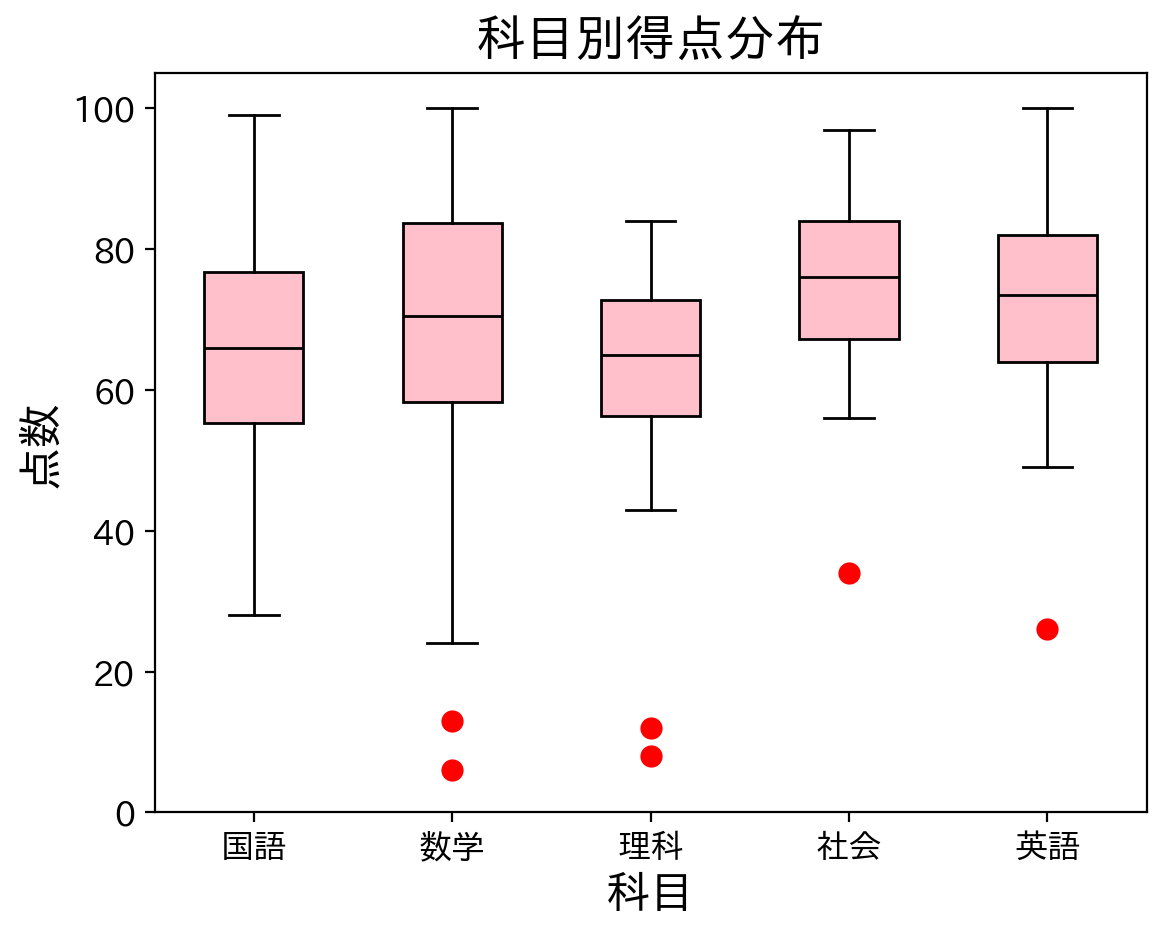

In [55]:
# 点数のリスト
subjects = [df_exam['国語'],df_exam['数学'], df_exam['理科'], df_exam['社会'], df_exam['英語']]

plt.title('科目別得点分布', fontsize=18)
plt.xlabel('科目', fontsize=16)
plt.ylabel('点数', fontsize=16)

# 外れ値用マーカー設定
flierprops = dict(marker="o", markerfacecolor='red', markersize=8, markeredgecolor='none')

# 箱ひげの胴体設定
plt.gca().boxplot(subjects,
                  patch_artist=True,
                  flierprops = flierprops,
                  boxprops={'facecolor': 'pink'}, 
                  medianprops={'color': 'k', 'linewidth':1}
                 )

# x軸目盛の置換・y軸目盛のフォントサイズ指定
plt.xticks([1,2,3,4,5], ['国語', '数学', '理科', '社会', '英語'], fontsize=12)
plt.yticks(fontsize=12)

# y軸範囲指定
plt.ylim(0,105);

### 5. 円グラフの作成
https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pie.html

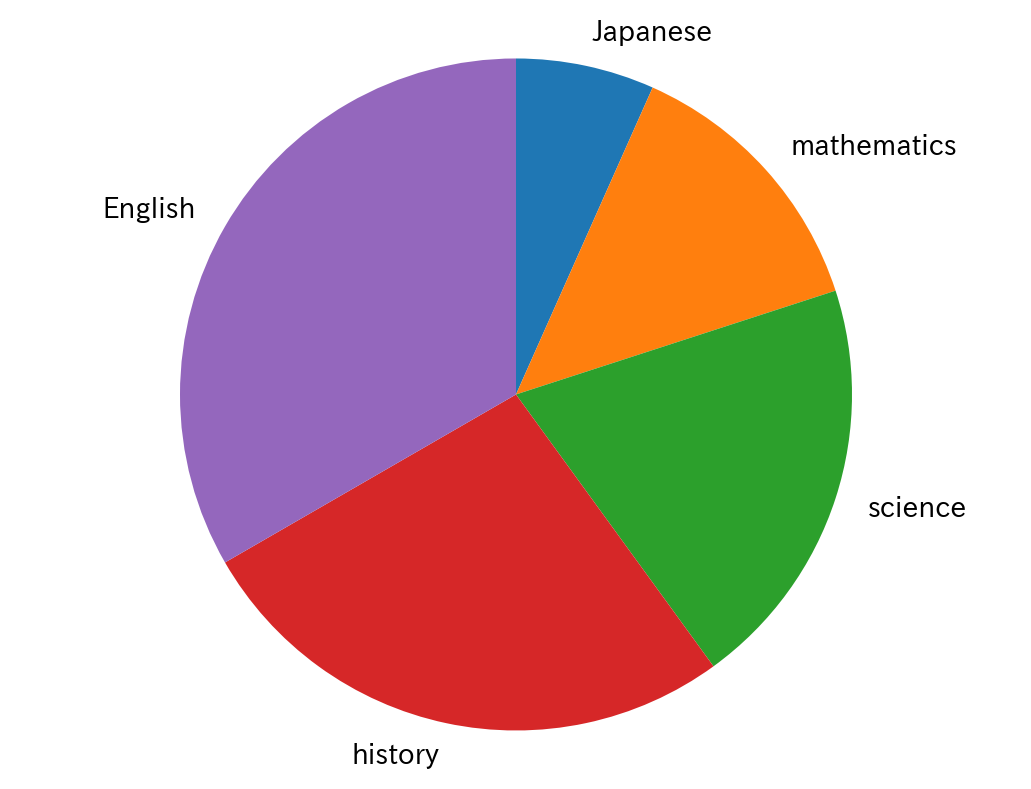

In [56]:
label = ['Japanese', 'mathematics', 'science', 'history', 'English']

# data（今はベタ打ちで与える）
x = [100, 200, 300, 400, 500]
plt.pie(x, labels=label, counterclock=False, startangle=90)

# 最後の以下を追加する(歪みのない円グラフ)
plt.axis('equal');

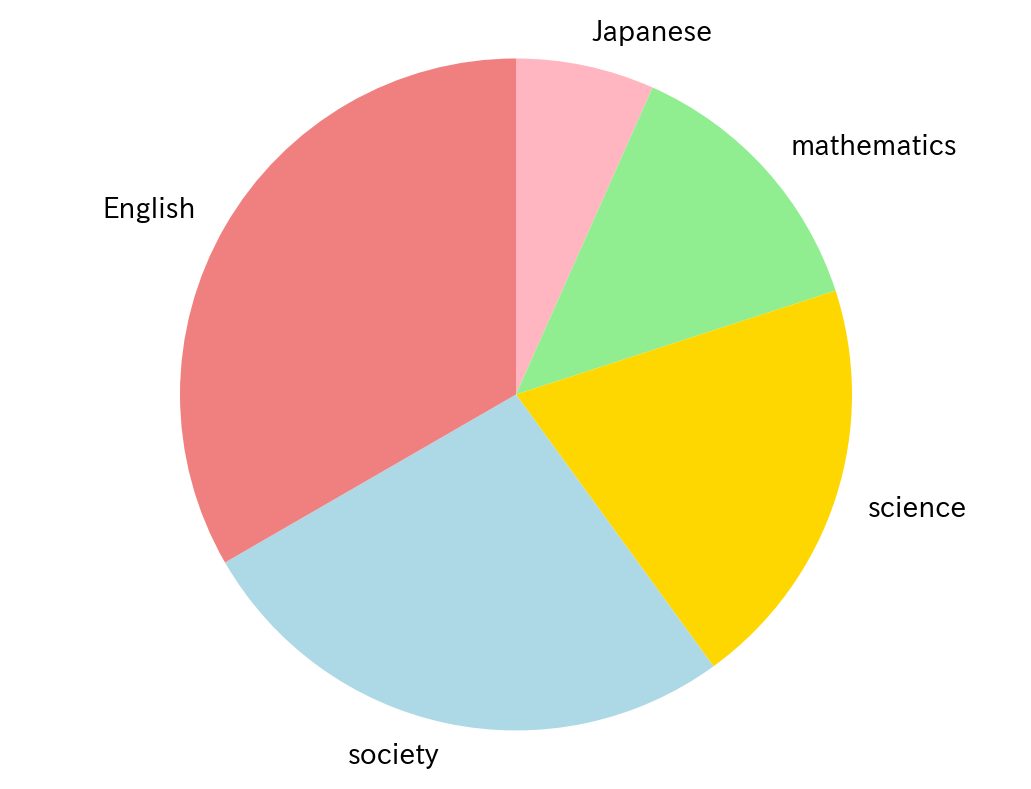

In [57]:
pie_colors = ["lightpink", "lightgreen", "gold", "lightblue", "lightcoral"]
x = [100, 200, 300, 400, 500]

label = ['Japanese', 'mathematics', 'science', 'society', 'English']
plt.pie(x, labels=label, counterclock=False, startangle=90, colors=pie_colors)
plt.axis('equal');

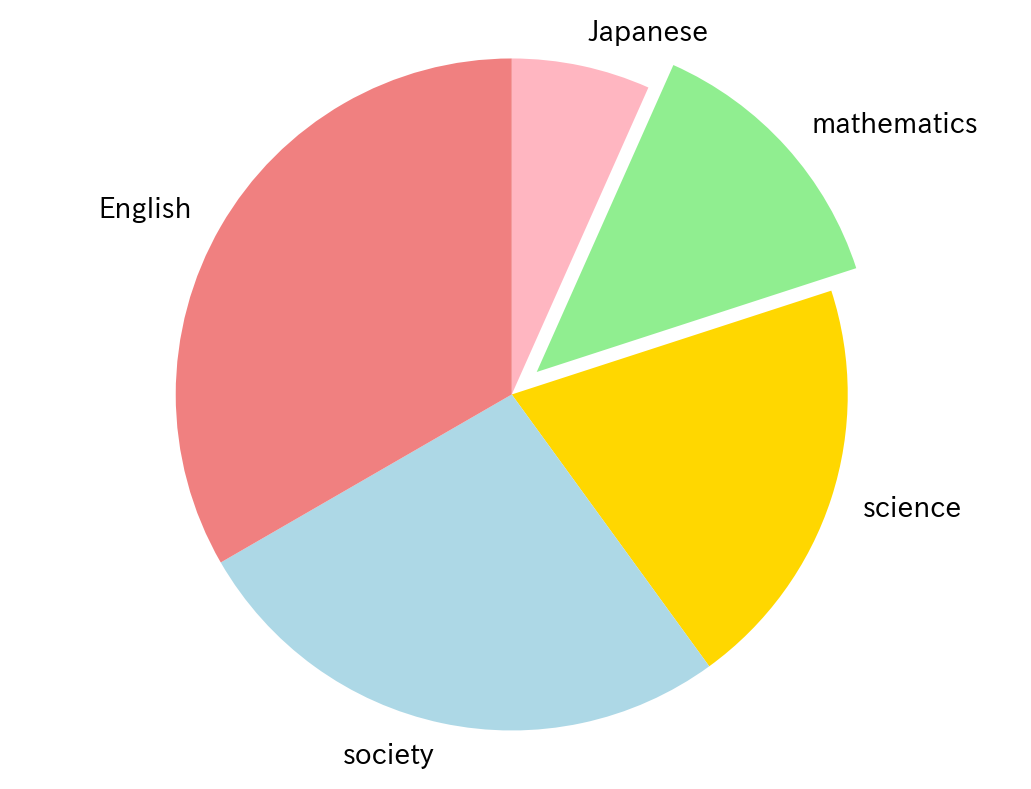

In [58]:
# explode で飛び出し量を指定
plt.pie(x, labels=label, counterclock=False, startangle=90, 
        colors=pie_colors, explode=[0, 0.1, 0, 0, 0])
plt.axis('equal');

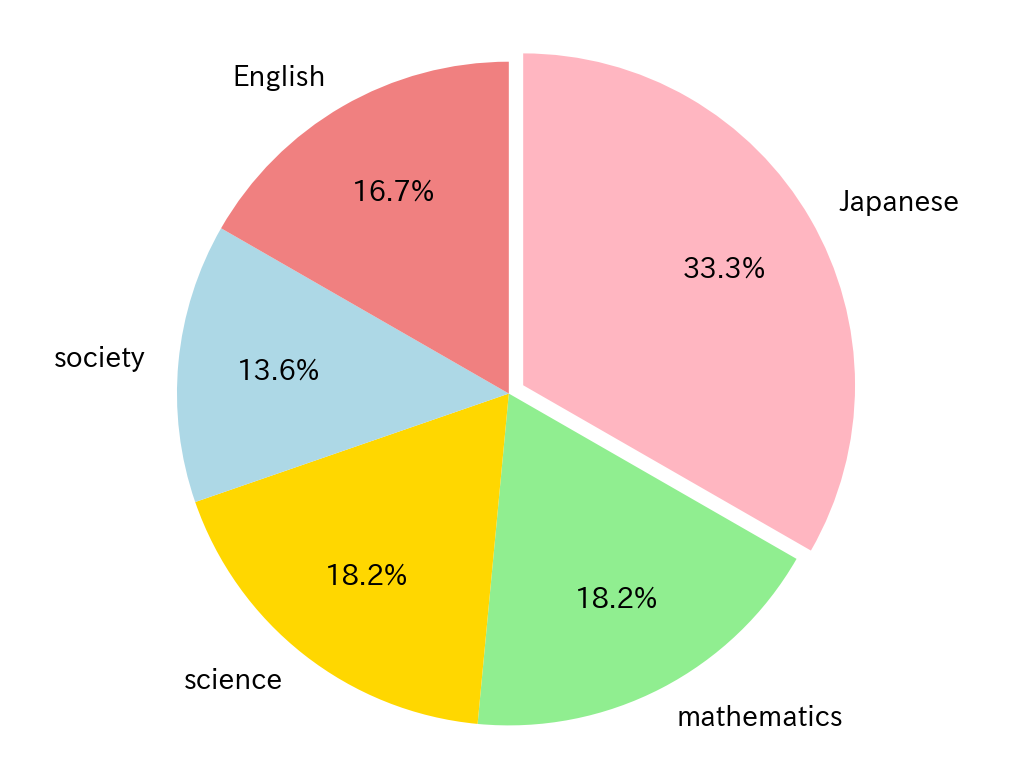

In [59]:
colors = ["lightcoral","lightpink", "gold", "lightgreen", "lightblue"]
x = [33.3, 18.2,18.2,13.6,16.7]
label = ['Japanese', 'mathematics', 'science', 'society', 'English']

# 比の表示（autopct で表示形式設定可）
plt.pie(x, labels=label, counterclock=False, startangle=90, colors=pie_colors,
        pctdistance=0.7, autopct="%1.1f%%", explode=[0.05, 0.0, 0, 0,0])
plt.axis('equal');

### 6. 時系列データの描画
Pythonでは、日付と時間を扱うためのデータ型 `Datetime` が用意されており、これを用いて時系列データを
扱います。  
Data Source　[Historical data: Dow Jones Industrial - U.S. (DJI)](https://stooq.com/q/d/?s=^dji&i=w&l=160)

In [60]:
# excelファイルの直接読み込み（シート名指定）
df_dji = pd.read_excel(datafile,  sheet_name = "dji")
df_dji.head()

,Date,Open,High,Low,Close,Volume
0,1896-05-31,29.39,29.43,29.11,29.43,0.0
1,1896-06-07,29.40,29.40,28.80,29.20,0.0
2,1896-06-14,28.83,28.83,27.82,28.47,0.0
3,1896-06-21,28.92,29.36,28.80,28.99,0.0
4,1896-06-28,28.05,28.05,27.44,27.44,0.0


In [61]:
# データ型の境界を確認(1900年を挟むデータを扱う場合の注意)
df_dji[184:194]

,Date,Open,High,Low,Close,Volume
184,1899-12-10,53.78,53.78,50.89,50.89,0.0
185,1899-12-17,48.84,48.92,46.37,47.95,0.0
186,1899-12-24,42.20,44.32,42.20,42.51,0.0
187,1899-12-31,44.90,47.60,44.90,47.60,0.0
188,1900-01-07 00:00:00,49.34,49.34,48.24,48.31,0.0
189,1900-01-14 00:00:00,48.10,48.10,45.82,47.03,0.0
190,1900-01-21 00:00:00,46.51,47.29,46.51,47.29,0.0
191,1900-01-28 00:00:00,47.34,47.34,46.52,46.52,0.0
192,1900-02-04 00:00:00,46.68,49.15,46.68,49.15,0.0
193,1900-02-11 00:00:00,49.51,49.51,48.42,48.42,0.0


In [62]:
# df_dji のデータ形式を確認
df_dji.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6729 entries, 0 to 6728
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    6729 non-null   object 
 1   Open    6729 non-null   float64
 2   High    6729 non-null   float64
 3   Low     6729 non-null   float64
 4   Close   6729 non-null   float64
 5   Volume  6729 non-null   float64
dtypes: float64(5), object(1)
memory usage: 315.5+ KB


In [63]:
# 1900年より古いデータを含む場合は明示的にdatetime型に要変換
df_dji["Date"] = pd.to_datetime(df_dji["Date"])
df_dji

,Date,Open,High,Low,Close,Volume
0,1896-05-31,29.39,29.43,29.11,29.43,0.000000e+00
1,1896-06-07,29.40,29.40,28.80,29.20,0.000000e+00
2,1896-06-14,28.83,28.83,27.82,28.47,0.000000e+00
3,1896-06-21,28.92,29.36,28.80,28.99,0.000000e+00
4,1896-06-28,28.05,28.05,27.44,27.44,0.000000e+00
...,...,...,...,...,...,...
6724,2025-08-31,45605.25,45682.83,45192.29,45544.88,2.157686e+09
6725,2025-09-07,45287.73,45760.50,44948.16,45400.86,1.274039e+09
6726,2025-09-14,45430.61,46137.20,45277.73,45834.22,1.625822e+09
6727,2025-09-21,45848.39,46388.56,45667.42,46315.27,2.344294e+09


In [64]:
# df_dji のデータ形式を再度確認
df_dji.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6729 entries, 0 to 6728
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    6729 non-null   datetime64[ns]
 1   Open    6729 non-null   float64       
 2   High    6729 non-null   float64       
 3   Low     6729 non-null   float64       
 4   Close   6729 non-null   float64       
 5   Volume  6729 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 315.5 KB


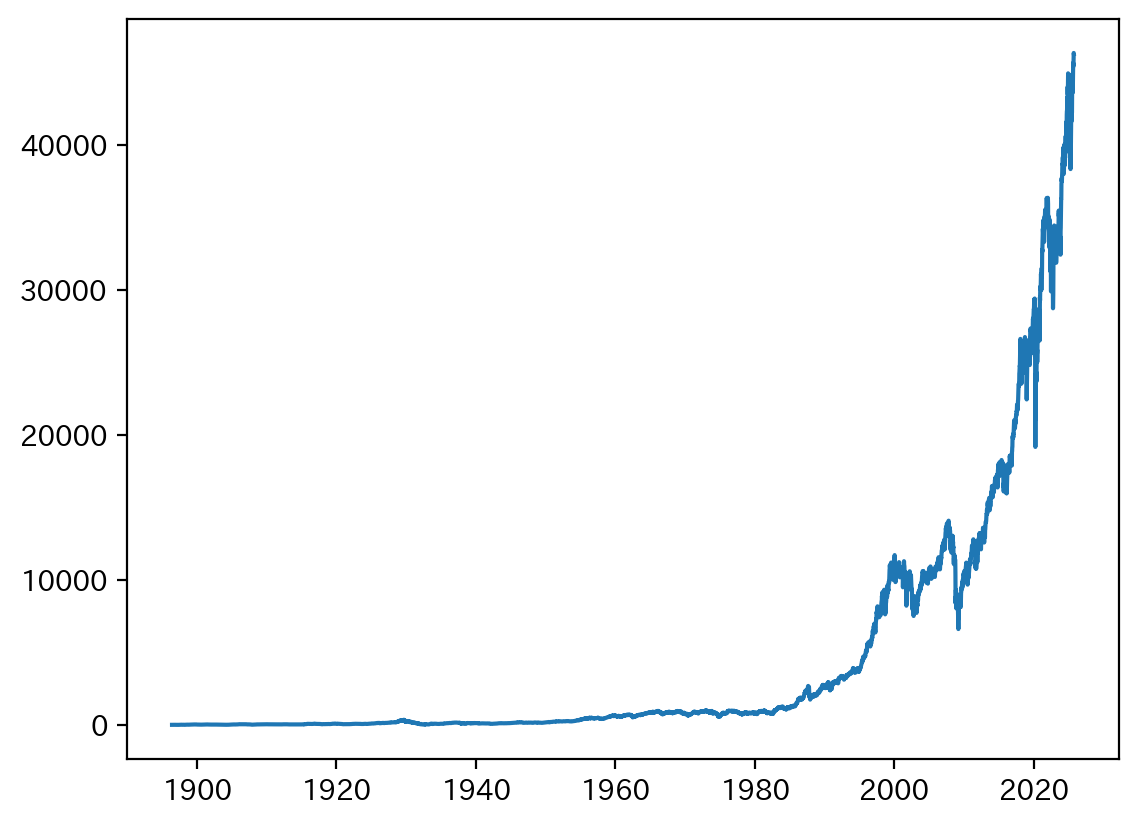

In [65]:
plt.plot(df_dji['Date'], df_dji['Close']);

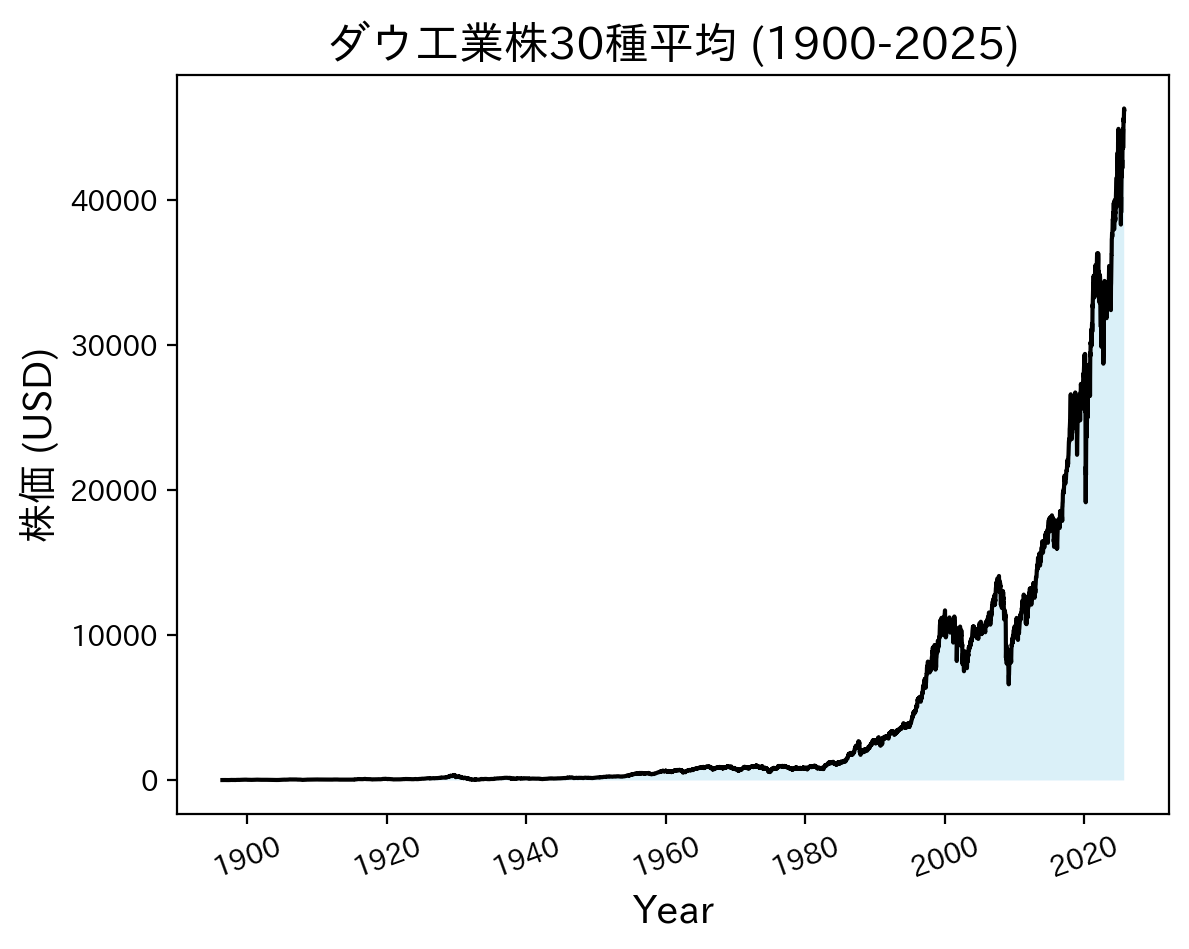

In [66]:
# グラフタイトル
plt.title('ダウ工業株30種平均 (1900-2025)', fontsize=16)

# グラフの軸名
plt.xlabel('Year', fontsize=14)
plt.ylabel('株価 (USD)', fontsize=14)

# グラフの塗りを指定
plt.plot(df_dji['Date'], df_dji['Close'], c="k", lw=1.5)
plt.fill_between(df_dji['Date'], df_dji['Close'], facecolor='skyblue', alpha=0.3, interpolate=True)

# 軸メモリの回転
plt.xticks(rotation=20);    # 回転角度指定

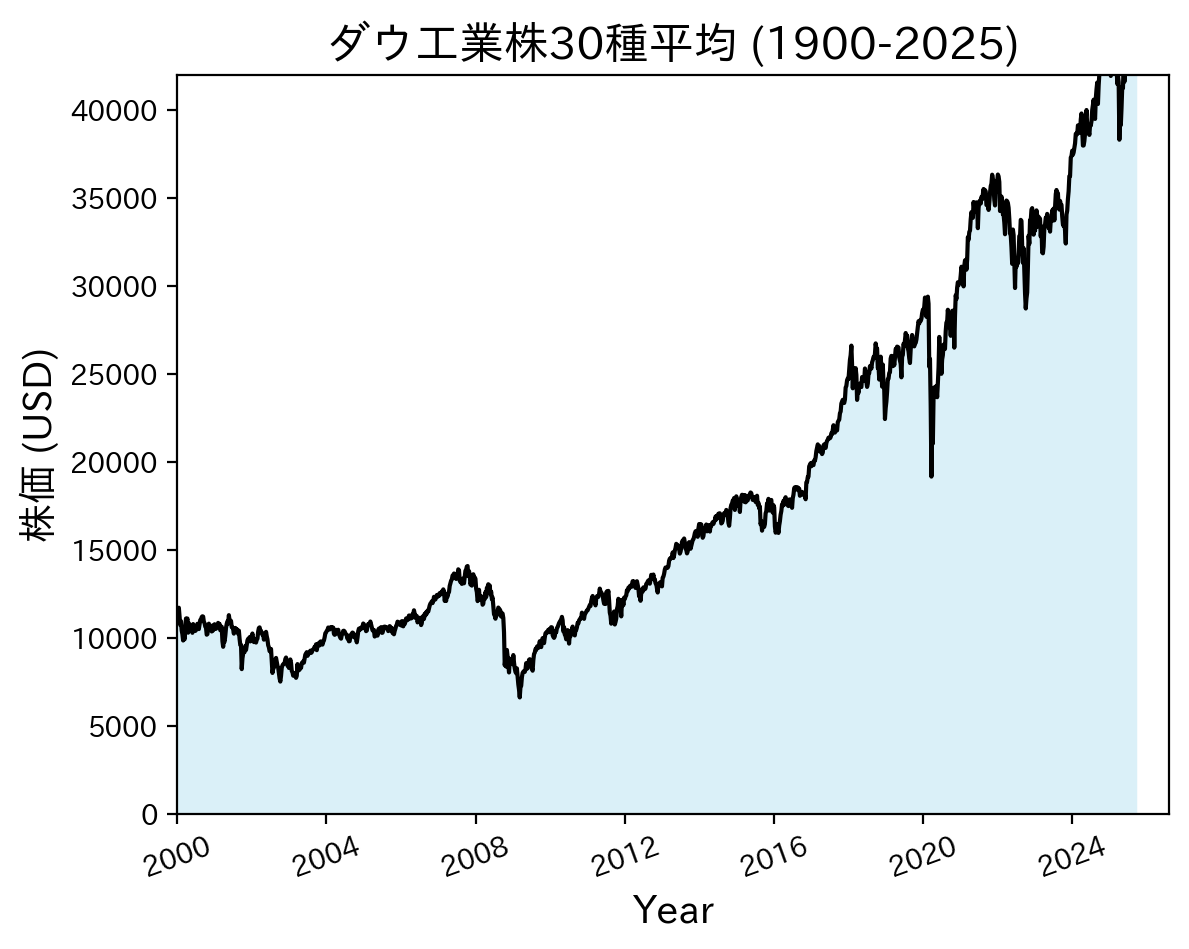

In [67]:
#datetime型
import datetime

# グラフタイトル
plt.title('ダウ工業株30種平均 (1900-2025)', fontsize=16)

# グラフの軸名
plt.xlabel('Year', fontsize=14)
plt.ylabel('株価 (USD)', fontsize=14)

# グラフの塗りを指定
plt.plot(df_dji['Date'], df_dji['Close'], c="k", lw=1.5)
plt.fill_between(df_dji['Date'], df_dji['Close'], facecolor='skyblue', alpha=0.3, interpolate=True)

# 軸メモリの回転
plt.xticks(rotation=20);    # 回転角度指定

# 時系列データの描画範囲指定
plt.xlim(datetime.date(2000, 1, 1), datetime.date.today())
plt.ylim(0, 42000);

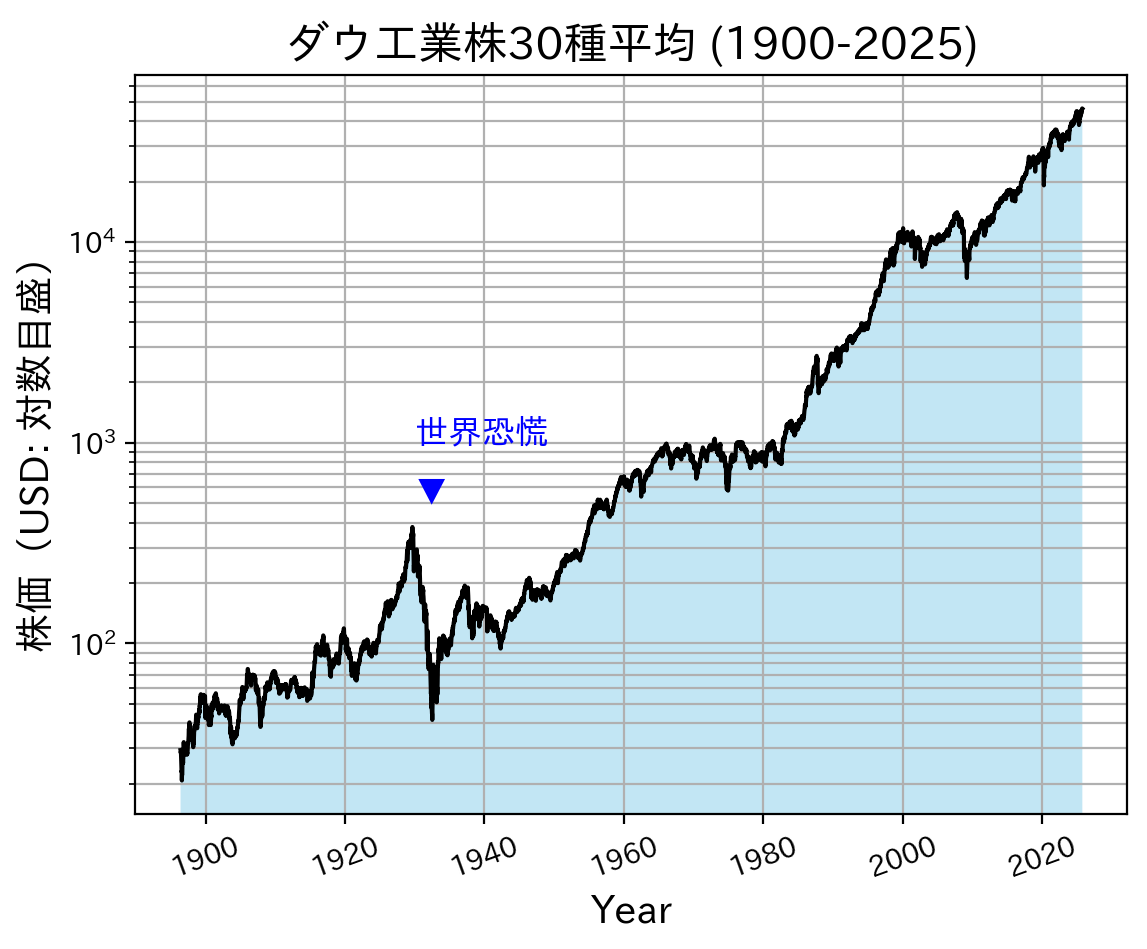

In [68]:
# グラフタイトル
plt.title('ダウ工業株30種平均 (1900-2025)', fontsize=16)

# グラフの軸名
plt.xlabel('Year', fontsize=14)
plt.ylabel('株価（USD: 対数目盛）', fontsize=14)
plt.grid(which='both', axis='both')

# グラフの塗りを指定
plt.yscale("log")
plt.plot(df_dji['Date'], df_dji['Close'], c="k", lw=1.5)
plt.fill_between(df_dji['Date'], df_dji['Close'], facecolor='skyblue', alpha=0.5, interpolate=True)

# 注釈の追加
plt.annotate("世界恐慌", xy = (datetime.datetime(1930,1,1),1000), size = 12, color = "blue")
plt.annotate("▼", xy = (datetime.datetime(1930,1,1),500), size = 12, color = "blue");

# 軸メモリの回転
plt.xticks(rotation=20);    # 回転角度指定

### 7. その他やや高度な可視化手法

#### ベクトル場の可視化
https://krajit.github.io/sympy/vectorFields/vectorFields.html

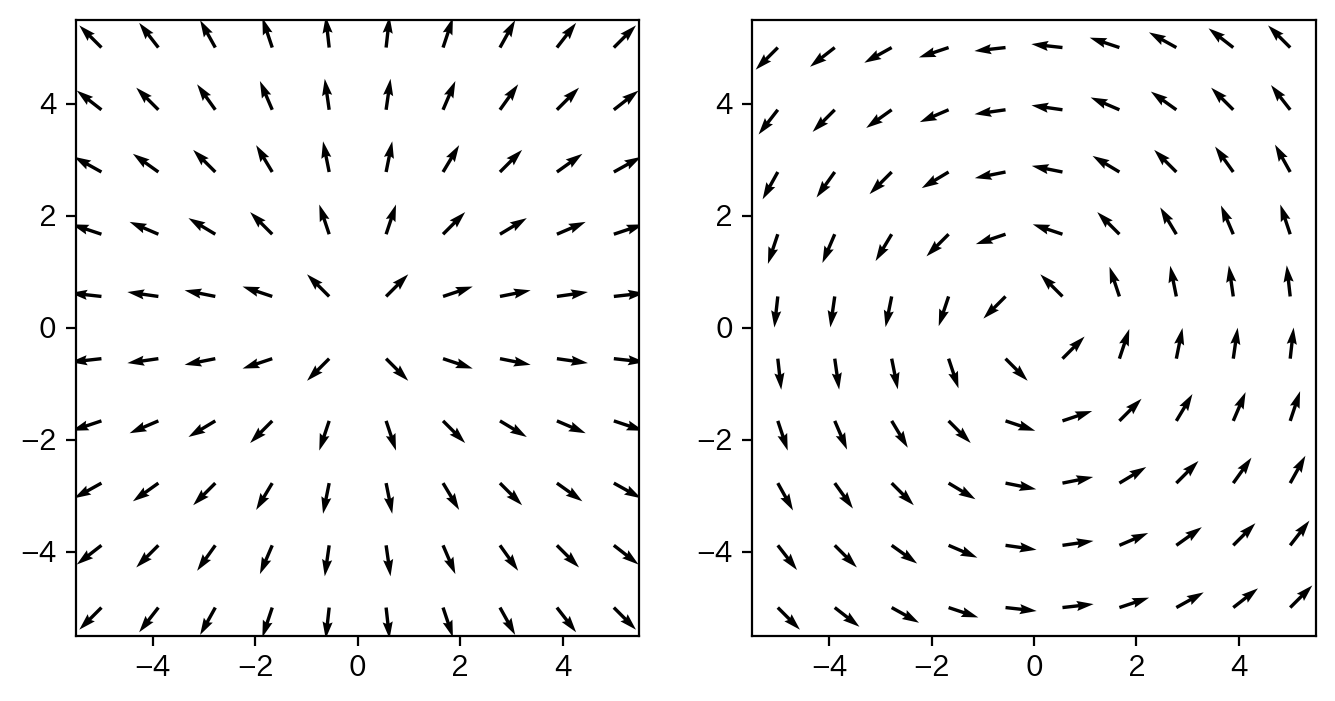

In [69]:
plt.figure(figsize=(8,4))

plt.subplot(1, 2, 1)
lattice = np.linspace(-5,5,10)
x, y = np.meshgrid(lattice, lattice)
u = x/np.sqrt(x**2 + y**2)
v = y/np.sqrt(x**2 + y**2)
plt.quiver(x,y,u,v);

plt.subplot(1, 2, 2)
u = -y/np.sqrt(x**2 + y**2)
v = x/np.sqrt(x**2 + y**2)
plt.quiver(x,y,u,v);

#### 等高線図の描画
https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contour.html  
https://matplotlib.org/stable/gallery/images_contours_and_fields/contour_demo.html

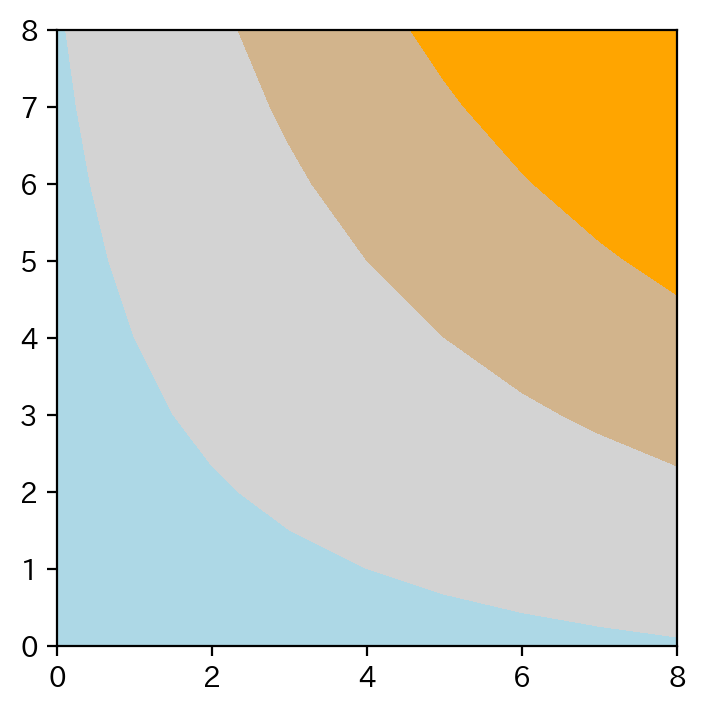

In [70]:
plt.figure(figsize=(4, 4))
x = np.arange(1, 10)
y = x.reshape(-1, 1)
h = x * y

# 等高線の設定
cs = plt.contourf(h, levels=[10, 30, 50], colors=['lightgray', 'tan', 'gray'], extend='both')
cs.cmap.set_over('orange')
cs.cmap.set_under('lightblue')

# 設定を適用
cs.changed()

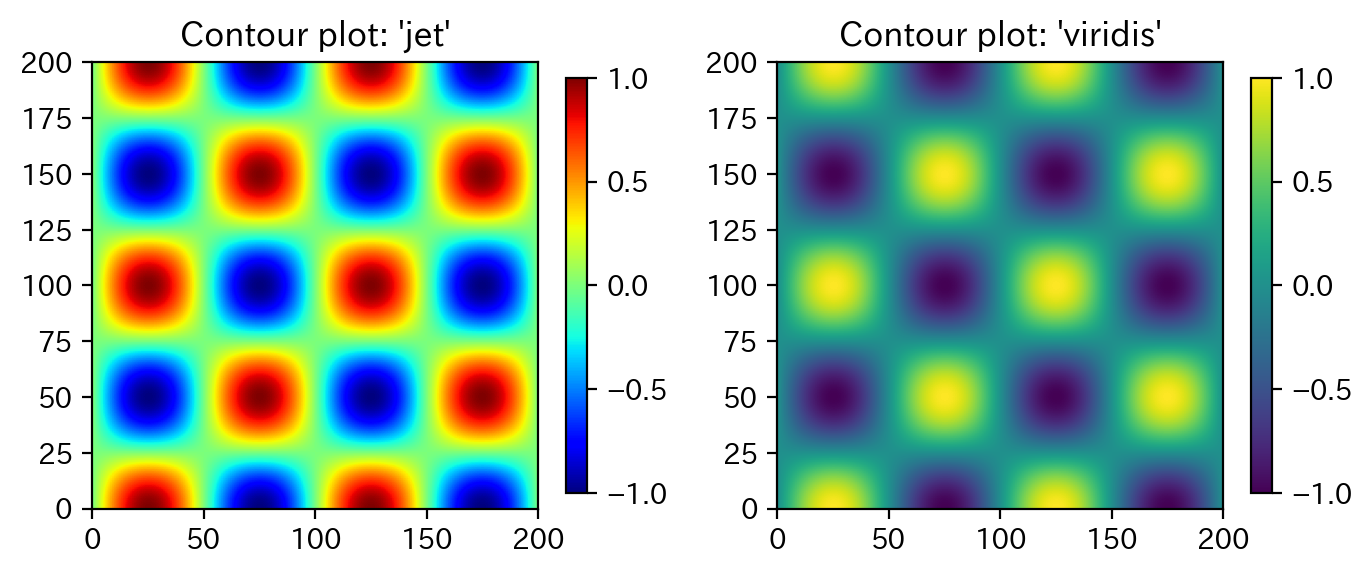

In [71]:
# ここ以降は、オブジェクト指向スタイルを用いています。

# データの作成（三角関数）
N = M = 201
x = np.linspace(0, 20, N)
y = np.linspace(0, 20, M)
X, Y = np.meshgrid(x,y)
data = np.sin(np.pi * X*2 / 10) * np.cos(np.pi * Y*2 / 10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3))
im = ax1.imshow(data, extent=[0, 200, 0, 200],cmap='jet')
ax1.set_title("Contour plot: 'jet'")
fig.colorbar(im, ax=ax1, shrink=0.8)

im2 = ax2.imshow(data, extent=[0, 200, 0, 200], cmap='viridis')
fig.colorbar(im2, ax=ax2, shrink=0.8)
ax2.set_title("Contour plot: 'viridis'")
fig.tight_layout()

#### 3Dグラフの描画

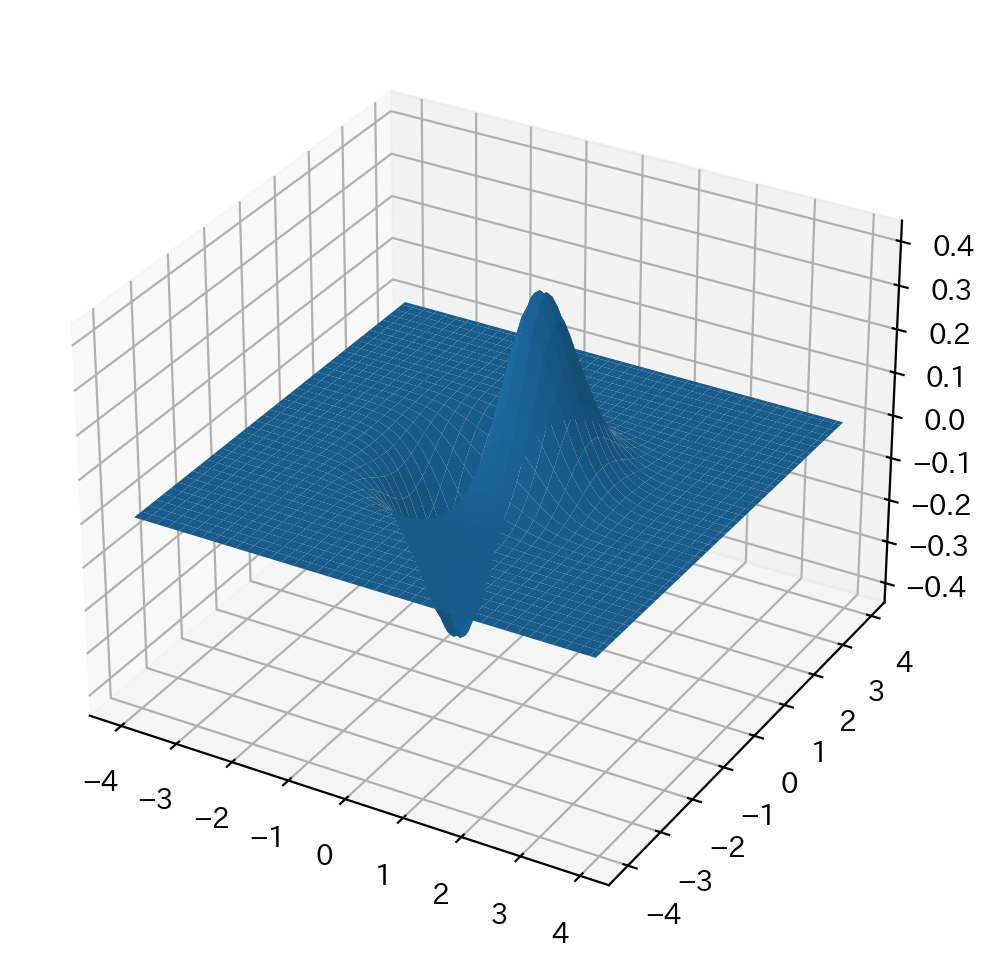

In [72]:
from mpl_toolkits.mplot3d import axes3d
x = np.arange(-4,4,0.1)
y = np.arange(-4,4,0.1)
X,Y = np.meshgrid(x,y)
Z = X*np.exp(-X**2 - Y**2)

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z);

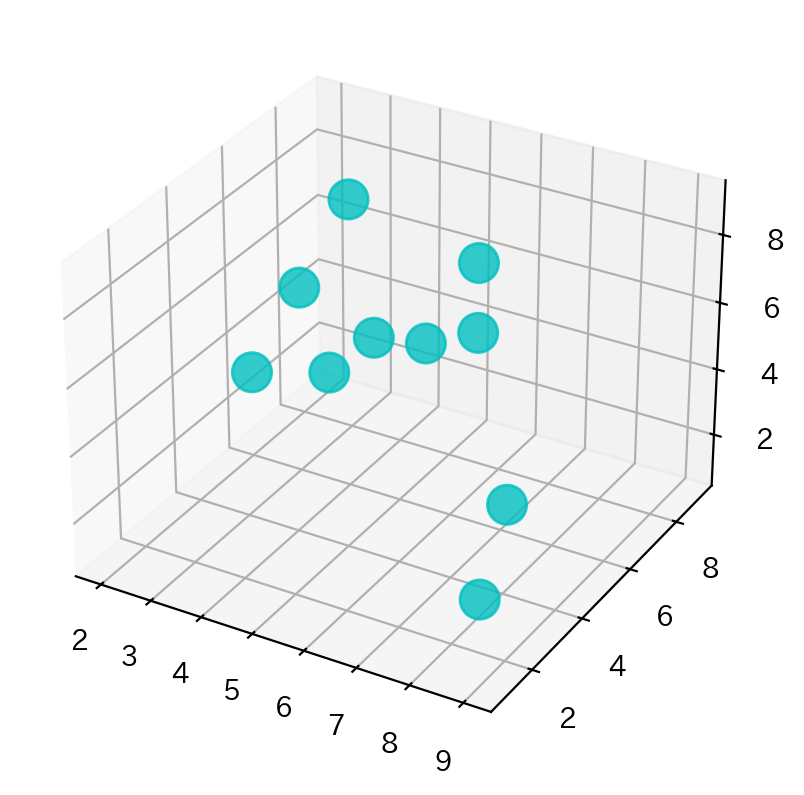

In [73]:
# 乱数で仮データ生成
data = np.random.randint(0, 10, size=(3,10))
x = data[0]; y = data[1]; z = data[2]

plt.subplot(projection='3d')
plt.gca().scatter(x, y, z, s=200, c="c", alpha=0.8);

### 8. 数学関数の可視化
Pythonの代数計算ライブラリ「SymPy」を利用  
https://gochikika.ntt.com/Features/SymPy.html


sin(x)

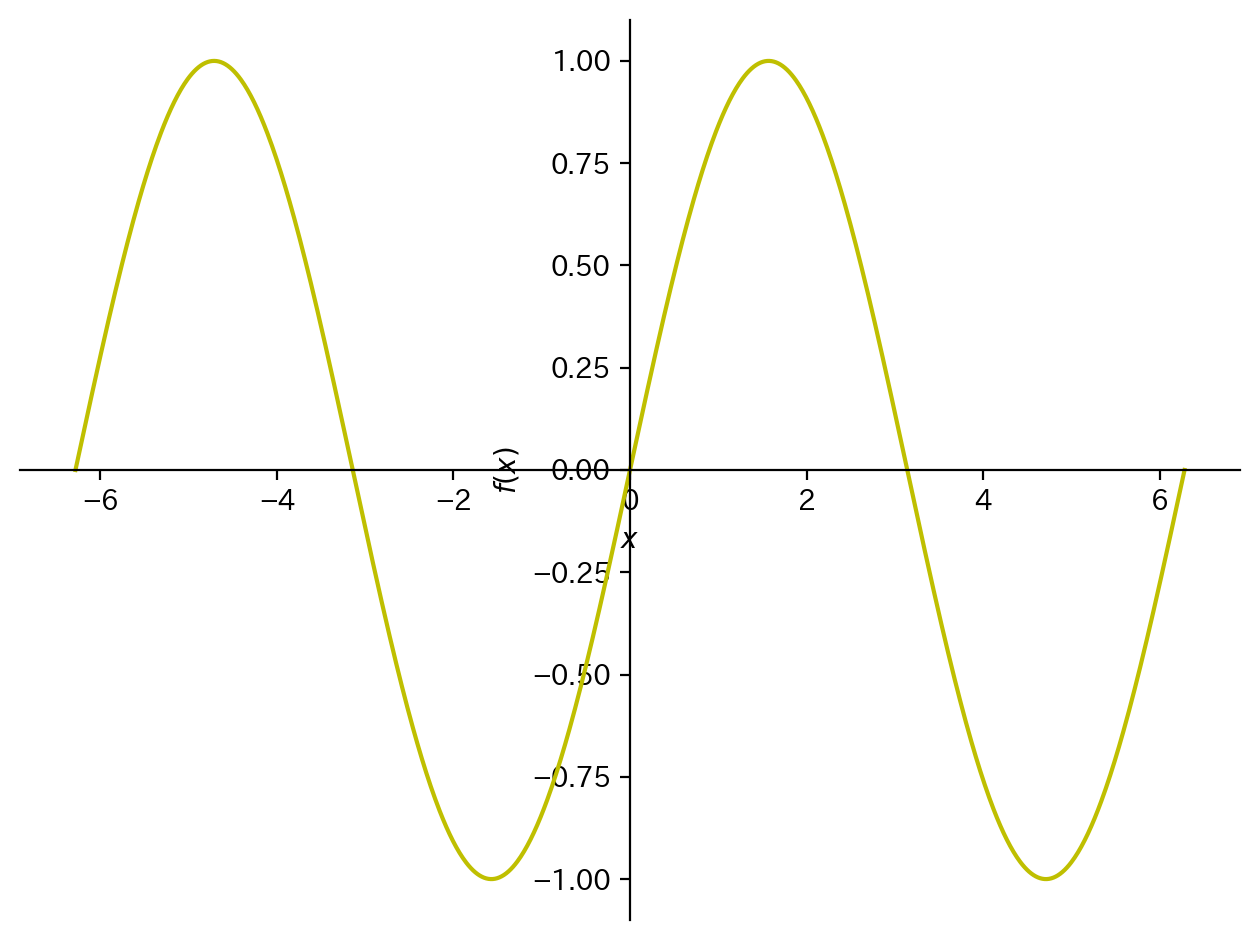

In [74]:
from sympy import plot, Symbol, sin, cos, exp, log, pi
x = Symbol('x')

# 関数定義
f = sin(x)
display(f)

# 関数の描画と範囲指定
plot(f, (x, -2*pi, 2*pi), line_color='y');

4*x/(x**2 + 1)

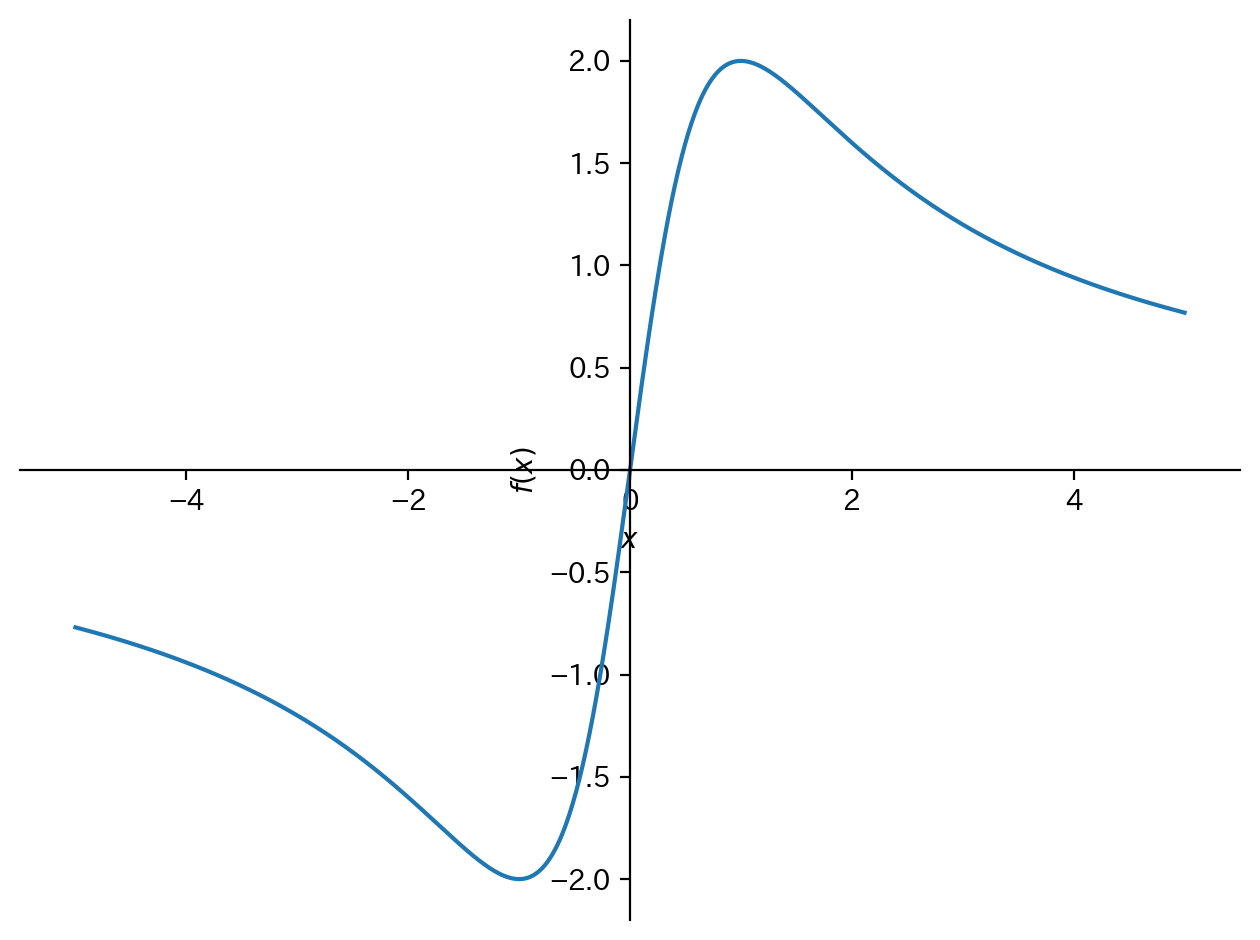

In [75]:
# 関数定義
f = 4 * x /(x**2 + 1)
display(f)

# 関数の描画と範囲指定
plot(f, (x, -5, 5));

sin(x)/x

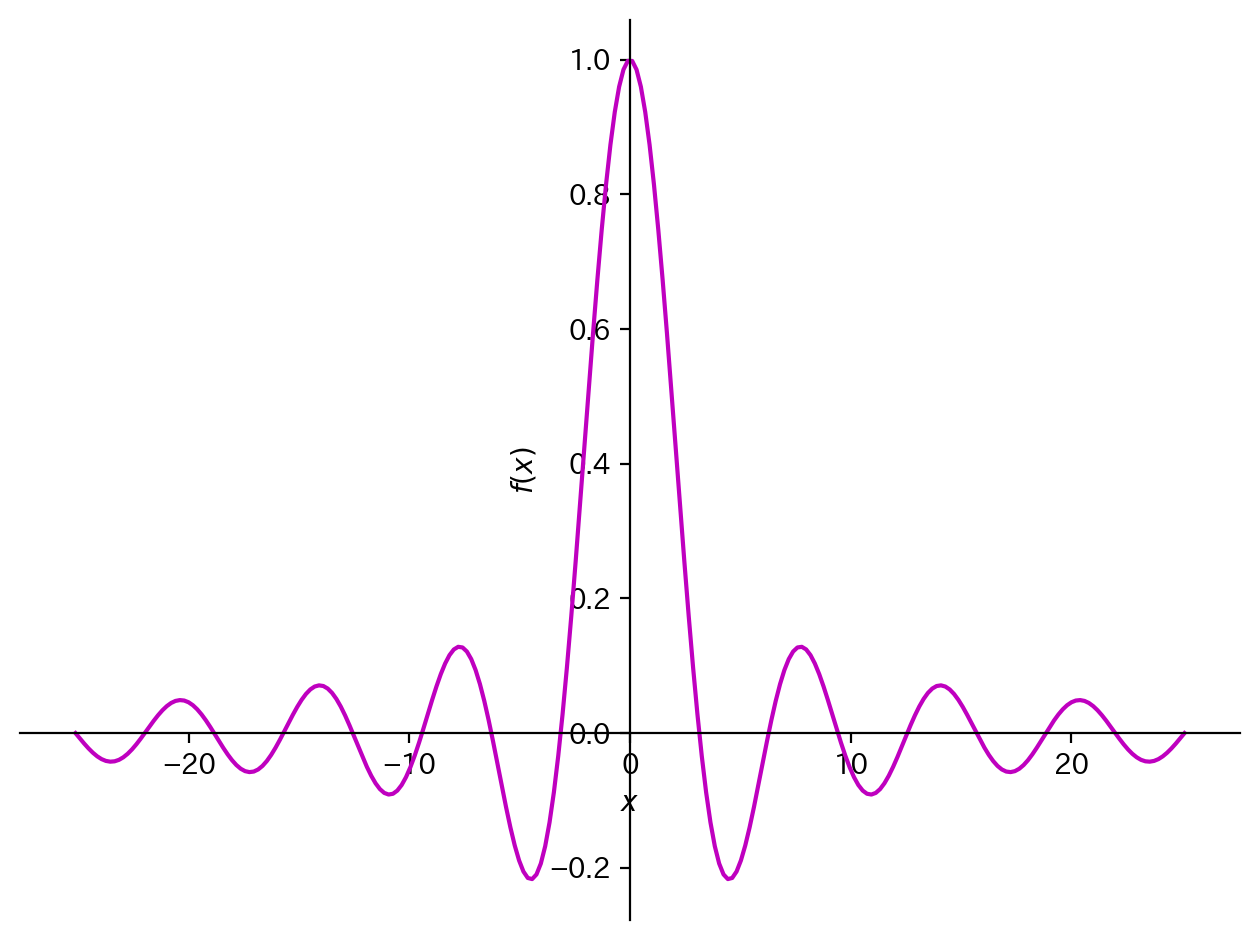

In [76]:
# 関数定義
f = sin(x) / x
display(f)

# 関数の描画と範囲指定
plot(f, (x, -8*pi, 8*pi), line_color='m', adaptive = False, nb_of_points = 2**8);

In [77]:
import matplotlib as mpl
mpl.get_cachedir()

'C:\\Users\\hkuma\\.matplotlib'

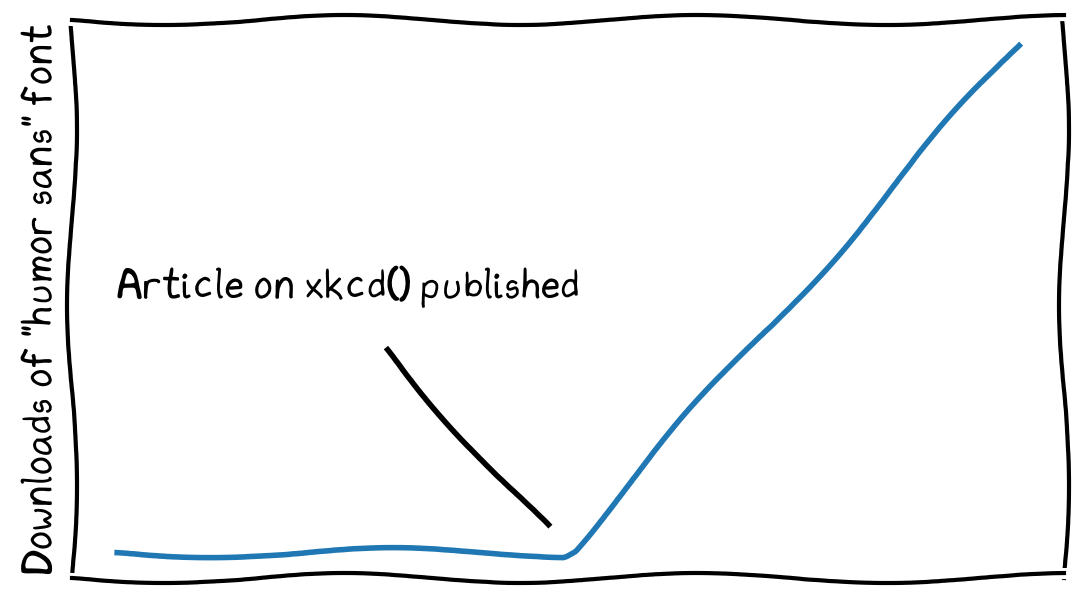

In [78]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 1, 100)
y = (x > 0.5) * (x - 0.5)

plt.xkcd(scale=5, length=400)
plt.xticks([])
plt.yticks([])
plt.ylabel('Downloads of "humor sans" font')
plt.text(0, 0.25, 'Article on xkcd() published')
plt.plot(x, y)
plt.plot([0.3, 0.475], [0.2, 0.025], 'black')
plt.gca().set_aspect(2*9/16)
plt.savefig('xkcd_plot.png', dpi=300)

In [79]:
plt.xkcd()